In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
import pandas as pd

df_full = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")  # Load full dataset first

# Filter out pre-diabetes (Diabetes_012 == 1) to create the binary dataset
df = df_full[df_full['Diabetes_012'] != 1].copy() # Ensure 'df' now refers to the binary dataset
df['target'] = (df['Diabetes_012'] == 2).astype(int) # Create the binary target column

diabetic = df[df['target'] == 1]
non_diabetic = df[df['target'] == 0]

income_map = {
    1: "<$10,000", 2: "$10,000–$14,999", 3: "$15,000–$19,999",
    4: "$20,000–$24,999", 5: "$25,000–$34,999", 6: "$35,000–$49,999",
    7: "$50,000–$74,999", 8: "$75,000+"
}

for label, grp in [("Diabetic", diabetic), ("Non-diabetic", non_diabetic)]:
    # Using 'Income' column from the filtered DataFrame
    counts = grp['Income'].value_counts(normalize=True).sort_index() * 100
    counts.index = counts.index.map(income_map)
    print(f"\n{label} income distribution:\n{counts.round(1)}")


Diabetic income distribution:
Income
<$10,000            6.7
$10,000–$14,999     8.7
$15,000–$19,999    10.1
$20,000–$24,999    11.5
$25,000–$34,999    12.7
$35,000–$49,999    15.0
$50,000–$74,999    14.9
$75,000+           20.4
Name: proportion, dtype: float64

Non-diabetic income distribution:
Income
<$10,000            3.3
$10,000–$14,999     3.9
$15,000–$19,999     5.6
$20,000–$24,999     7.3
$25,000–$34,999     9.7
$35,000–$49,999    14.2
$50,000–$74,999    17.4
$75,000+           38.5
Name: proportion, dtype: float64


In [ ]:
import pandas as pd

# Re-load from source if 'df' is not already the filtered binary version
# (This ensures robustness if cells are run out of order)
if 'df' not in globals() or 'target' not in df.columns:
    df_full_temp = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df = df_full_temp[df_full_temp['Diabetes_012'] != 1].copy()
    df['target'] = (df['Diabetes_012'] == 2).astype(int)

print(f"Shape (binary diabetes): {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nDiabetes cases (target=1): {df['target'].sum()}")
print(f"No diabetes cases (target=0): {len(df) - df['target'].sum()}")
print("\nFirst 5 rows (showing 'target' column):")
print(df.head())

Shape (binary diabetes): (249049, 23)
Columns: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'target']

Diabetes cases (target=1): 35346
No diabetes cases (target=0): 213703

First 5 rows (showing 'target' column):
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  NoDocbcCost  GenHlth  \
0                   0.0           0.0     0.0  ...       

In [ ]:
# SD of income level (1–8) by diabetes status
# Ensure 'df' is the binary version with 'target' column
if 'target' not in df.columns:
    # This block should ideally not be hit if previous cells are run correctly
    df_full_temp = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df = df_full_temp[df_full_temp['Diabetes_012'] != 1].copy()
    df['target'] = (df['Diabetes_012'] == 2).astype(int)

df.groupby("target")["Income"].agg(["mean", "std", "count"])

,mean,std,count
target,,,
0,6.208663,2.005203,213703
1,5.210094,2.217319,35346


In [ ]:
import pandas as pd

# Ensure 'df' is the binary version with 'target' column
if 'target' not in df.columns:
    # This block should ideally not be hit if previous cells are run correctly
    df_full_temp = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df = df_full_temp[df_full_temp['Diabetes_012'] != 1].copy()
    df['target'] = (df['Diabetes_012'] == 2).astype(int)

# ==== EDIT THESE TWO LINES if your column names differ ==== #
# Use the new 'target' column for diabetes status
income_col = "Income"          # income bracket (1–8 scale)
diabetes_col = "target"   # 0 = non-diabetic, 1 = diabetic

# Optional: map numeric income codes to labels
income_labels = {
    1: "Less than $10,000",
    2: "$10,000–$14,999",
    3: "$15,000–$19,999",
    4: "$20,000–$24,999",
    5: "$25,000–$34,999",
    6: "$35,000–$49,999",
    7: "$50,000–$74,999",
    8: "$75,000 or more",
}

# Clean and keep only income categories 1–8
df_clean = df[df[income_col].between(1, 8)].copy()

# Compute n and prevalence by bracket
summary = (
    df_clean
    .groupby(income_col)
    .agg(
        n=(diabetes_col, "size"),
        diabetic=(diabetes_col, lambda x: (x == 1).sum()) # Use target == 1 for diabetic count
    )
    .reset_index()
)

summary["prevalence"] = (summary["diabetic"] / summary["n"]) * 100
summary["label"] = summary[income_col].map(income_labels)

# Format for Table 3
summary["Table3_entry"] = summary.apply(
    lambda r: f"{r['prevalence']:.1f}% (n = {int(r['n']):,})", axis=1
)

summary = summary[["label", "Table3_entry", "prevalence", "n", "diabetic"]]

summary

,label,Table3_entry,prevalence,n,diabetic
0,"Less than $10,000","25.1% (n = 9,497)",25.092134,9497,2383
1,"$10,000–$14,999","27.0% (n = 11,427)",27.006213,11427,3086
2,"$15,000–$19,999","22.9% (n = 15,573)",22.911449,15573,3568
3,"$20,000–$24,999","20.6% (n = 19,676)",20.603781,19676,4054
4,"$25,000–$34,999","17.8% (n = 25,296)",17.805187,25296,4504
5,"$35,000–$49,999","14.8% (n = 35,722)",14.811601,35722,5291
6,"$50,000–$74,999","12.4% (n = 42,484)",12.392901,42484,5265
7,"$75,000 or more","8.1% (n = 89,374)",8.050440,89374,7195


In [ ]:
# Ensure 'df' is the binary version with 'target' column
if 'target' not in df.columns:
    # This block should ideally not be hit if previous cells are run correctly
    df_full_temp = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df = df_full_temp[df_full_temp['Diabetes_012'] != 1].copy()
    df['target'] = (df['Diabetes_012'] == 2).astype(int)

print("=== DATASET OVERVIEW (Binary Diabetes) ===")
print(f"Total participants: {len(df):,}")
print(f"Features: {df.shape[1] - 1}") # Exclude the 'target' column itself
print(f"\nDiabetes breakdown:")
print(f"  No diabetes (target=0): {len(df[df['target']==0]):,}")
# Pre-diabetes (1) is explicitly excluded from 'df' at this point
print(f"  Diabetes (target=1): {len(df[df['target']==1]):,}")

print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nBasic stats:")
print(df[['BMI', 'Age', 'PhysHlth', 'MentHlth']].describe())

=== DATASET OVERVIEW (Binary Diabetes) ===
Total participants: 249,049
Features: 22

Diabetes breakdown:
  No diabetes (target=0): 213,703
  Diabetes (target=1): 35,346

Missing values: 0

Basic stats:
                 BMI            Age       PhysHlth      MentHlth
count  249049.000000  249049.000000  249049.000000  249049.00000
mean       28.338813       8.012572       4.202916       3.15976
std         6.594030       3.058090       8.681035       7.38012
min        12.000000       1.000000       0.000000       0.00000
25%        24.000000       6.000000       0.000000       0.00000
50%        27.000000       8.000000       0.000000       0.00000
75%        31.000000      10.000000       3.000000       2.00000
max        98.000000      13.000000      30.000000      30.00000


In [ ]:
import pandas as pd

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)

income_labels = {
    1: "Less than $10,000", 2: "$10,000–$14,999", 3: "$15,000–$19,999",
    4: "$20,000–$24,999", 5: "$25,000–$34,999", 6: "$35,000–$49,999",
    7: "$50,000–$74,999", 8: "$75,000 or more"
}

table3 = (
    df[df['Income'].between(1, 8)]
    .groupby('Income')
    .agg(total=('target', 'count'), cases=('target', 'sum'))
    .assign(
        prevalence=lambda x: (x.cases / x.total * 100).round(1),
        label=lambda x: x.index.map(income_labels),
        table_entry=lambda x: x.apply(
            lambda r: f"{r.prevalence:.1f}% ({int(r.cases):,} / {int(r.total):,})", axis=1
        )
    )
)

print("=== TABLE 3: DIABETES PREVALENCE BY INCOME BRACKET ===")
print(table3[['label', 'cases', 'total', 'prevalence', 'table_entry']].to_string())
print(f"\nLowest 5 brackets (<$35k): {table3.loc[1:5,'cases'].sum():,} of {table3['cases'].sum():,} cases ({table3.loc[1:5,'cases'].sum()/table3['cases'].sum()*100:.1f}%)")

=== TABLE 3: DIABETES PREVALENCE BY INCOME BRACKET ===
                    label  cases  total  prevalence             table_entry
Income                                                                     
1.0     Less than $10,000   2383   9497        25.1   25.1% (2,383 / 9,497)
2.0       $10,000–$14,999   3086  11427        27.0  27.0% (3,086 / 11,427)
3.0       $15,000–$19,999   3568  15573        22.9  22.9% (3,568 / 15,573)
4.0       $20,000–$24,999   4054  19676        20.6  20.6% (4,054 / 19,676)
5.0       $25,000–$34,999   4504  25296        17.8  17.8% (4,504 / 25,296)
6.0       $35,000–$49,999   5291  35722        14.8  14.8% (5,291 / 35,722)
7.0       $50,000–$74,999   5265  42484        12.4  12.4% (5,265 / 42,484)
8.0       $75,000 or more   7195  89374         8.1   8.1% (7,195 / 89,374)

Lowest 5 brackets (<$35k): 17,595 of 35,346 cases (49.8%)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)
X = df.drop(['Diabetes_012', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

no_doctor_needed = ['BMI', 'Age', 'Sex', 'Income', 'Education',
                    'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'Smoker',
                    'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']

X_train_nodoc = X_train[no_doctor_needed]

pipeline_nodoc = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1))
])

cv_scores = cross_val_score(pipeline_nodoc, X_train_nodoc, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
n = len(cv_scores)

print("=== CROSS-VALIDATION: No-Clinical-Test Model ===")
print(f"CV Scores: {[f'{s:.3f}' for s in cv_scores]}")
print(f"Mean AUC:  {cv_scores.mean():.3f} (SD = {cv_scores.std():.3f})")
print(f"95% CI:    [{cv_scores.mean() - 1.96*(cv_scores.std()/np.sqrt(n)):.3f}, "
      f"{cv_scores.mean() + 1.96*(cv_scores.std()/np.sqrt(n)):.3f}]")

=== CROSS-VALIDATION: No-Clinical-Test Model ===
CV Scores: ['0.810', '0.804', '0.804', '0.807', '0.810']
Mean AUC:  0.807 (SD = 0.003)
95% CI:    [0.804, 0.809]


Brier Score (No-Clinical-Test Model): 0.1831
(Lower = better calibration; perfect = 0.0, random = ~0.125)

Calibration bins (mean predicted prob → fraction of positives):
  MPP 0.064  →  FOP 0.006  (gap: -0.058)
  MPP 0.149  →  FOP 0.018  (gap: -0.130)
  MPP 0.249  →  FOP 0.047  (gap: -0.201)
  MPP 0.349  →  FOP 0.082  (gap: -0.267)
  MPP 0.448  →  FOP 0.136  (gap: -0.313)
  MPP 0.549  →  FOP 0.202  (gap: -0.348)
  MPP 0.650  →  FOP 0.264  (gap: -0.385)
  MPP 0.748  →  FOP 0.337  (gap: -0.412)
  MPP 0.847  →  FOP 0.426  (gap: -0.421)
  MPP 0.935  →  FOP 0.519  (gap: -0.416)


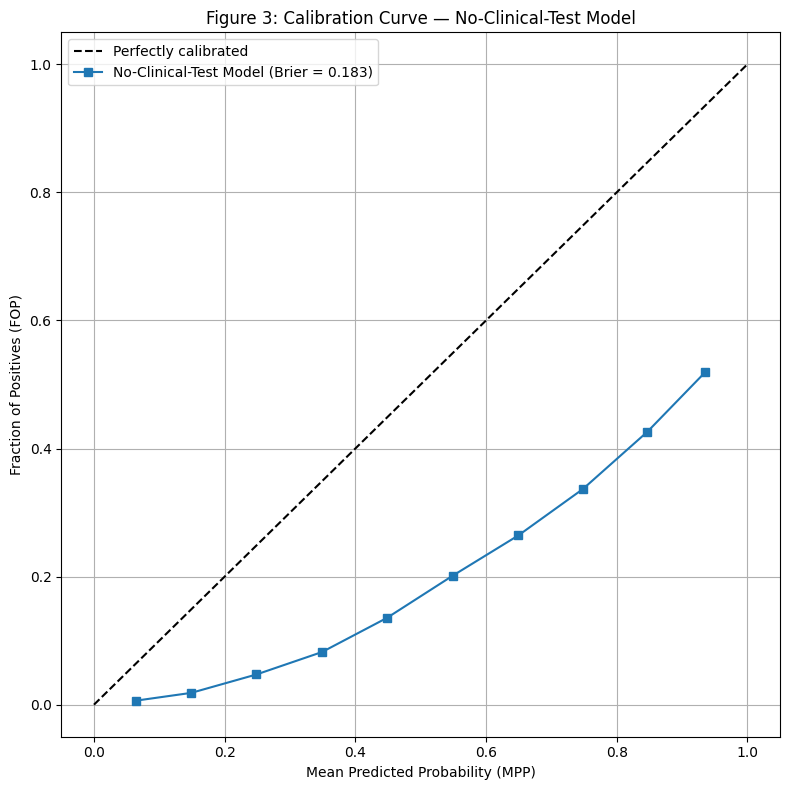

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)
X = df.drop(['Diabetes_012', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

no_doctor_needed = ['BMI', 'Age', 'Sex', 'Income', 'Education',
                    'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'Smoker',
                    'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']

model_nodoc = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
model_nodoc.fit(X_train[no_doctor_needed], y_train)
y_prob = model_nodoc.predict_proba(X_test[no_doctor_needed])[:, 1]

brier = brier_score_loss(y_test, y_prob)
fop, mpv = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')

print(f"Brier Score (No-Clinical-Test Model): {brier:.4f}")
print("(Lower = better calibration; perfect = 0.0, random = ~0.125)")
print(f"\nCalibration bins (mean predicted prob → fraction of positives):")
for m, f in zip(mpv, fop):
    print(f"  MPP {m:.3f}  →  FOP {f:.3f}  (gap: {f-m:+.3f})")

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(mpv, fop, 's-', label=f'No-Clinical-Test Model (Brier = {brier:.3f})')
plt.xlabel('Mean Predicted Probability (MPP)')
plt.ylabel('Fraction of Positives (FOP)')
plt.title('Figure 3: Calibration Curve — No-Clinical-Test Model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('calibration_curve_corrected.png', dpi=150)
plt.show()

Brier Score (calibrated): 0.1022
Brier Score (uncalibrated was 0.1831 — should be lower now)


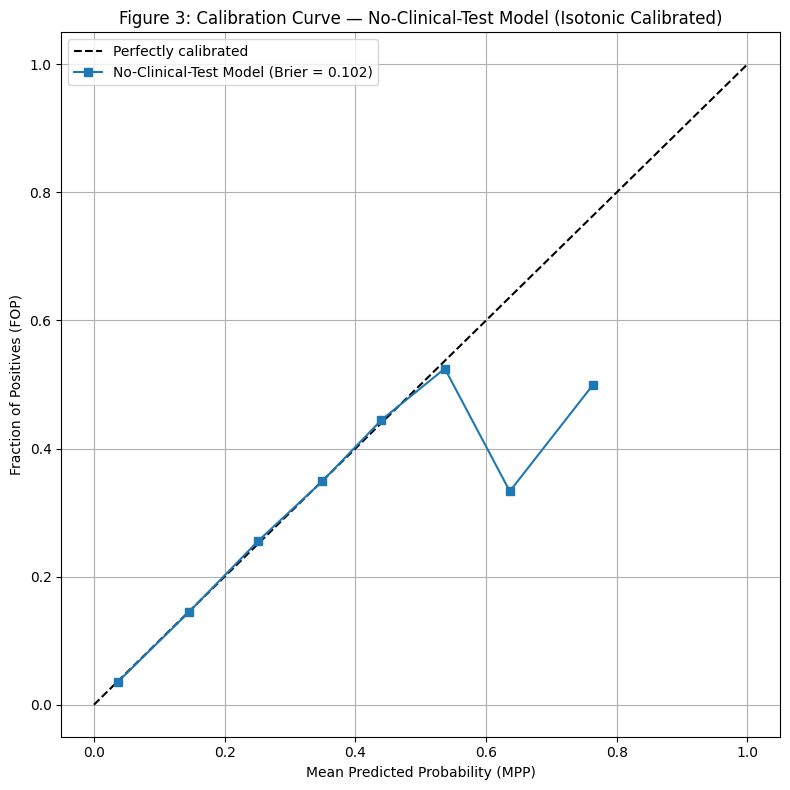

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd, numpy as np, matplotlib.pyplot as plt

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)
X = df.drop(['Diabetes_012', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

no_doctor_needed = ['BMI', 'Age', 'Sex', 'Income', 'Education',
                    'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'Smoker',
                    'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']

base_nodoc = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1
)

# Isotonic calibration on training data only (cv=5 internal)
cal_nodoc = CalibratedClassifierCV(estimator=base_nodoc, method='isotonic', cv=5)
cal_nodoc.fit(X_train[no_doctor_needed], y_train)
y_prob_cal = cal_nodoc.predict_proba(X_test[no_doctor_needed])[:, 1]

brier_cal = brier_score_loss(y_test, y_prob_cal)
fop, mpv = calibration_curve(y_test, y_prob_cal, n_bins=10, strategy='uniform')

print(f"Brier Score (calibrated): {brier_cal:.4f}")
print(f"Brier Score (uncalibrated was 0.1831 — should be lower now)")

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(mpv, fop, 's-', label=f'No-Clinical-Test Model (Brier = {brier_cal:.3f})')
plt.xlabel('Mean Predicted Probability (MPP)')
plt.ylabel('Fraction of Positives (FOP)')
plt.title('Figure 3: Calibration Curve — No-Clinical-Test Model (Isotonic Calibrated)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('calibration_curve_isotonic.png', dpi=150)
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)

total_cases = df['target'].sum()
total_n = len(df)

# Five lowest brackets = Income 1–5 (< $35,000)
low_income = df[df['Income'] <= 5]
low_cases = low_income['target'].sum()
low_n = len(low_income)

print(f"Total sample N:         {total_n:,}")
print(f"Total diabetes cases:   {total_cases:,}")
print()
print(f"Income <$35k (brackets 1–5):")
print(f"  N:            {low_n:,}  ({low_n/total_n*100:.1f}% of sample)")
print(f"  Diabetes cases: {low_cases:,}  ({low_cases/total_cases*100:.1f}% of all cases)")
print()
print(f"Manuscript claimed: 43% of sample, 58% of cases")
print(f"Actual:             {low_n/total_n*100:.1f}% of sample, {low_cases/total_cases*100:.1f}% of cases")

Total sample N:         249,049
Total diabetes cases:   35,346

Income <$35k (brackets 1–5):
  N:            81,469  (32.7% of sample)
  Diabetes cases: 17,595  (49.8% of all cases)

Manuscript claimed: 43% of sample, 58% of cases
Actual:             32.7% of sample, 49.8% of cases


In [ ]:
import pandas as pd
import numpy as np

# ── Load raw BRFSS 2015 XPT ──────────────────────────────────────
print("Loading raw BRFSS 2015 XPT file...")
raw = pd.read_sas('LLCP2015.XPT ', format='xport', encoding='latin1')
print(f"Raw BRFSS 2015 total rows: {len(raw):,}")
print(f"Raw BRFSS 2015 total columns: {raw.shape[1]}")

# ── Map the 21 Kaggle variables from raw BRFSS columns ───────────
# Based on Teboul (2021) curation documentation
col_map = {
    'DIABETE3':  'Diabetes_012',
    '_RFHYPE5':  'HighBP',
    '_RFCHOL':   'HighChol',
    'CHOLCHK':   'CholCheck',
    '_BMI5':     'BMI',
    'SMOKE100':  'Smoker',
    'CVDSTRK3':  'Stroke',
    '_MICHD':    'HeartDiseaseorAttack',
    '_TOTINDA':  'PhysActivity',
    '_FRTLT1':   'Fruits',
    '_VEGLT1':   'Veggies',
    '_RFDRHV5':  'HvyAlcoholConsump',
    'HLTHPLN1':  'AnyHealthcare',
    'MEDCOST':   'NoDocbcCost',
    'GENHLTH':   'GenHlth',
    'MENTHLTH':  'MentHlth',
    'PHYSHLTH':  'PhysHlth',
    'DIFFWALK':  'DiffWalk',
    'SEX':       'Sex',
    '_AGEG5YR':  'Age',
    'EDUCA':     'Education',
    'INCOME2':   'Income',
}

# Check which raw columns are present
print("\n--- Column availability in raw XPT ---")
missing_raw = [k for k in col_map if k not in raw.columns]
present_raw = [k for k in col_map if k in raw.columns]
print(f"Found: {len(present_raw)}/22 mapped columns")
if missing_raw:
    print(f"MISSING from XPT: {missing_raw}")

# ── Apply value recoding to match Kaggle binary format ───────────
df_raw = raw[present_raw].copy()
df_raw = df_raw.rename(columns={k: col_map[k] for k in present_raw})

# Recode following Teboul documentation
recode = {
    'Diabetes_012':        {1.0: 2.0, 3.0: 0.0, 4.0: 1.0},   # 1=yes→2, 3=no→0, 4=pre→1
    'HighBP':              {1.0: 0.0, 2.0: 1.0},               # _RFHYPE5: 1=no, 2=yes
    'HighChol':            {1.0: 0.0, 2.0: 1.0},               # _RFCHOL:  1=no, 2=yes
    'CholCheck':           {1.0: 1.0, 2.0: 0.0},
    'Smoker':              {1.0: 1.0, 2.0: 0.0},
    'Stroke':              {1.0: 1.0, 2.0: 0.0},
    'HeartDiseaseorAttack':{1.0: 1.0, 2.0: 0.0},
    'PhysActivity':        {1.0: 1.0, 2.0: 0.0},
    'Fruits':              {1.0: 1.0, 2.0: 0.0},               # _FRTLT1: 1=<1/day→0... check
    'Veggies':             {1.0: 1.0, 2.0: 0.0},
    'HvyAlcoholConsump':   {1.0: 0.0, 2.0: 1.0},               # _RFDRHV5: 1=no, 2=yes
    'AnyHealthcare':       {1.0: 1.0, 2.0: 0.0},
    'NoDocbcCost':         {1.0: 1.0, 2.0: 0.0},
    'DiffWalk':            {1.0: 1.0, 2.0: 0.0},
    'Sex':                 {1.0: 1.0, 2.0: 0.0},               # 1=male→1, 2=female→0
}

for col, mapping in recode.items():
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].map(mapping)

# BMI: divide by 100, set sentinel values to NaN
if 'BMI' in df_raw.columns:
    df_raw['BMI'] = df_raw['BMI'].replace({7777.0: np.nan, 9999.0: np.nan}) / 100.0

# MentHlth/PhysHlth: 88=none→0, 77/99→NaN
for col in ['MentHlth', 'PhysHlth']:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].replace({88.0: 0.0, 77.0: np.nan, 99.0: np.nan})

# GenHlth, Age, Education, Income: set refusal/unknown to NaN
for col in ['GenHlth', 'Age', 'Education', 'Income', 'Diabetes_012']:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].replace({7.0: np.nan, 9.0: np.nan, 77.0: np.nan, 99.0: np.nan})

# ── Keep complete cases on all 21 variables ───────────────────────
kaggle_cols = list(col_map.values())
available_cols = [c for c in kaggle_cols if c in df_raw.columns]
df_complete = df_raw[available_cols].dropna()

print(f"\n--- Provenance Comparison ---")
print(f"Raw XPT rows:                    {len(raw):,}")
print(f"After recoding + complete cases: {len(df_complete):,}")

# Load Kaggle file for comparison
kaggle = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
print(f"Kaggle CSV total rows:           {len(kaggle):,}")
print(f"  of which Diabetes_012==0:      {(kaggle['Diabetes_012']==0).sum():,}")
print(f"  of which Diabetes_012==1:      {(kaggle['Diabetes_012']==1).sum():,}")
print(f"  of which Diabetes_012==2:      {(kaggle['Diabetes_012']==2).sum():,}")

diff = len(df_complete) - len(kaggle)
pct_diff = abs(diff) / len(kaggle) * 100
print(f"\nDifference: {diff:+,} rows ({pct_diff:.2f}%)")

if pct_diff < 1.0:
    print("RESULT: N matches within 1% — Kaggle curation is verifiably consistent with raw CDC microdata.")
elif pct_diff < 5.0:
    print("RESULT: Minor discrepancy (<5%) — likely due to column-mapping differences. Investigate missing columns above.")
else:
    print("RESULT: Substantial discrepancy — investigate column mappings before reporting.")

# ── Class distribution comparison ────────────────────────────────
print("\n--- Class distribution comparison ---")
print(f"{'Class':<15} {'Raw (recoded)':<20} {'Kaggle CSV':<20}")
for val, label in [(0.0, 'No diabetes'), (1.0, 'Pre-diabetes'), (2.0, 'Diabetes')]:
    raw_n = (df_complete['Diabetes_012'] == val).sum()
    kag_n = (kaggle['Diabetes_012'] == val).sum()
    print(f"{label:<15} {raw_n:<20,} {kag_n:<20,}")

Loading raw BRFSS 2015 XPT file...
Raw BRFSS 2015 total rows: 441,456
Raw BRFSS 2015 total columns: 330

--- Column availability in raw XPT ---
Found: 22/22 mapped columns

--- Provenance Comparison ---
Raw XPT rows:                    441,456
After recoding + complete cases: 142,984
Kaggle CSV total rows:           249,049
  of which Diabetes_012==0:      213,703
  of which Diabetes_012==1:      0
  of which Diabetes_012==2:      35,346

Difference: -106,065 rows (42.59%)
RESULT: Substantial discrepancy — investigate column mappings before reporting.

--- Class distribution comparison ---
Class           Raw (recoded)        Kaggle CSV          
No diabetes     117,843              213,703             
Pre-diabetes    2,838                0                   
Diabetes        22,303               35,346              


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
from statsmodels.stats.proportion import proportion_confint

# ── Load and de-duplicate ─────────────────────────────────────────
df_full = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df_deduped = df_full.drop_duplicates().copy()

print("=== DE-DUPLICATION SUMMARY ===")
print(f"Original rows:      {len(df_full):,}")
print(f"Duplicate rows:     {df_full.duplicated().sum():,} ({df_full.duplicated().sum()/len(df_full)*100:.1f}%)")
print(f"After dedup:        {len(df_deduped):,}")

# Filter pre-diabetics (already excluded in binary file, but confirm)
df_deduped = df_deduped[df_deduped['Diabetes_012'] != 1].copy()
df_deduped['target'] = (df_deduped['Diabetes_012'] == 2).astype(int)

print(f"After dedup + pre-diabetic filter: {len(df_deduped):,}")
print(f"  Diabetic:     {df_deduped['target'].sum():,} ({df_deduped['target'].mean()*100:.1f}%)")
print(f"  Non-diabetic: {(1-df_deduped['target']).sum():,} ({(1-df_deduped['target']).mean()*100:.1f}%)")

X_dd = df_deduped.drop(['Diabetes_012', 'target'], axis=1)
y_dd = df_deduped['target']

X_train_dd, X_test_dd, y_train_dd, y_test_dd = train_test_split(
    X_dd, y_dd, test_size=0.2, random_state=42, stratify=y_dd
)

no_doctor_needed = ['BMI', 'Age', 'Sex', 'Income', 'Education',
                    'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'Smoker',
                    'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']

# ── Full model ────────────────────────────────────────────────────
full_lr = LogisticRegression(class_weight='balanced', max_iter=1000,
                             random_state=42, n_jobs=-1)
full_lr.fit(X_train_dd, y_train_dd)
y_prob_full_dd = full_lr.predict_proba(X_test_dd)[:, 1]
auc_full_dd = roc_auc_score(y_test_dd, y_prob_full_dd)

cv_full_dd = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_train_dd, y_train_dd, cv=5, scoring='roc_auc', n_jobs=-1
)

# ── No-clinical-test model ────────────────────────────────────────
nodoc_lr = LogisticRegression(class_weight='balanced', max_iter=1000,
                              random_state=42, n_jobs=-1)
nodoc_lr.fit(X_train_dd[no_doctor_needed], y_train_dd)
y_prob_nodoc_dd = nodoc_lr.predict_proba(X_test_dd[no_doctor_needed])[:, 1]
auc_nodoc_dd = roc_auc_score(y_test_dd, y_prob_nodoc_dd)

cv_nodoc_dd = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_train_dd[no_doctor_needed], y_train_dd, cv=5, scoring='roc_auc', n_jobs=-1
)

# ── Threshold-optimized metrics ───────────────────────────────────
from sklearn.metrics import roc_curve

def metrics_at_75(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    idx = np.argmin(np.abs(tpr - 0.75))
    thresh = thresholds[idx]
    y_pred = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv  = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    return thresh, sens, spec, ppv, npv

thresh_full_dd, sens_full_dd, spec_full_dd, ppv_full_dd, npv_full_dd = \
    metrics_at_75(y_test_dd.values, y_prob_full_dd)
thresh_nodoc_dd, sens_nodoc_dd, spec_nodoc_dd, ppv_nodoc_dd, npv_nodoc_dd = \
    metrics_at_75(y_test_dd.values, y_prob_nodoc_dd)

# ── Print comparison ──────────────────────────────────────────────
print("\n=== COMPARISON: ORIGINAL vs DE-DUPLICATED ===")
print(f"\n{'Metric':<30} {'Original':>12} {'De-duplicated':>15} {'Delta':>10}")
print("-" * 70)

original = {
    'Full model AUC':      0.829,
    'Full model CV AUC':   0.827,
    'Full model CV SD':    0.003,
    'No-clin AUC':         0.809,
    'No-clin CV AUC':      0.807,
    'No-clin CV SD':       0.003,
    'Full sensitivity':    0.750,
    'Full specificity':    0.749,
    'No-clin sensitivity': 0.750,
    'No-clin specificity': 0.725,
}

deduped = {
    'Full model AUC':      auc_full_dd,
    'Full model CV AUC':   cv_full_dd.mean(),
    'Full model CV SD':    cv_full_dd.std(),
    'No-clin AUC':         auc_nodoc_dd,
    'No-clin CV AUC':      cv_nodoc_dd.mean(),
    'No-clin CV SD':       cv_nodoc_dd.std(),
    'Full sensitivity':    sens_full_dd,
    'Full specificity':    spec_full_dd,
    'No-clin sensitivity': sens_nodoc_dd,
    'No-clin specificity': spec_nodoc_dd,
}

for k in original:
    delta = deduped[k] - original[k]
    flag = " ← NOTE" if abs(delta) > 0.005 else ""
    print(f"{k:<30} {original[k]:>12.3f} {deduped[k]:>15.3f} {delta:>+10.3f}{flag}")

print(f"\n=== CONCLUSION ===")
auc_delta = auc_nodoc_dd - 0.809
if abs(auc_delta) < 0.005:
    print(f"No-clinical-test AUC change: {auc_delta:+.3f} — results are robust to de-duplication.")
    print("The duplicate rows do not materially inflate reported performance.")
else:
    print(f"No-clinical-test AUC change: {auc_delta:+.3f} — MATERIAL DIFFERENCE. Investigate further.")

print(f"\nFull model AUC (de-duped):         {auc_full_dd:.3f}")
print(f"Full model CV AUC (de-duped):      {cv_full_dd.mean():.3f} (SD={cv_full_dd.std():.3f})")
print(f"No-clin AUC (de-duped):            {auc_nodoc_dd:.3f}")
print(f"No-clin CV AUC (de-duped):         {cv_nodoc_dd.mean():.3f} (SD={cv_nodoc_dd.std():.3f})")

=== DE-DUPLICATION SUMMARY ===
Original rows:      249,049
Duplicate rows:     23,897 (9.6%)
After dedup:        225,152
After dedup + pre-diabetic filter: 225,152
  Diabetic:     35,097 (15.6%)
  Non-diabetic: 190,055 (84.4%)

=== COMPARISON: ORIGINAL vs DE-DUPLICATED ===

Metric                             Original   De-duplicated      Delta
----------------------------------------------------------------------
Full model AUC                        0.829           0.814     -0.015 ← NOTE
Full model CV AUC                     0.827           0.812     -0.015 ← NOTE
Full model CV SD                      0.003           0.002     -0.001
No-clin AUC                           0.809           0.789     -0.020 ← NOTE
No-clin CV AUC                        0.807           0.791     -0.016 ← NOTE
No-clin CV SD                         0.003           0.002     -0.001
Full sensitivity                      0.750           0.750     -0.000
Full specificity                      0.749           0.72

Training models for unified permutation importance...
LR AUC:  0.829
RF AUC:  0.805
XGB AUC: 0.826

Computing permutation importance (this takes ~5-10 min)...

=== UNIFIED PERMUTATION IMPORTANCE (ROC-AUC drop, mean ± SD) ===
Feature                                 LR  Rank                RF  Rank               XGB  Rank
------------------------------------------------------------------------------------------
GenHlth                    +0.0613±0.0020     1   +0.0475±0.0014     1   +0.0608±0.0018     1
BMI                        +0.0346±0.0010     2   +0.0362±0.0015     2   +0.0392±0.0016     3
Age                        +0.0262±0.0009     3   +0.0249±0.0011     3   +0.0441±0.0008     2
HighBP                     +0.0196±0.0007     4   +0.0228±0.0011     4   +0.0196±0.0008     4
HighChol                   +0.0116±0.0005     5   +0.0145±0.0006     5   +0.0138±0.0004     5
CholCheck                  +0.0053±0.0005     6   +0.0020±0.0003     8   +0.0062±0.0006     7
HvyAlcoholConsump      

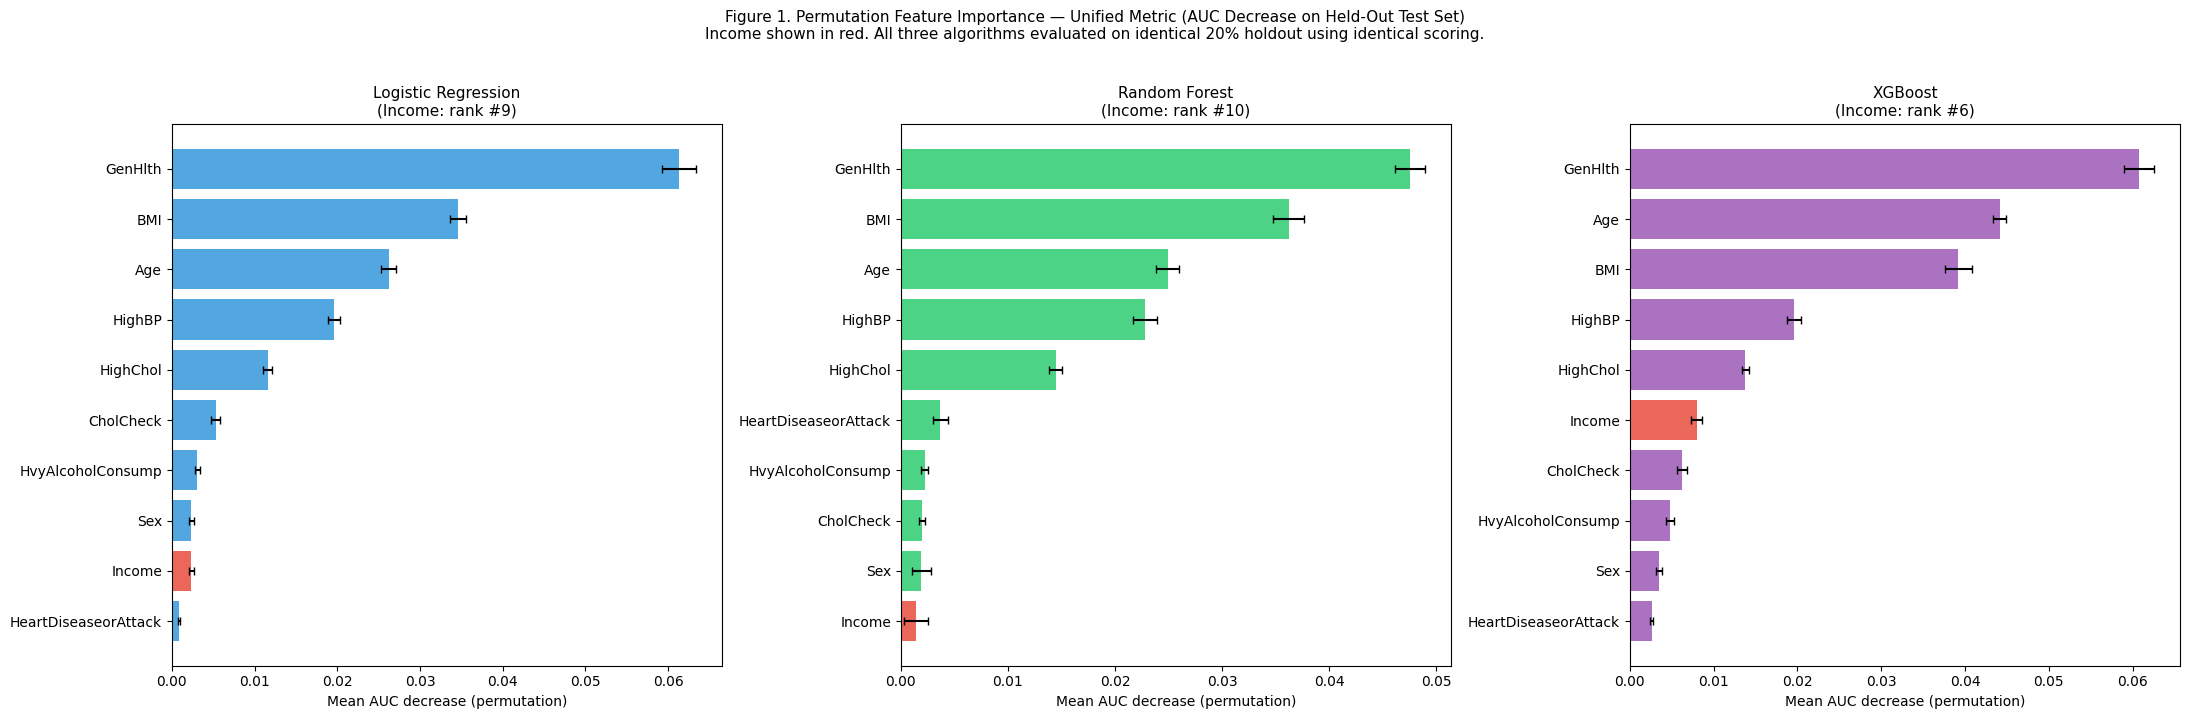


Saved: figure1_permutation_importance_unified.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)
X = df.drop(['Diabetes_012', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Train all three models ────────────────────────────────────────
print("Training models for unified permutation importance...")

lr = LogisticRegression(class_weight='balanced', max_iter=1000,
                        random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
print(f"LR AUC:  {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.3f}")

rf = RandomForestClassifier(class_weight='balanced', n_estimators=200,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"RF AUC:  {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")

xgb = XGBClassifier(scale_pos_weight=6, n_estimators=200, random_state=42,
                    eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train, y_train)
print(f"XGB AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.3f}")

# ── Permutation importance on identical held-out test set ─────────
# n_repeats=10 gives stable estimates; use roc_auc scoring
print("\nComputing permutation importance (this takes ~5-10 min)...")

perm_lr = permutation_importance(lr,  X_test, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=1)
perm_rf = permutation_importance(rf,  X_test, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=1)
perm_xgb = permutation_importance(xgb, X_test, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=1)

# ── Build unified ranking table ───────────────────────────────────
perm_df = pd.DataFrame({
    'Feature':     X.columns,
    'LR_mean':     perm_lr.importances_mean,
    'LR_sd':       perm_lr.importances_std,
    'RF_mean':     perm_rf.importances_mean,
    'RF_sd':       perm_rf.importances_std,
    'XGB_mean':    perm_xgb.importances_mean,
    'XGB_sd':      perm_xgb.importances_std,
})

perm_df['LR_rank']  = perm_df['LR_mean'].rank(ascending=False).astype(int)
perm_df['RF_rank']  = perm_df['RF_mean'].rank(ascending=False).astype(int)
perm_df['XGB_rank'] = perm_df['XGB_mean'].rank(ascending=False).astype(int)
perm_df = perm_df.sort_values('LR_mean', ascending=False).reset_index(drop=True)

print("\n=== UNIFIED PERMUTATION IMPORTANCE (ROC-AUC drop, mean ± SD) ===")
print(f"{'Feature':<25} {'LR':>16} {'Rank':>5}  {'RF':>16} {'Rank':>5}  {'XGB':>16} {'Rank':>5}")
print("-" * 90)
for _, row in perm_df.iterrows():
    flag = " ◄ INCOME" if row['Feature'] == 'Income' else ""
    print(f"{row['Feature']:<25} "
          f"{row['LR_mean']:>+8.4f}±{row['LR_sd']:.4f} {int(row['LR_rank']):>5}  "
          f"{row['RF_mean']:>+8.4f}±{row['RF_sd']:.4f} {int(row['RF_rank']):>5}  "
          f"{row['XGB_mean']:>+8.4f}±{row['XGB_sd']:.4f} {int(row['XGB_rank']):>5}{flag}")

income_row = perm_df[perm_df['Feature'] == 'Income'].iloc[0]
print(f"\nIncome ranks: LR={int(income_row['LR_rank'])}, "
      f"RF={int(income_row['RF_rank'])}, XGB={int(income_row['XGB_rank'])}")
print("All three use identical metric (AUC drop on identical test set) — comparison is valid.")

# ── Plot top 10 per model ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
configs = [
    ('LR_mean',  'LR_sd',  'LR_rank',  'Logistic Regression', '#3498db'),
    ('RF_mean',  'RF_sd',  'RF_rank',  'Random Forest',       '#2ecc71'),
    ('XGB_mean', 'XGB_sd', 'XGB_rank', 'XGBoost',             '#9b59b6'),
]

for ax, (mean_col, sd_col, rank_col, title, color) in zip(axes, configs):
    top10 = perm_df.nsmallest(10, rank_col).sort_values(mean_col)
    colors = ['#e74c3c' if f == 'Income' else color for f in top10['Feature']]
    ax.barh(range(10), top10[mean_col], xerr=top10[sd_col],
            color=colors, capsize=3, alpha=0.85)
    ax.set_yticks(range(10))
    ax.set_yticklabels(top10['Feature'], fontsize=10)
    ax.set_xlabel('Mean AUC decrease (permutation)', fontsize=10)
    income_rank = int(perm_df.loc[perm_df['Feature']=='Income', rank_col].values[0])
    ax.set_title(f'{title}\n(Income: rank #{income_rank})', fontsize=11)
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')

plt.suptitle(
    'Figure 1. Permutation Feature Importance — Unified Metric (AUC Decrease on Held-Out Test Set)\n'
    'Income shown in red. All three algorithms evaluated on identical 20% holdout using identical scoring.',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig('figure1_permutation_importance_unified.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: figure1_permutation_importance_unified.png")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)
X = df.drop(['Diabetes_012', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== CV AUC FOR TABLE 2 ===\n")
print("Running 5-fold CV for XGBoost and Random Forest...")
print("(~3-5 minutes total)\n")

cv_xgb = cross_val_score(
    XGBClassifier(scale_pos_weight=6, n_estimators=200, random_state=42,
                  eval_metric='logloss', n_jobs=-1),
    X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1
)

cv_rf = cross_val_score(
    RandomForestClassifier(class_weight='balanced', n_estimators=200,
                           random_state=42, n_jobs=-1),
    X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1
)

print("=== RESULTS — ADD TO TABLE 2 ===")
print(f"\nXGBoost CV AUC:       {cv_xgb.mean():.3f} (SD={cv_xgb.std():.3f})")
print(f"  Fold scores: {[f'{s:.3f}' for s in cv_xgb]}")

print(f"\nRandom Forest CV AUC: {cv_rf.mean():.3f} (SD={cv_rf.std():.3f})")
print(f"  Fold scores: {[f'{s:.3f}' for s in cv_rf]}")

print(f"\n=== TABLE 2 CV COLUMN (all models) ===")
print(f"Logistic Regression:  0.827 (0.003)  ← existing")
print(f"XGBoost:              {cv_xgb.mean():.3f} ({cv_xgb.std():.3f})")
print(f"Random Forest:        {cv_rf.mean():.3f} ({cv_rf.std():.3f})")
print(f"Decision Tree:        —  (near-chance AUC; CV not informative)")
print(f"No-clinical-test:     0.807 (0.003)  ← existing")
print(f"Interaction (targeted): —  (no separate CV run)")
print(f"LASSO interaction:    0.834 (CV from grid search)  ← existing")
print(f"BRFSS 2020 replication: —  (external replication, no CV)")

=== CV AUC FOR TABLE 2 ===

Running 5-fold CV for XGBoost and Random Forest...
(~3-5 minutes total)



/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


=== RESULTS — ADD TO TABLE 2 ===

XGBoost CV AUC:       0.820 (SD=0.002)
  Fold scores: ['0.822', '0.818', '0.820', '0.819', '0.822']

Random Forest CV AUC: 0.802 (SD=0.001)
  Fold scores: ['0.804', '0.801', '0.803', '0.803', '0.802']

=== TABLE 2 CV COLUMN (all models) ===
Logistic Regression:  0.827 (0.003)  ← existing
XGBoost:              0.820 (0.002)
Random Forest:        0.802 (0.001)
Decision Tree:        —  (near-chance AUC; CV not informative)
No-clinical-test:     0.807 (0.003)  ← existing
Interaction (targeted): —  (no separate CV run)
LASSO interaction:    0.834 (CV from grid search)  ← existing
BRFSS 2020 replication: —  (external replication, no CV)


In [ ]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from statsmodels.stats.proportion import proportion_confint

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df.drop_duplicates()
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)
X = df.drop(['Diabetes_012','target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

no_doc = ['BMI','Age','Sex','Income','Education','PhysActivity','Fruits',
          'Veggies','HvyAlcoholConsump','Smoker','GenHlth','MentHlth',
          'PhysHlth','DiffWalk']

def full_metrics(model, X_tr, X_te, y_tr, y_te, label):
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:,1]
    auc = roc_auc_score(y_te, y_prob)
    fpr_c, tpr_c, thresh_c = roc_curve(y_te, y_prob)
    idx = np.argmin(np.abs(tpr_c - 0.75))
    thresh = thresh_c[idx]
    y_pred = (y_prob >= thresh).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_te, y_pred).ravel()
    sens = tp/(tp+fn); spec = tn/(tn+fp)
    ppv = tp/(tp+fp); npv = tn/(tn+fn)
    sens_ci = proportion_confint(tp, tp+fn, method='wilson')
    spec_ci = proportion_confint(tn, tn+fp, method='wilson')
    ppv_ci  = proportion_confint(tp, tp+fp, method='wilson')
    npv_ci  = proportion_confint(tn, tn+fn, method='wilson')
    print(f"\n=== {label} (de-duplicated) ===")
    print(f"AUC:         {auc:.3f}")
    print(f"Threshold:   {thresh:.3f}")
    print(f"Sensitivity: {sens:.3f} (95% CI: {sens_ci[0]:.3f}–{sens_ci[1]:.3f})")
    print(f"Specificity: {spec:.3f} (95% CI: {spec_ci[0]:.3f}–{spec_ci[1]:.3f})")
    print(f"PPV:         {ppv:.3f} (95% CI: {ppv_ci[0]:.3f}–{ppv_ci[1]:.3f})")
    print(f"NPV:         {npv:.3f} (95% CI: {npv_ci[0]:.3f}–{npv_ci[1]:.3f})")

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
full_metrics(lr, X_train, X_test, y_train, y_test, "Full model")

lr_nd = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
full_metrics(lr_nd, X_train[no_doc], X_test[no_doc], y_train, y_test, "No-clinical-test")


=== Full model (de-duplicated) ===
AUC:         0.814
Threshold:   0.507
Sensitivity: 0.750 (95% CI: 0.740–0.760)
Specificity: 0.728 (95% CI: 0.724–0.733)
PPV:         0.338 (95% CI: 0.330–0.345)
NPV:         0.940 (95% CI: 0.938–0.943)

=== No-clinical-test (de-duplicated) ===
AUC:         0.789
Threshold:   0.480
Sensitivity: 0.750 (95% CI: 0.740–0.760)
Specificity: 0.688 (95% CI: 0.683–0.693)
PPV:         0.307 (95% CI: 0.300–0.314)
NPV:         0.937 (95% CI: 0.934–0.940)


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df.drop_duplicates()
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)

diabetic = df[df['target']==1]
non_diab = df[df['target']==0]

continuous = {'Age': 'Age', 'BMI': 'BMI', 'Income': 'Income'}
binary = {'HighBP':'High BP','HighChol':'High Chol','PhysActivity':'PhysActivity',
          'Sex':'Female sex','NoDocbcCost':'No doc cost'}

print("=== TABLE 1 STATISTICAL TESTS ===\n")
print("Continuous variables (Welch t-test):")
for col, label in continuous.items():
    t, p = stats.ttest_ind(diabetic[col].dropna(), non_diab[col].dropna(), equal_var=False)
    print(f"  {label}: t={t:.2f}, p{'<0.001' if p<0.001 else f'={p:.3f}'}")

print("\nCategorical variables (chi-squared):")
for col, label in binary.items():
    ct = pd.crosstab(df['target'], df[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  {label}: chi2={chi2:.1f}, df={dof}, p{'<0.001' if p<0.001 else f'={p:.3f}'}")

=== TABLE 1 STATISTICAL TESTS ===

Continuous variables (Welch t-test):
  Age: t=107.62, p<0.001
  BMI: t=93.43, p<0.001
  Income: t=-65.72, p<0.001

Categorical variables (chi-squared):
  High BP: chi2=15263.5, df=1, p<0.001
  High Chol: chi2=9041.6, df=1, p<0.001
  PhysActivity: chi2=2393.6, df=1, p<0.001
  Female sex: chi2=244.1, df=1, p<0.001
  No doc cost: chi2=105.3, df=1, p<0.001


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df.drop_duplicates()
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)
X = df.drop(['Diabetes_012', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': lr.coef_[0],
    'Abs_Coef':    np.abs(lr.coef_[0])
}).sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

print(f"Model intercept: {lr.intercept_[0]:.6f}")
print(f"\nStandardized coefficients (sorted by absolute magnitude):")
print(coef_df[['Feature','Coefficient']].to_string(index=False))
print(f"\nFor TRIPOD 15a — paste into Data/Code Availability statement:")
print(f"Intercept = {lr.intercept_[0]:.4f}")
for _, row in coef_df.iterrows():
    print(f"  {row['Feature']}: {row['Coefficient']:.4f}")

Model intercept: -0.580826

Standardized coefficients (sorted by absolute magnitude):
             Feature  Coefficient
             GenHlth     0.591547
                 BMI     0.485397
                 Age     0.462545
              HighBP     0.350910
            HighChol     0.286203
           CholCheck     0.262389
   HvyAlcoholConsump    -0.193425
                 Sex     0.145941
              Income    -0.103724
HeartDiseaseorAttack     0.070584
            PhysHlth    -0.059292
            DiffWalk     0.036752
            MentHlth    -0.035801
              Stroke     0.034923
           Education    -0.023933
       AnyHealthcare     0.019303
              Fruits    -0.013642
             Veggies    -0.011595
              Smoker    -0.010252
        PhysActivity    -0.007735
         NoDocbcCost     0.007612

For TRIPOD 15a — paste into Data/Code Availability statement:
Intercept = -0.5808
  GenHlth: 0.5915
  BMI: 0.4854
  Age: 0.4625
  HighBP: 0.3509
  HighChol: 0.2862
 

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, confusion_matrix
from statsmodels.stats.proportion import proportion_confint

# ── Load raw XPT and extract weights ─────────────────────────────
print("Loading raw BRFSS 2015 XPT...")
raw = pd.read_sas('LLCP2015.XPT ', format='xport', encoding='latin1')
print(f"Raw rows: {len(raw):,}")

# The primary BRFSS final weight variable
WEIGHT_COL = '_LLCPWT'
if WEIGHT_COL not in raw.columns:
    print(f"WARNING: {WEIGHT_COL} not found. Available weight cols:")
    print([c for c in raw.columns if 'WT' in c.upper() or 'WEIGHT' in c.upper()])
else:
    print(f"Weight column found: {WEIGHT_COL}")

# ── Map raw BRFSS to Kaggle variable names ────────────────────────
col_map = {
    'DIABETE3':'Diabetes_012','_RFHYPE5':'HighBP','_RFCHOL':'HighChol',
    'CHOLCHK':'CholCheck','_BMI5':'BMI','SMOKE100':'Smoker',
    'CVDSTRK3':'Stroke','_MICHD':'HeartDiseaseorAttack',
    '_TOTINDA':'PhysActivity','_FRTLT1':'Fruits','_VEGLT1':'Veggies',
    '_RFDRHV5':'HvyAlcoholConsump','HLTHPLN1':'AnyHealthcare',
    'MEDCOST':'NoDocbcCost','GENHLTH':'GenHlth','MENTHLTH':'MentHlth',
    'PHYSHLTH':'PhysHlth','DIFFWALK':'DiffWalk','SEX':'Sex',
    '_AGEG5YR':'Age','EDUCA':'Education','INCOME2':'Income',
}

present = [k for k in col_map if k in raw.columns]
df_raw = raw[present + ([WEIGHT_COL] if WEIGHT_COL in raw.columns else [])].copy()
df_raw = df_raw.rename(columns={k: col_map[k] for k in present})
df_raw['Income'] = df_raw['Income'].replace({77.0: np.nan, 99.0: np.nan})
# ── Recode to Kaggle binary format ───────────────────────────────
recode = {
    'Diabetes_012':        {1.0:2.0, 3.0:0.0, 4.0:1.0},
    'HighBP':              {1.0:0.0, 2.0:1.0},
    'HighChol':            {1.0:0.0, 2.0:1.0},
    'CholCheck':           {1.0:1.0, 2.0:0.0},
    'Smoker':              {1.0:1.0, 2.0:0.0},
    'Stroke':              {1.0:1.0, 2.0:0.0},
    'HeartDiseaseorAttack':{1.0:1.0, 2.0:0.0},
    'PhysActivity':        {1.0:1.0, 2.0:0.0},
    'Fruits':              {1.0:1.0, 2.0:0.0},
    'Veggies':             {1.0:1.0, 2.0:0.0},
    'HvyAlcoholConsump':   {1.0:0.0, 2.0:1.0},
    'AnyHealthcare':       {1.0:1.0, 2.0:0.0},
    'NoDocbcCost':         {1.0:1.0, 2.0:0.0},
    'DiffWalk':            {1.0:1.0, 2.0:0.0},
    'Sex':                 {1.0:1.0, 2.0:0.0},
}
for col, mapping in recode.items():
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].map(mapping)

if 'BMI' in df_raw.columns:
    df_raw['BMI'] = df_raw['BMI'].replace({7777.0:np.nan, 9999.0:np.nan}) / 100.0
for col in ['MentHlth','PhysHlth']:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].replace({88.0:0.0, 77.0:np.nan, 99.0:np.nan})
for col in ['GenHlth','Age','Education','Diabetes_012']:
    df_raw[col] = df_raw[col].replace({7.0: np.nan, 9.0: np.nan,
                                        77.0: np.nan, 99.0: np.nan})

kaggle_cols = list(col_map.values())
available = [c for c in kaggle_cols if c in df_raw.columns]
df_raw_complete = df_raw[available + [WEIGHT_COL]].dropna()

# Remove pre-diabetics, create target
df_raw_complete = df_raw_complete[df_raw_complete['Diabetes_012'] != 1.0].copy()
df_raw_complete['target'] = (df_raw_complete['Diabetes_012'] == 2.0).astype(int)
weights = df_raw_complete[WEIGHT_COL].values
print(f"\nMatched raw complete cases (for weighting): {len(df_raw_complete):,}")

# ── Load Kaggle de-duplicated dataset ────────────────────────────
kaggle = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
kaggle = kaggle.drop_duplicates()
kaggle = kaggle[kaggle['Diabetes_012'] != 1].copy()
kaggle['target'] = (kaggle['Diabetes_012'] == 2).astype(int)
print(f"Kaggle de-duplicated: {len(kaggle):,}")

# ── Weighted prevalence by income bracket ─────────────────────────
income_map = {1:'<$10k',2:'$10-15k',3:'$15-20k',4:'$20-25k',
              5:'$25-35k',6:'$35-50k',7:'$50-75k',8:'$75k+'}

print("\n=== WEIGHTED vs UNWEIGHTED PREVALENCE BY INCOME BRACKET ===")
print(f"\n{'Income':<12} {'Unweighted N':>14} {'Unweighted %':>14} "
      f"{'Weighted N':>12} {'Weighted %':>12} {'Diff (pp)':>10}")
print("-"*80)

unweighted_totals = []
weighted_totals = []

for level in sorted(income_map.keys()):
    # Unweighted (from Kaggle de-duped)
    mask_k = kaggle['Income'] == level
    n_k = mask_k.sum()
    cases_k = kaggle.loc[mask_k, 'target'].sum()
    prev_k = cases_k / n_k * 100 if n_k > 0 else np.nan

    # Weighted (from raw XPT)
    mask_r = df_raw_complete['Income'] == float(level)
    sub = df_raw_complete[mask_r]
    w = sub[WEIGHT_COL]
    w_total = w.sum()
    w_cases = w[sub['target'] == 1].sum()
    prev_w = w_cases / w_total * 100 if w_total > 0 else np.nan

    diff = prev_w - prev_k
    print(f"{income_map[level]:<12} {n_k:>14,} {prev_k:>13.1f}% "
          f"{w_total:>12,.0f} {prev_w:>11.1f}% {diff:>+9.1f}pp")
    unweighted_totals.append((cases_k, n_k))
    weighted_totals.append((w_cases, w_total))

# Overall gradient
uw_cases = sum(x[0] for x in unweighted_totals)
uw_n     = sum(x[1] for x in unweighted_totals)
w_cases_all  = sum(x[0] for x in weighted_totals)
w_n_all      = sum(x[1] for x in weighted_totals)

low5_uw_cases = sum(unweighted_totals[i][0] for i in range(5))
low5_uw_n     = sum(unweighted_totals[i][1] for i in range(5))
low5_w_cases  = sum(weighted_totals[i][0]   for i in range(5))
low5_w_n      = sum(weighted_totals[i][1]   for i in range(5))

print(f"\n=== GRADIENT COMPARISON ===")
print(f"Unweighted: <$10k prev = {unweighted_totals[0][0]/unweighted_totals[0][1]*100:.1f}%, "
      f"$75k+ prev = {unweighted_totals[7][0]/unweighted_totals[7][1]*100:.1f}%")
print(f"Weighted:   <$10k prev = {weighted_totals[0][0]/weighted_totals[0][1]*100:.1f}%, "
      f"$75k+ prev = {weighted_totals[7][0]/weighted_totals[7][1]*100:.1f}%")

print(f"\nUnweighted 32.7%/49.8% finding:")
print(f"  Low-income 5 brackets: {low5_uw_cases/uw_cases*100:.1f}% of cases, "
      f"{low5_uw_n/uw_n*100:.1f}% of sample")
print(f"Weighted equivalent:")
print(f"  Low-income 5 bracket)")

Loading raw BRFSS 2015 XPT...
Raw rows: 441,456
Weight column found: _LLCPWT

Matched raw complete cases (for weighting): 168,415
Kaggle de-duplicated: 225,152

=== WEIGHTED vs UNWEIGHTED PREVALENCE BY INCOME BRACKET ===

Income         Unweighted N   Unweighted %   Weighted N   Weighted %  Diff (pp)
--------------------------------------------------------------------------------
<$10k                 9,478          25.1%    3,782,409        21.3%      -3.8pp
$10-15k              11,401          27.1%    3,918,159        24.9%      -2.2pp
$15-20k              15,501          23.0%    5,598,596        20.2%      -2.7pp
$20-25k              19,498          20.8%    7,117,122        19.3%      -1.5pp
$25-35k              24,758          18.1%    8,687,084        16.3%      -1.8pp
$35-50k              34,255          15.4%   12,025,542        13.1%      -2.2pp
$50-75k              39,454          13.2%   14,069,049        11.4%      -1.8pp
$75k+                70,807           9.9%   31,63

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, confusion_matrix
from statsmodels.stats.proportion import proportion_confint

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df.drop_duplicates()
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)
X = df.drop(['Diabetes_012','target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

no_doc = ['BMI','Age','Sex','Income','Education','PhysActivity','Fruits',
          'Veggies','HvyAlcoholConsump','Smoker','GenHlth','MentHlth',
          'PhysHlth','DiffWalk']

model = LogisticRegression(class_weight='balanced', max_iter=1000,
                           random_state=42, n_jobs=-1)
model.fit(X_train[no_doc], y_train)
y_prob = model.predict_proba(X_test[no_doc])[:,1]

income_map = {1:'<$10k',2:'$10-15k',3:'$15-20k',4:'$20-25k',
              5:'$25-35k',6:'$35-50k',7:'$50-75k',8:'$75k+'}

FIXED_THRESHOLD = 0.499
TARGET_SENS     = 0.75

print("=== INCOME-STRATIFIED THRESHOLD RECALIBRATION ===")
print(f"\nFixed threshold (current): {FIXED_THRESHOLD}")
print(f"Target sensitivity for recalibration: {TARGET_SENS:.0%}\n")

print(f"{'Income':<12} {'N':>6} {'Fixed Thresh':>13} {'Fixed Sens':>11} "
      f"{'Fixed Spec':>11} {'Recal Thresh':>13} {'Recal Sens':>11} "
      f"{'Recal Spec':>11} {'Recal PPV':>10} {'Recal NPV':>10}")
print("-"*115)

rows = []
for level in sorted(income_map.keys()):
    mask = (X_test['Income'] == level).values
    y_sub   = y_test.values[mask]
    p_sub   = y_prob[mask]
    if len(y_sub) < 10 or y_sub.sum() < 5:
        continue

    # Fixed threshold performance
    y_pred_fixed = (p_sub >= FIXED_THRESHOLD).astype(int)
    tn_f,fp_f,fn_f,tp_f = confusion_matrix(y_sub, y_pred_fixed).ravel()
    sens_f = tp_f/(tp_f+fn_f)
    spec_f = tn_f/(tn_f+fp_f)

    # Income-specific threshold for ~75% sensitivity
    fpr_c, tpr_c, thresh_c = roc_curve(y_sub, p_sub)
    idx = np.argmin(np.abs(tpr_c - TARGET_SENS))
    recal_thresh = thresh_c[idx]

    y_pred_recal = (p_sub >= recal_thresh).astype(int)
    tn_r,fp_r,fn_r,tp_r = confusion_matrix(y_sub, y_pred_recal).ravel()
    sens_r = tp_r/(tp_r+fn_r)
    spec_r = tn_r/(tn_r+fp_r)
    ppv_r  = tp_r/(tp_r+fp_r) if (tp_r+fp_r) > 0 else np.nan
    npv_r  = tn_r/(tn_r+fn_r) if (tn_r+fn_r) > 0 else np.nan

    rows.append({
        'Income': income_map[level], 'N': len(y_sub),
        'Fixed_thresh': FIXED_THRESHOLD, 'Fixed_sens': sens_f, 'Fixed_spec': spec_f,
        'Recal_thresh': recal_thresh,
        'Recal_sens': sens_r, 'Recal_spec': spec_r,
        'Recal_PPV': ppv_r, 'Recal_NPV': npv_r,
    })
    print(f"{income_map[level]:<12} {len(y_sub):>6,} {FIXED_THRESHOLD:>13.3f} "
          f"{sens_f:>10.1%} {spec_f:>11.1%} {recal_thresh:>13.3f} "
          f"{sens_r:>10.1%} {spec_r:>11.1%} {ppv_r:>10.1%} {npv_r:>10.1%}")

res = pd.DataFrame(rows)

print(f"\n=== FAIRNESS IMPROVEMENT SUMMARY ===")
print(f"Fixed threshold sensitivity range:        "
      f"{res['Fixed_sens'].max():.1%} – {res['Fixed_sens'].min():.1%} "
      f"(range = {res['Fixed_sens'].max()-res['Fixed_sens'].min():.3f})")
print(f"Recalibrated sensitivity range:           "
      f"{res['Recal_sens'].max():.1%} – {res['Recal_sens'].min():.1%} "
      f"(range = {res['Recal_sens'].max()-res['Recal_sens'].min():.3f})")
print(f"\nFixed threshold specificity range:        "
      f"{res['Fixed_spec'].min():.1%} – {res['Fixed_spec'].max():.1%}")
print(f"Recalibrated specificity range:           "
      f"{res['Recal_spec'].min():.1%} – {res['Recal_spec'].max():.1%}")

print(f"\n=== TEXT-READY OUTPUT FOR MANUSCRIPT ===")
print("Income-specific thresholds achieving ~75% sensitivity:")
for _, r in res.iterrows():
    print(f"  {r['Income']}: threshold {r['Recal_thresh']:.3f} → "
          f"sensitivity {r['Recal_sens']:.1%}, specificity {r['Recal_spec']:.1%}, "
          f"PPV {r['Recal_PPV']:.1%}")

# Equalized odds after recalibration
tpr_range_recal = res['Recal_sens'].max() - res['Recal_sens'].min()
fpr_recal = 1 - res['Recal_spec']
fpr_range_recal = fpr_recal.max() - fpr_recal.min()
eod_recal = abs(tpr_range_recal - fpr_range_recal)
print(f"\nEqualized odds difference after recalibration: {eod_recal:.3f}")
print(f"(Original fixed threshold: 0.128)")
print(f"Reduction: {0.128 - eod_recal:.3f} percentage points")

=== INCOME-STRATIFIED THRESHOLD RECALIBRATION ===

Fixed threshold (current): 0.499
Target sensitivity for recalibration: 75%

Income            N  Fixed Thresh  Fixed Sens  Fixed Spec  Recal Thresh  Recal Sens  Recal Spec  Recal PPV  Recal NPV
-------------------------------------------------------------------------------------------------------------------
<$10k         1,907         0.499      88.4%       48.6%         0.614      75.1%       63.1%      41.5%      87.9%
$10-15k       2,189         0.499      89.3%       40.4%         0.643      75.0%       62.0%      43.2%      86.6%
$15-20k       3,034         0.499      83.9%       51.0%         0.572      75.0%       59.9%      35.8%      88.9%
$20-25k       3,897         0.499      82.3%       55.2%         0.566      75.0%       64.2%      35.7%      90.7%
$25-35k       4,992         0.499      77.4%       61.5%         0.518      74.9%       63.9%      31.6%      92.0%
$35-50k       6,804         0.499      72.5%       68.6%   

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, confusion_matrix

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)
X = df.drop(['Diabetes_012', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

no_doctor_needed = ['BMI', 'Age', 'Sex', 'Income', 'Education',
                    'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'Smoker',
                    'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']

full_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
full_model.fit(X_train, y_train)
y_prob_full = full_model.predict_proba(X_test)[:, 1]

nodoc_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
nodoc_model.fit(X_train[no_doctor_needed], y_train)
y_prob_nodoc = nodoc_model.predict_proba(X_test[no_doctor_needed])[:, 1]

def metrics_at_sensitivity_target(y_true, y_prob, target_sens):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    idx = np.argmin(np.abs(tpr - target_sens))
    thresh = thresholds[idx]
    y_pred = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens  = tp / (tp + fn)
    spec  = tn / (tn + fp)
    ppv   = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv   = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    return thresh, sens, spec, ppv, npv

targets = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85]

print("=== THRESHOLD SENSITIVITY ANALYSIS ===\n")
print("Full Model (All 21 Features):")
print(f"{'Target Sens':>12} {'Threshold':>10} {'Actual Sens':>12} {'Specificity':>12} {'PPV':>8} {'NPV':>8}")
print("-" * 70)
for t in targets:
    thresh, sens, spec, ppv, npv = metrics_at_sensitivity_target(y_test.values, y_prob_full, t)
    marker = " ← selected" if abs(t - 0.75) < 0.01 else ""
    print(f"{t:>12.0%} {thresh:>10.3f} {sens:>12.1%} {spec:>12.1%} {ppv:>8.1%} {npv:>8.1%}{marker}")

print(f"\nNo-Clinical-Test Model (14 Features):")
print(f"{'Target Sens':>12} {'Threshold':>10} {'Actual Sens':>12} {'Specificity':>12} {'PPV':>8} {'NPV':>8}")
print("-" * 70)
for t in targets:
    thresh, sens, spec, ppv, npv = metrics_at_sensitivity_target(y_test.values, y_prob_nodoc, t)
    marker = " ← selected" if abs(t - 0.75) < 0.01 else ""
    print(f"{t:>12.0%} {thresh:>10.3f} {sens:>12.1%} {spec:>12.1%} {ppv:>8.1%} {npv:>8.1%}{marker}")

print("\nNote: 75% sensitivity target selected to align with published questionnaire-based")
print("screening benchmarks (Kokkorakis et al., 2023; FINDRISC validation literature)")
print("where missing one in four cases is the accepted upper bound for high-prevalence,")
print("treatable conditions with long presymptomatic windows.")

=== THRESHOLD SENSITIVITY ANALYSIS ===

Full Model (All 21 Features):
 Target Sens  Threshold  Actual Sens  Specificity      PPV      NPV
----------------------------------------------------------------------
         60%      0.645        60.0%        84.3%    38.8%    92.7%
         65%      0.610        65.0%        81.8%    37.2%    93.4%
         70%      0.567        70.0%        78.6%    35.1%    94.1%
         75%      0.521        75.0%        74.9%    33.1%    94.8% ← selected
         80%      0.471        80.0%        70.8%    31.1%    95.5%
         85%      0.417        85.0%        65.7%    29.1%    96.4%

No-Clinical-Test Model (14 Features):
 Target Sens  Threshold  Actual Sens  Specificity      PPV      NPV
----------------------------------------------------------------------
         60%      0.612        60.0%        82.2%    35.8%    92.5%
         65%      0.579        65.0%        79.5%    34.4%    93.2%
         70%      0.540        70.0%        76.1%    32.6%

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, confusion_matrix
from statsmodels.stats.proportion import proportion_confint

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)
X = df.drop(['Diabetes_012', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

no_doctor_needed = ['BMI', 'Age', 'Sex', 'Income', 'Education',
                    'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'Smoker',
                    'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']

nodoc_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
nodoc_model.fit(X_train[no_doctor_needed], y_train)
y_prob_nodoc = nodoc_model.predict_proba(X_test[no_doctor_needed])[:, 1]

# Derive threshold at 75% sensitivity
fpr_c, tpr_c, thresh_c = roc_curve(y_test, y_prob_nodoc)
threshold = thresh_c[np.argmin(np.abs(tpr_c - 0.75))]
print(f"Fixed threshold: {threshold:.3f}\n")

income_map = {1:'<$10k', 2:'$10-15k', 3:'$15-20k', 4:'$20-25k',
              5:'$25-35k', 6:'$35-50k', 7:'$50-75k', 8:'$75k+'}

rows = []
for level in sorted(X_test['Income'].unique()):
    if level not in income_map:
        continue
    mask = (X_test['Income'] == level).values
    y_sub  = y_test.values[mask]
    p_sub  = y_prob_nodoc[mask]
    y_pred = (p_sub >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_sub, y_pred).ravel()

    sens = tp / (tp + fn)
    spec = tn / (tn + fp)

    # Wilson 95% CIs
    sens_lo, sens_hi = proportion_confint(tp, tp + fn, method='wilson')
    spec_lo, spec_hi = proportion_confint(tn, tn + fp, method='wilson')
    fpr_lo,  fpr_hi  = proportion_confint(fp, fp + tn, method='wilson')

    rows.append({
        'Income':       income_map[level],
        'N':            len(y_sub),
        'Diabetic_n':   int(tp + fn),
        'Sensitivity':  sens,
        'Sens_95CI':    f"({sens_lo:.3f}–{sens_hi:.3f})",
        'Specificity':  spec,
        'Spec_95CI':    f"({spec_lo:.3f}–{spec_hi:.3f})",
        'FPR':          fp / (fp + tn),
        'FPR_95CI':     f"({fpr_lo:.3f}–{fpr_hi:.3f})",
    })

res = pd.DataFrame(rows)

print("=== FAIRNESS AUDIT WITH 95% WILSON CIs ===")
print(f"\n{'Income':<12} {'N':>6} {'Sensitivity':>12} {'95% CI':>18} {'Specificity':>12} {'95% CI':>18}")
print("-" * 82)
for _, r in res.iterrows():
    print(f"{r['Income']:<12} {r['N']:>6,} {r['Sensitivity']:>12.3f} {r['Sens_95CI']:>18} {r['Specificity']:>12.3f} {r['Spec_95CI']:>18}")

# Equalized odds
tpr_range = res['Sensitivity'].max() - res['Sensitivity'].min()
fpr_range = res['FPR'].max() - res['FPR'].min()
eod = tpr_range - fpr_range

print(f"\n--- Equalized Odds Summary ---")
print(f"Sensitivity range: {res['Sensitivity'].min():.3f} – {res['Sensitivity'].max():.3f} (range = {tpr_range:.3f})")
print(f"FPR range:         {res['FPR'].min():.3f} – {res['FPR'].max():.3f} (range = {fpr_range:.3f})")
print(f"Equalized odds difference (|TPR range – FPR range|): {abs(eod):.3f}")

print("\n--- Text-ready summary for paper ---")
print(f"Sensitivity ranged from {res['Sensitivity'].min():.1%} "
      f"{res.loc[res['Sensitivity'].idxmin(), 'Sens_95CI']} "
      f"in the {res.loc[res['Sensitivity'].idxmin(), 'Income']} bracket "
      f"to {res['Sensitivity'].max():.1%} "
      f"{res.loc[res['Sensitivity'].idxmax(), 'Sens_95CI']} "
      f"in the {res.loc[res['Sensitivity'].idxmax(), 'Income']} bracket.")
print(f"Specificity ranged from {res['Specificity'].min():.1%} "
      f"{res.loc[res['Specificity'].idxmin(), 'Spec_95CI']} "
      f"to {res['Specificity'].max():.1%} "
      f"{res.loc[res['Specificity'].idxmax(), 'Spec_95CI']}.")
print(f"Equalized odds difference: {abs(eod):.3f}.")

Fixed threshold: 0.499

=== FAIRNESS AUDIT WITH 95% WILSON CIs ===

Income            N  Sensitivity             95% CI  Specificity             95% CI
----------------------------------------------------------------------------------
<$10k         1,912        0.881      (0.849–0.907)        0.436      (0.411–0.462)
$10-15k       2,241        0.915      (0.890–0.934)        0.380      (0.356–0.404)
$15-20k       3,116        0.892      (0.868–0.912)        0.468      (0.448–0.488)
$20-25k       3,970        0.840      (0.813–0.864)        0.538      (0.520–0.555)
$25-35k       5,027        0.804      (0.776–0.829)        0.602      (0.587–0.617)
$35-50k       7,186        0.748      (0.720–0.773)        0.686      (0.675–0.698)
$50-75k       8,470        0.657      (0.628–0.685)        0.778      (0.769–0.788)
$75k+        17,888        0.545      (0.519–0.570)        0.877      (0.872–0.882)

--- Equalized Odds Summary ---
Sensitivity range: 0.545 – 0.915 (range = 0.370)
FPR range:  

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import roc_auc_score
import statsmodels.stats.multitest as smm

# ── Data ──────────────────────────────────────────────────────────
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)
X = df.drop(['Diabetes_012', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_test_arr = y_test.values

# ── Model 1: Base LR ──────────────────────────────────────────────
base_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
base_lr.fit(X_train, y_train)
y_prob_base = base_lr.predict_proba(X_test)[:, 1]

# ── Model 2: Targeted interaction LR ─────────────────────────────
def add_interactions(d):
    d = d.copy()
    d['Income_x_BMI']   = d['Income'] * d['BMI']
    d['Income_x_Age']   = d['Income'] * d['Age']
    d['Income_x_HighBP']= d['Income'] * d['HighBP']
    d['BMI_x_Age']      = d['BMI']    * d['Age']
    return d

X_train_int = add_interactions(X_train)
X_test_int  = add_interactions(X_test)
targeted_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42, n_jobs=-1))
])
targeted_pipe.fit(X_train_int, y_train)
y_prob_targeted = targeted_pipe.predict_proba(X_test_int)[:, 1]

# ── Model 3: LASSO interaction LR ────────────────────────────────
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_train_poly = pd.DataFrame(poly.fit_transform(X_train), columns=poly.get_feature_names_out(X.columns), index=X_train.index)
X_test_poly  = pd.DataFrame(poly.transform(X_test),      columns=poly.get_feature_names_out(X.columns), index=X_test.index)

lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso_lr', LogisticRegression(penalty='l1', solver='liblinear',
                                    class_weight='balanced', max_iter=2000, random_state=42))
])
gs = GridSearchCV(lasso_pipe, {'lasso_lr__C': [0.01, 0.001, 0.0001]}, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
gs.fit(X_train_poly, y_train)
best_lasso = gs.best_estimator_
y_prob_lasso = best_lasso.predict_proba(X_test_poly)[:, 1]

print(f"\nAUC check — Base: {roc_auc_score(y_test_arr, y_prob_base):.3f} | "
      f"Targeted: {roc_auc_score(y_test_arr, y_prob_targeted):.3f} | "
      f"LASSO: {roc_auc_score(y_test_arr, y_prob_lasso):.3f}")

# ── Bootstrap DeLong function ─────────────────────────────────────
def bootstrap_delong(y_true, p1, p2, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    diffs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            diffs.append(roc_auc_score(y_true[idx], p1[idx]) - roc_auc_score(y_true[idx], p2[idx]))
        except ValueError:
            continue
    diffs = np.array(diffs)
    ci_lo = np.percentile(diffs, 2.5)
    ci_hi = np.percentile(diffs, 97.5)
    p = 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))
    return ci_lo, ci_hi, p

# ── Run three comparisons ─────────────────────────────────────────
comparisons = {
    'Base vs. Targeted Interaction': (y_prob_base, y_prob_targeted),
    'Targeted Interaction vs. LASSO': (y_prob_targeted, y_prob_lasso),
    'Base vs. LASSO': (y_prob_base, y_prob_lasso),
}

print("\n=== DeLong's Test (Bootstrap) for Interaction Model AUC Differences ===")
raw_ps, names, summaries = [], [], []
for name, (p1, p2) in comparisons.items():
    auc1 = roc_auc_score(y_test_arr, p1)
    auc2 = roc_auc_score(y_test_arr, p2)
    diff = auc1 - auc2
    ci_lo, ci_hi, p = bootstrap_delong(y_test_arr, p1, p2)
    raw_ps.append(p)
    names.append(name)
    summaries.append(f"{name}: AUC1={auc1:.3f}, AUC2={auc2:.3f}, Diff={diff:.3f} (95% CI: [{ci_lo:.3f}, {ci_hi:.3f}], p={p:.4f})")
    print(f"\n--- {name} ---")
    print(f"  AUC1={auc1:.3f}, AUC2={auc2:.3f}, Diff={diff:.3f}")
    print(f"  95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]  |  Uncorrected p={p:.4f}")

reject, ps_corrected, _, _ = smm.multipletests(raw_ps, alpha=0.05, method='holm')
print("\n--- Holm-Bonferroni Correction ---")
for name, p_raw, p_corr, sig in zip(names, raw_ps, ps_corrected, reject):
    print(f"  {name}: corrected p={p_corr:.4f}  Significant={sig}")

print("\n=== Summary for Table 2 footnote ===")
for s in summaries:
    print(s)

Fitting 5 folds for each of 3 candidates, totalling 15 fits

AUC check — Base: 0.829 | Targeted: 0.831 | LASSO: 0.836

=== DeLong's Test (Bootstrap) for Interaction Model AUC Differences ===

--- Base vs. Targeted Interaction ---
  AUC1=0.829, AUC2=0.831, Diff=-0.002
  95% CI: [-0.002, -0.001]  |  Uncorrected p=0.0000

--- Targeted Interaction vs. LASSO ---
  AUC1=0.831, AUC2=0.836, Diff=-0.006
  95% CI: [-0.007, -0.005]  |  Uncorrected p=0.0000

--- Base vs. LASSO ---
  AUC1=0.829, AUC2=0.836, Diff=-0.008
  95% CI: [-0.009, -0.006]  |  Uncorrected p=0.0000

--- Holm-Bonferroni Correction ---
  Base vs. Targeted Interaction: corrected p=0.0000  Significant=True
  Targeted Interaction vs. LASSO: corrected p=0.0000  Significant=True
  Base vs. LASSO: corrected p=0.0000  Significant=True

=== Summary for Table 2 footnote ===
Base vs. Targeted Interaction: AUC1=0.829, AUC2=0.831, Diff=-0.002 (95% CI: [-0.002, -0.001], p=0.0000)
Targeted Interaction vs. LASSO: AUC1=0.831, AUC2=0.836, Diff=-

No-clinical-test threshold at ~75% sensitivity: 0.499

--- Fairness Audit: No-Clinical-Test Model ---
  label     N  Sensitivity  Specificity
  <$10k  1912     0.881250     0.436453
$10-15k  2241     0.914557     0.379739
$15-20k  3116     0.892247     0.467941
$20-25k  3970     0.840399     0.537563
$25-35k  5027     0.803922     0.601923
$35-50k  7186     0.747610     0.686482
$50-75k  8470     0.656816     0.778332
  $75k+ 17888     0.544693     0.877309

Range of Sensitivity (TPR): 0.370
Range of FPR:               0.498
Equalized Odds Difference:  -0.128


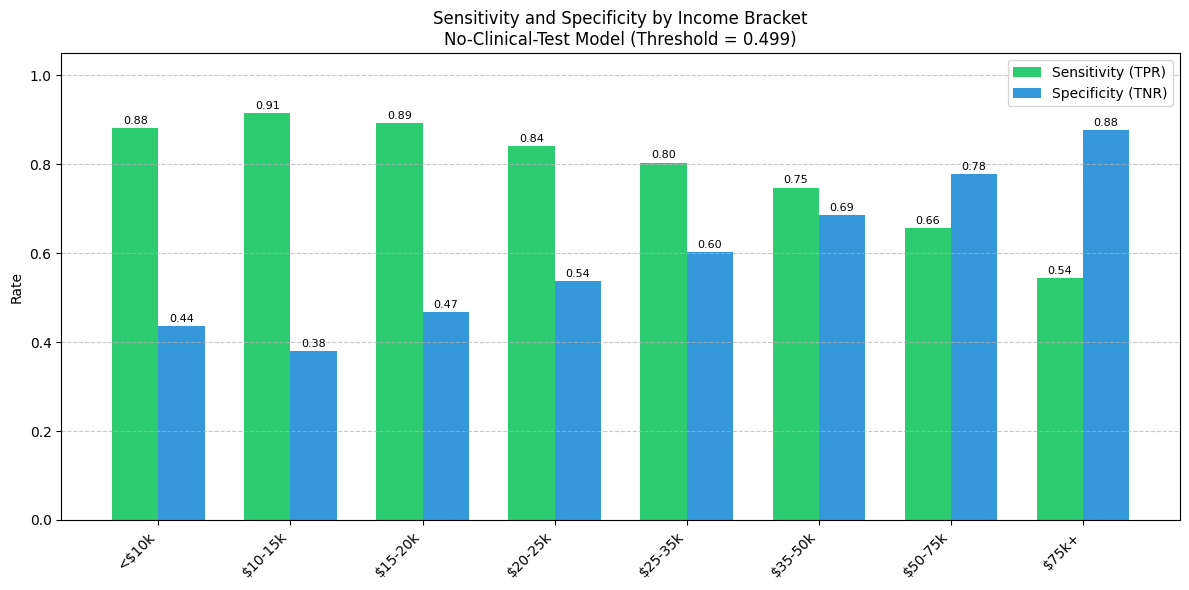

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, confusion_matrix

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df = df[df['Diabetes_012'] != 1].copy()
df['target'] = (df['Diabetes_012'] == 2).astype(int)
X = df.drop(['Diabetes_012', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

no_doctor_needed = ['BMI', 'Age', 'Sex', 'Income', 'Education',
                    'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'Smoker',
                    'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']

model_nodoc = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
model_nodoc.fit(X_train[no_doctor_needed], y_train)

X_nodoc_test = X_test[no_doctor_needed]
y_prob_nodoc  = model_nodoc.predict_proba(X_nodoc_test)[:, 1]

# Derive threshold at 75% sensitivity for this model
fpr_c, tpr_c, thresh_c = roc_curve(y_test, y_prob_nodoc)
idx_75 = np.argmin(np.abs(tpr_c - 0.75))
threshold_nodoc = thresh_c[idx_75]
print(f"No-clinical-test threshold at ~75% sensitivity: {threshold_nodoc:.3f}")

income_map = {1:'<$10k',2:'$10-15k',3:'$15-20k',4:'$20-25k',
              5:'$25-35k',6:'$35-50k',7:'$50-75k',8:'$75k+'}

results = []
for level in sorted(X_test['Income'].unique()):
    if level not in income_map:
        continue
    mask = (X_test['Income'] == level).values
    y_sub   = y_test.values[mask]
    p_sub   = y_prob_nodoc[mask]
    y_pred  = (p_sub >= threshold_nodoc).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_sub, y_pred).ravel()
    results.append({
        'label': income_map[level],
        'N': len(y_sub),
        'Sensitivity': tp/(tp+fn) if (tp+fn) > 0 else np.nan,
        'Specificity': tn/(tn+fp) if (tn+fp) > 0 else np.nan,
        'TPR': tp/(tp+fn) if (tp+fn) > 0 else np.nan,
        'FPR': fp/(fp+tn) if (fp+tn) > 0 else np.nan,
    })

res_df = pd.DataFrame(results)
print("\n--- Fairness Audit: No-Clinical-Test Model ---")
print(res_df[['label','N','Sensitivity','Specificity']].to_string(index=False))

tpr_range = res_df['TPR'].max() - res_df['TPR'].min()
fpr_range = res_df['FPR'].max() - res_df['FPR'].min()
eod = tpr_range - fpr_range
print(f"\nRange of Sensitivity (TPR): {tpr_range:.3f}")
print(f"Range of FPR:               {fpr_range:.3f}")
print(f"Equalized Odds Difference:  {eod:.3f}")

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(res_df))
w = 0.35
r1 = ax.bar(x - w/2, res_df['Sensitivity'], w, label='Sensitivity (TPR)', color='#2ecc71')
r2 = ax.bar(x + w/2, res_df['Specificity'], w, label='Specificity (TNR)', color='#3498db')
ax.set_ylabel('Rate')
ax.set_title(f'Sensitivity and Specificity by Income Bracket\n'
             f'No-Clinical-Test Model (Threshold = {threshold_nodoc:.3f})')
ax.set_xticks(x)
ax.set_xticklabels(res_df['label'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.7)
for rect in list(r1) + list(r2):
    h = rect.get_height()
    ax.annotate(f'{h:.2f}', xy=(rect.get_x()+rect.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fairness_audit_noclinical_corrected.png', dpi=150)
plt.show()

/tmp/ipykernel_16671/615427486.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot([df[df['target']==0]['BMI'], # Use 'target' column
/tmp/ipykernel_16671/615427486.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot([df[df['target']==0]['Age'], # Use 'target' column
/tmp/ipykernel_16671/615427486.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,2].boxplot([df[df['target']==0]['GenHlth'], # Use 'target' column


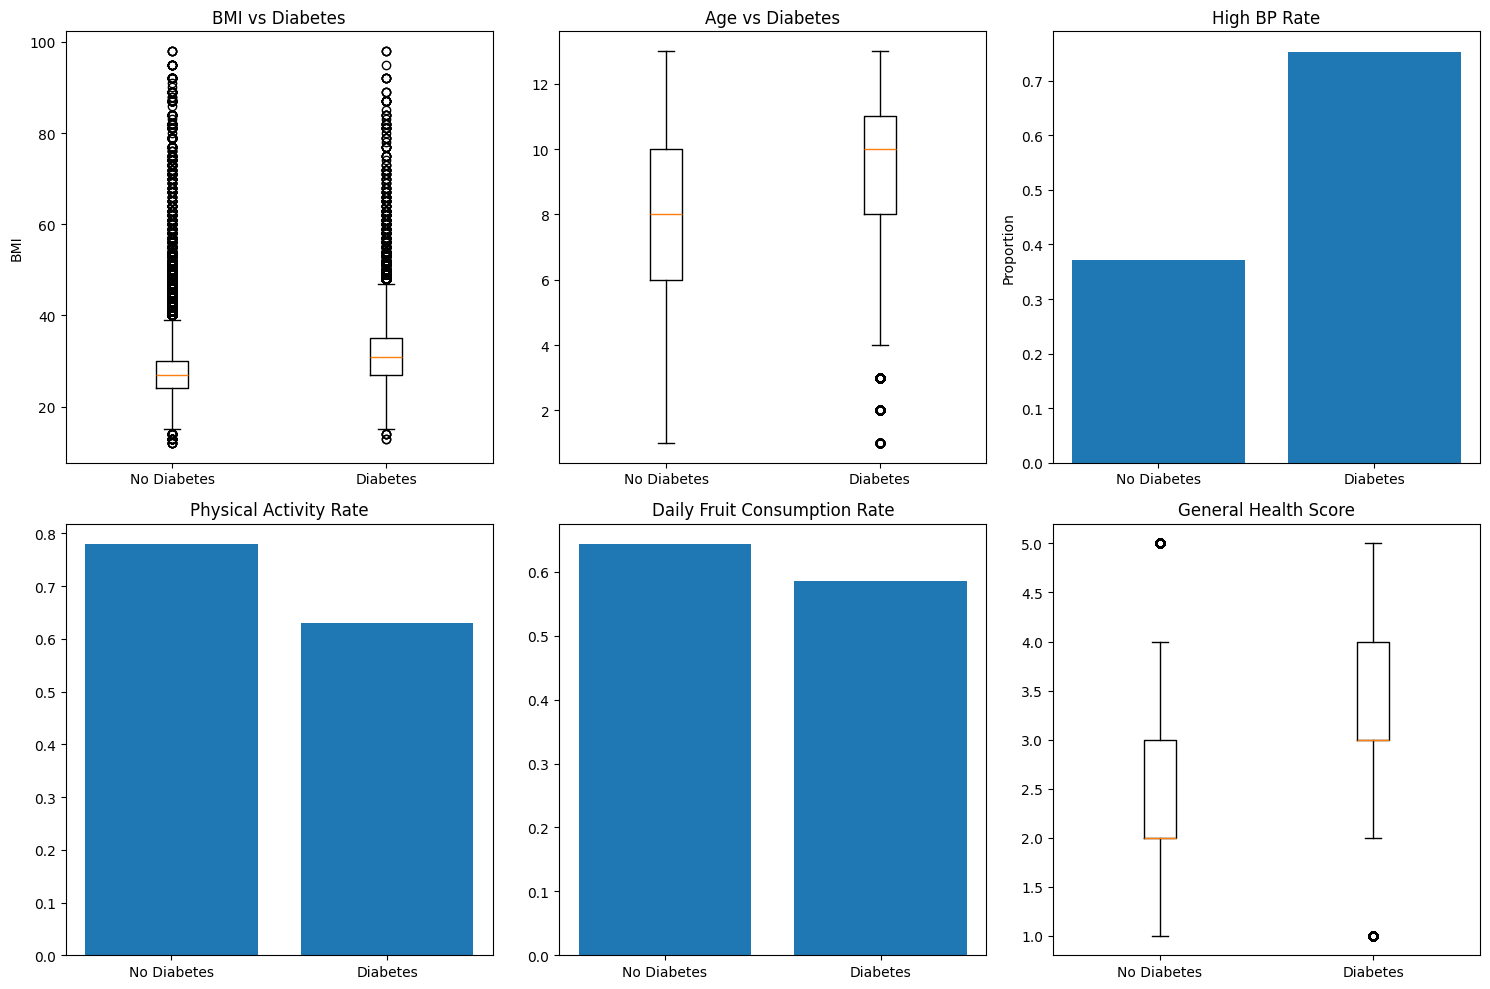

In [ ]:
import matplotlib.pyplot as plt

# Ensure 'df' is the binary version with 'target' column
if 'target' not in df.columns:
    # This block should ideally not be hit if previous cells are run correctly
    df_full_temp = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df = df_full_temp[df_full_temp['Diabetes_012'] != 1].copy()
    df['target'] = (df['Diabetes_012'] == 2).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# BMI vs Diabetes
axes[0,0].boxplot([df[df['target']==0]['BMI'], # Use 'target' column
                   df[df['target']==1]['BMI']],
                   labels=['No Diabetes', 'Diabetes'])
axes[0,0].set_title('BMI vs Diabetes')
axes[0,0].set_ylabel('BMI')

# Age vs Diabetes
axes[0,1].boxplot([df[df['target']==0]['Age'], # Use 'target' column
                   df[df['target']==1]['Age']],
                   labels=['No Diabetes', 'Diabetes'])
axes[0,1].set_title('Age vs Diabetes')

# High BP rate
bp_no = df[df['target']==0]['HighBP'].mean()
bp_yes = df[df['target']==1]['HighBP'].mean()
axes[0,2].bar(['No Diabetes', 'Diabetes'], [bp_no, bp_yes])
axes[0,2].set_title('High BP Rate')
axes[0,2].set_ylabel('Proportion')

# Physical Activity
pa_no = df[df['target']==0]['PhysActivity'].mean()
pa_yes = df[df['target']==1]['PhysActivity'].mean()
axes[1,0].bar(['No Diabetes', 'Diabetes'], [pa_no, pa_yes])
axes[1,0].set_title('Physical Activity Rate')

# Fruits consumption
fr_no = df[df['target']==0]['Fruits'].mean()
fr_yes = df[df['target']==1]['Fruits'].mean()
axes[1,1].bar(['No Diabetes', 'Diabetes'], [fr_no, fr_yes])
axes[1,1].set_title('Daily Fruit Consumption Rate')

# General Health
axes[1,2].boxplot([df[df['target']==0]['GenHlth'], # Use 'target' column
                   df[df['target']==1]['GenHlth']],
                   labels=['No Diabetes', 'Diabetes'])
axes[1,2].set_title('General Health Score')

plt.tight_layout()
plt.savefig('diabetes_exploration.png', dpi=150)
plt.show()

**Reasoning**:
The final instruction for this subtask is to save the processed DataFrame `df` to a new CSV file named `diabetes_clean.csv` for subsequent steps. This will complete the current subtask.



In [ ]:
import pandas as pd

# Re-load from source and ensure 'df' is the filtered binary version
# (This ensures robustness if cells are run out of order)
if 'df' not in globals() or 'target' not in df.columns:
    df_full_temp = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df = df_full_temp[df_full_temp['Diabetes_012'] != 1].copy()
    df['target'] = (df['Diabetes_012'] == 2).astype(int)

# Save the filtered binary DataFrame to CSV
df.to_csv('diabetes_clean.csv', index=False)
print("DataFrame saved to diabetes_clean.csv (excluding pre-diabetes).")

DataFrame saved to diabetes_clean.csv (excluding pre-diabetes).


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd # Ensure pandas is imported

# Ensure 'df' is the binary version with 'target' column
if 'df' not in globals() or 'target' not in df.columns:
    df_full_temp = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df = df_full_temp[df_full_temp['Diabetes_012'] != 1].copy() # Filter out pre-diabetes
    df['target'] = (df['Diabetes_012'] == 2).astype(int) # Create the binary target

# Use 'df' directly here as it's already the binary-filtered version
X = df.drop(['Diabetes_012', 'target'], axis=1) # Drop original Diabetes_012 and the new target column
y = df['target'] # Use the new binary target column

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training on {len(X_train):,} people")
print(f"Testing on {len(X_test):,} people")

# Train
print("\nTraining Random Forest...")
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes', 'Diabetes']))

Training on 199,239 people
Testing on 49,810 people

Training Random Forest...

Accuracy: 0.860
              precision    recall  f1-score   support

 No Diabetes       0.88      0.97      0.92     42741
    Diabetes       0.52      0.20      0.28      7069

    accuracy                           0.86     49810
   macro avg       0.70      0.58      0.60     49810
weighted avg       0.83      0.86      0.83     49810



In [ ]:
print("="*70)
print("TABLE 1: BASELINE CHARACTERISTICS OF STUDY POPULATION")
print("="*70)
print()

# stat calc by diabtes
# Ensure 'df' is the binary version with 'target' column
if 'df' not in globals() or 'target' not in df.columns:
    df_full_temp = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df = df_full_temp[df_full_temp['Diabetes_012'] != 1].copy()
    df['target'] = (df_full_temp['Diabetes_012'] == 2).astype(int)

# df_full is used to get the original pre-diabetes count
# Ensure df_full is available or load it
if 'df_full' not in globals():
    df_full = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')


no_diabetes = df[df['target'] == 0]
diabetes = df[df['target'] == 1]

print(f"{'Variable':<30} {'No Diabetes':<25} {'Diabetes':<25}")
print(f"{'':30} {'(n={:,})'.format(len(no_diabetes)):<25} {'(n={:,})'.format(len(diabetes)):<25}")
print("-"*80)

# CONTINUOUS VARIABLES (Mean ± SD)
print("\nCONTINUOUS VARIABLES (Mean ± SD)")
print("-"*80)

continuous_vars = {
    'BMI': 'Body Mass Index',
    'Age': 'Age (coded 1-13)',
    'MentHlth': 'Days of poor mental health',
    'PhysHlth': 'Days of poor physical health'
}

for var, description in continuous_vars.items():
    mean_no = no_diabetes[var].mean()
    std_no = no_diabetes[var].std()
    mean_yes = diabetes[var].mean()
    std_yes = diabetes[var].std()

    print(f"{description:<30} {mean_no:6.2f} \u00B1 {std_no:5.2f}{'':<11} {mean_yes:6.2f} \u00B1 {std_yes:5.2f}")

# CATEGORICAL/ORDINAL VARIABLES
print("\n" + "-"*80)
print("CATEGORICAL/ORDINAL VARIABLES")
print("-"*80)

ordinal_vars = {
    'Income': 'Household income (1-8 scale)',
    'Education': 'Education level (1-6 scale)',
    'GenHlth': 'General health (1-5 scale)'
}

for var, description in ordinal_vars.items():
    mean_no = no_diabetes[var].mean()
    std_no = no_diabetes[var].std()
    mean_yes = diabetes[var].mean()
    std_yes = diabetes[var].std()

    print(f"{description:<30} {mean_no:6.2f} \u00B1 {std_no:5.2f}{'':<11} {mean_yes:6.2f} \u00B1 {std_yes:5.2f}")

# BINARY var (% with condition)
print("\n" + "-"*80)
print("BINARY VARIABLES (% Yes)")
print("-"*80)

binary_vars = {
    'HighBP': 'High blood pressure',
    'HighChol': 'High cholesterol',
    'CholCheck': 'Cholesterol checked (5y)',
    'Smoker': 'Current smoker',
    'Stroke': 'History of stroke',
    'HeartDiseaseorAttack': 'Heart disease/MI',
    'PhysActivity': 'Physically active',
    'Fruits': 'Daily fruit consumption',
    'Veggies': 'Daily vegetable consumption',
    'HvyAlcoholConsump': 'Heavy alcohol use',
    'AnyHealthcare': 'Any healthcare coverage',
    'NoDocbcCost': 'Could not see doctor (cost)',
    'DiffWalk': 'Difficulty walking',
    'Sex': 'Male'
}

for var, description in binary_vars.items():
    pct_no = no_diabetes[var].mean() * 100
    pct_yes = diabetes[var].mean() * 100

    print(f"{description:<30} {pct_no:6.1f}%{'':<18} {pct_yes:6.1f}%")

# SUMMARY
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Total participants: {len(df):,}")
print(f"  No diabetes: {len(no_diabetes):,} ({len(no_diabetes)/len(df)*100:.1f}%)")
print(f"  Diabetes: {len(diabetes):,} ({len(diabetes)/len(df)*100:.1f}%)")
print(f"  Pre-diabetes (excluded): {df_full[df_full['Diabetes_012']==1].shape[0]:,}")
print(f"\nClass imbalance ratio: {len(no_diabetes)/len(diabetes):.1f}:1")
print("="*80)

# TABLE
print("\n\n" + "="*80)
print("="*80)
print()

print("TABLE 1. Baseline Characteristics of Study Population")
print()
print("Characteristic                 | No Diabetes        | Diabetes")
print("                               | (n={:,})        | (n={:,})".format(len(no_diabetes), len(diabetes)))
print("-------------------------------|--------------------|-----------------")
print("Demographics")
print(f"  Age (1-13 scale)             | {no_diabetes['Age'].mean():.2f} \u00B1 {no_diabetes['Age'].std():.2f}      | {diabetes['Age'].mean():.2f} \u00B1 {diabetes['Age'].std():.2f}")
print(f"  Male, %                      | {no_diabetes['Sex'].mean()*100:.1f}              | {diabetes['Sex'].mean()*100:.1f}")
print(f"  Income (1-8 scale)           | {no_diabetes['Income'].mean():.2f} \u00B1 {no_diabetes['Income'].std():.2f}      | {diabetes['Income'].mean():.2f} \u00B1 {diabetes['Income'].std():.2f}")
print(f"  Education (1-6 scale)        | {no_diabetes['Education'].mean():.2f} \u00B1 {no_diabetes['Education'].std():.2f}      | {diabetes['Education'].mean():.2f} \u00B1 {diabetes['Education'].std():.2f}")
print()
print("Clinical Measurements")
print(f"  BMI                          | {no_diabetes['BMI'].mean():.2f} \u00B1 {no_diabetes['BMI'].std():.2f}      | {diabetes['BMI'].mean():.2f} \u00B1 {diabetes['BMI'].std():.2f}")
print(f"  High blood pressure, %       | {no_diabetes['HighBP'].mean()*100:.1f}              | {diabetes['HighBP'].mean()*100:.1f}")
print(f"  High cholesterol, %          | {no_diabetes['HighChol'].mean()*100:.1f}              | {diabetes['HighChol'].mean()*100:.1f}")
print()
print("Health Behaviors")
print(f"  Current smoker, %            | {no_diabetes['Smoker'].mean()*100:.1f}              | {diabetes['Smoker'].mean()*100:.1f}")
print(f"  Physically active, %         | {no_diabetes['PhysActivity'].mean()*100:.1f}              | {diabetes['PhysActivity'].mean()*100:.1f}")
print(f"  Daily fruits, %              | {no_diabetes['Fruits'].mean()*100:.1f}              | {diabetes['Fruits'].mean()*100:.1f}")
print(f"  Daily vegetables, %          | {no_diabetes['Veggies'].mean()*100:.1f}              | {diabetes['Veggies'].mean()*100:.1f}")
print()
print("General Health")
print(f"  General health (1-5 scale)   | {no_diabetes['GenHlth'].mean():.2f} \u00B1 {no_diabetes['GenHlth'].std():.2f}      | {diabetes['GenHlth'].mean():.2f} \u00B1 {diabetes['GenHlth'].std():.2f}")
print(f"  Days poor mental health      | {no_diabetes['MentHlth'].mean():.2f} \u00B1 {no_diabetes['MentHlth'].std():.2f}     | {diabetes['MentHlth'].mean():.2f} \u00B1 {diabetes['MentHlth'].std():.2f}")
print(f"  Days poor physical health    | {no_diabetes['PhysHlth'].mean():.2f} \u00B1 {no_diabetes['PhysHlth'].std():.2f}     | {diabetes['PhysHlth'].mean():.2f} \u00B1 {diabetes['PhysHlth'].std():.2f}")
print(f"  Difficulty walking, %        | {no_diabetes['DiffWalk'].mean()*100:.1f}              | {diabetes['DiffWalk'].mean()*100:.1f}")
print()
print("Data are presented as mean \u00B1 SD or percentage.")
print("BMI = body mass index; SD = standard deviation")

TABLE 1: BASELINE CHARACTERISTICS OF STUDY POPULATION

Variable                       No Diabetes               Diabetes                 
                               (n=213,703)               (n=35,346)               
--------------------------------------------------------------------------------

CONTINUOUS VARIABLES (Mean ± SD)
--------------------------------------------------------------------------------
Body Mass Index                 27.74 ±  6.26             31.94 ±  7.36
Age (coded 1-13)                 7.79 ±  3.10              9.38 ±  2.33
Days of poor mental health       2.94 ±  7.06              4.46 ±  8.95
Days of poor physical health     3.58 ±  8.00              7.95 ± 11.30

--------------------------------------------------------------------------------
CATEGORICAL/ORDINAL VARIABLES
--------------------------------------------------------------------------------
Household income (1-8 scale)     6.21 ±  2.01              5.21 ±  2.22
Education level (1-6 scale)   

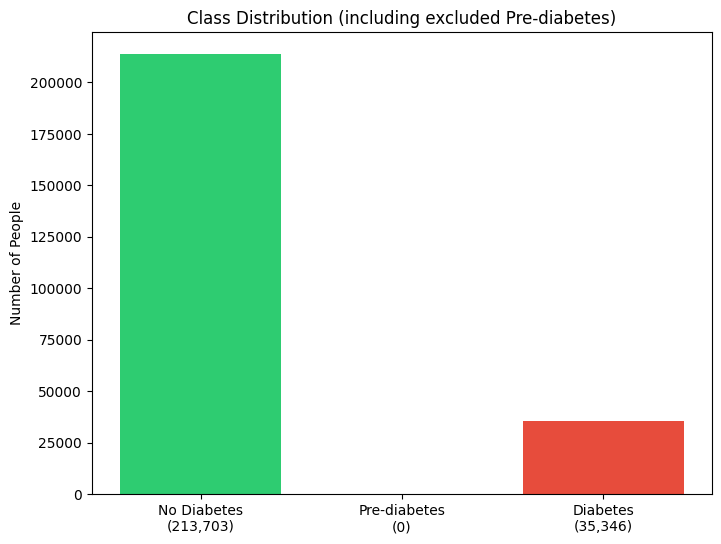

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

# Ensure 'df' is the binary version with 'target' column
if 'df' not in globals() or 'target' not in df.columns:
    df_full_temp = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df = df_full_temp[df_full_temp['Diabetes_012'] != 1].copy() # Filter out pre-diabetes
    df['target'] = (df['Diabetes_012'] == 2).astype(int) # Create the binary target

# Calculate counts from the correct df (binary version)
no_diabetes_count = len(df[df['target'] == 0])
diabetes_count = len(df[df['target'] == 1])

# Pre-diabetes count should be derived from the full dataset if needed for context,
# but explicitly excluded from the 'df' used for model training.
# For this plot, we want to represent the removed pre-diabetes for context.
if 'df_full' in globals():
    pre_diabetes_count = len(df_full[df_full['Diabetes_012'] == 1])
else:
    # If df_full is not in global scope, re-read it to get pre-diabetes count
    df_full_temp = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    pre_diabetes_count = len(df_full_temp[df_full_temp['Diabetes_012'] == 1])


labels = [f'No Diabetes\n({no_diabetes_count:,})',
          f'Pre-diabetes\n({pre_diabetes_count:,})',
          f'Diabetes\n({diabetes_count:,})']
sizes = [no_diabetes_count, pre_diabetes_count, diabetes_count]
colors = ['#2ecc71', '#f39c12', '#e74c3c']

plt.figure(figsize=(8,6))
plt.bar(labels, sizes, color=colors)
plt.title('Class Distribution (including excluded Pre-diabetes)')
plt.ylabel('Number of People')
plt.savefig('class_imbalance.png', dpi=150)
plt.show()
# Accuracy alone is misleading, especially with this imbalance.

In [ ]:
#comparison
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import pandas as pd # Ensure pandas is imported
import numpy as np # Ensure numpy is imported


model_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
y_prob_balanced = model_balanced.predict_proba(X_test)[:,1]

auc_balanced = roc_auc_score(y_test, y_prob_balanced)
print(f"ROC-AUC: {auc_balanced:.3f}")
print(classification_report(y_test, y_pred_balanced,
      target_names=['No Diabetes', 'Diabetes']))

# Extract coefficients and odds ratios
print("\n=== Model Coefficients & Odds Ratios ===")
coefficients = model_balanced.coef_[0]
odds_ratios = np.exp(coefficients)
feature_names = X.columns

# Create dataframe for easy viewing
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios,
    'Abs_Coef': np.abs(coefficients)
}).sort_values('Abs_Coef', ascending=False)

print("\nTop 10 Most Important Features (by absolute coefficient):")
print(coef_df.head(10).to_string(index=False))

print("\n=== Interpreting Odds Ratios ===")
print("Odds Ratio > 1: Feature INCREASES diabetes risk")
print("Odds Ratio < 1: Feature DECREASES diabetes risk")
print("Odds Ratio = 1: Feature has NO effect")

print(f"\n=== ALL {len(X.columns)} Features Ranked (Logistic Regression) ===")
print(coef_df.to_string(index=False))

from sklearn.preprocessing import StandardScaler

# ---- Income coefficient consistency check ----
income_std = X_train["Income"].std()

# Unscaled coefficient from current model
income_coef_unscaled = coef_df.loc[coef_df["Feature"] == "Income", "Coefficient"].values[0]
income_or_unscaled = np.exp(income_coef_unscaled)

# Scaled coefficient (fit on standardized features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
model_scaled.fit(X_train_scaled, y_train)

income_idx = list(X.columns).index("Income")
income_coef_scaled = model_scaled.coef_[0][income_idx]
income_or_scaled = np.exp(income_coef_scaled)

print("\n=== Income Coefficient Consistency Check ===")
print(f"Income std (train): {income_std:.4f}")
print(f"Unscaled coef (per unit): {income_coef_unscaled:.6f}  OR={income_or_unscaled:.4f}")
print(f"Scaled coef (per SD):     {income_coef_scaled:.6f}  OR={income_or_scaled:.4f}")
print(f"Scaled->unscaled approx:  {income_coef_scaled / income_std:.6f}")

print(f"\n=== ALL {len(X.columns)} Features Ranked (Logistic Regression) ===")
print(coef_df.to_string(index=False))
print("Number of features in X:", X.shape[1])
print("Feature list:", list(X.columns))

ROC-AUC: 0.829
              precision    recall  f1-score   support

 No Diabetes       0.95      0.73      0.83     42741
    Diabetes       0.32      0.77      0.45      7069

    accuracy                           0.74     49810
   macro avg       0.64      0.75      0.64     49810
weighted avg       0.86      0.74      0.77     49810


=== Model Coefficients & Odds Ratios ===

Top 10 Most Important Features (by absolute coefficient):
             Feature  Coefficient  Odds Ratio  Abs_Coef
           CholCheck     1.328899    3.776882  1.328899
   HvyAlcoholConsump    -0.750134    0.472303  0.750134
              HighBP     0.737053    2.089769  0.737053
            HighChol     0.600225    1.822528  0.600225
             GenHlth     0.585824    1.796472  0.585824
                 Sex     0.300433    1.350443  0.300433
HeartDiseaseorAttack     0.259129    1.295801  0.259129
                 Age     0.151123    1.163140  0.151123
              Stroke     0.150331    1.162219  0.1503

Training Logistic Regression...
Logistic Regression  ROC-AUC: 0.829
Training Decision Tree...
Decision Tree        ROC-AUC: 0.593
Training Random Forest...
Random Forest        ROC-AUC: 0.805
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:03:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost              ROC-AUC: 0.826


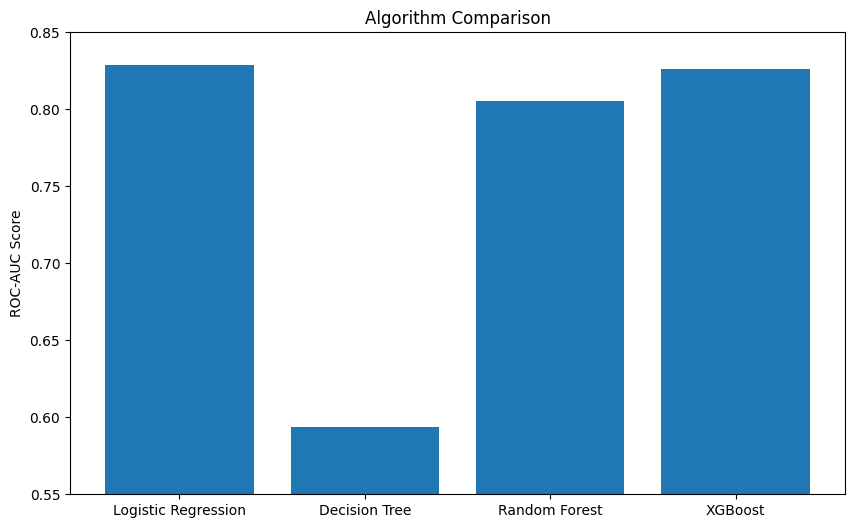

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

algorithms = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=6, random_state=42, n_estimators=200, eval_metric='logloss', use_label_encoder=False)
}

# Train models and store AUC for comparison
results = {}
for name, model in algorithms.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = auc
    print(f"{name:20} ROC-AUC: {auc:.3f}")

# Plot comparison
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values())
plt.ylabel('ROC-AUC Score')
plt.title('Algorithm Comparison')
plt.ylim(0.550, 0.85)
plt.savefig('algorithm_comparison.png')
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np
import pandas as pd

lr_scaled = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    ))
])

lr_scaled.fit(X_train, y_train)

y_pred = lr_scaled.predict(X_test)
y_prob = lr_scaled.predict_proba(X_test)[:, 1]

auc_scaled = roc_auc_score(y_test, y_prob)
print(f"Scaled LR ROC-AUC: {auc_scaled:.3f}")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

# ---- coefficient table (now in standardized units) ----
coefs = lr_scaled.named_steps["lr"].coef_[0]
feature_names = X.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs,
    "OddsRatio_per_1SD": np.exp(coefs),
    "Abs_Coef": np.abs(coefs)
}).sort_values("Abs_Coef", ascending=False)

print("\n=== ALL FEATURES Ranked (Scaled Logistic Regression) ===")
print(coef_df.to_string(index=False))

Scaled LR ROC-AUC: 0.829
              precision    recall  f1-score   support

 No Diabetes       0.95      0.73      0.83     42741
    Diabetes       0.32      0.77      0.45      7069

    accuracy                           0.74     49810
   macro avg       0.64      0.75      0.64     49810
weighted avg       0.86      0.74      0.77     49810


=== ALL FEATURES Ranked (Scaled Logistic Regression) ===
             Feature  Coefficient  OddsRatio_per_1SD  Abs_Coef
             GenHlth     0.624630           1.867556  0.624630
                 BMI     0.492451           1.636321  0.492451
                 Age     0.462243           1.587631  0.462243
              HighBP     0.364364           1.439598  0.364364
            HighChol     0.296328           1.344912  0.296328
           CholCheck     0.252285           1.286962  0.252285
   HvyAlcoholConsump    -0.172803           0.841303  0.172803
                 Sex     0.149198           1.160903  0.149198
              Income   

In [ ]:
# Compare SMOTE vs Class Weighting (both using Logistic Regression)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

model_smote = LogisticRegression(max_iter=1000, random_state=42)  # ← Use LR!
model_smote.fit(X_smote, y_smote)
y_prob_smote = model_smote.predict_proba(X_test)[:,1]
auc_smote = roc_auc_score(y_test, y_prob_smote)

print(f"\n=== SMOTE vs Class Weighting Comparison ===")
print(f"Class Weighted LR ROC-AUC: {auc_balanced:.3f}")
print(f"SMOTE LR ROC-AUC:          {auc_smote:.3f}")
print(f"Difference:                {abs(auc_balanced - auc_smote):.3f}")

In [ ]:
#Comparision

from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Compare ALL three approaches cleanly
approaches = {
    'Imbalanced\n(baseline)': 0.731,  # Old RF baseline (kept for comparison)
    'Class Weight LR': auc_balanced,  # Dynamic value
    'SMOTE LR': auc_smote  # Dynamic value
}

colors = ['#e74c3c', '#2ecc71', '#3498db']

plt.figure(figsize=(8,6))
bars = plt.bar(approaches.keys(), approaches.values(), color=colors)
plt.axhline(y=0.5, color='black', linestyle='--',
            label='Random baseline', alpha=0.7)
plt.ylabel('ROC-AUC Score')
plt.title('Imbalance Handling: Method Comparison\n' +
          'Class Weight and SMOTE perform equivalently')
plt.ylim(0.45, 0.85)

for bar, val in zip(bars, approaches.values()):
    plt.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('imbalance_comparison.png', dpi=150)
plt.show()

In [ ]:
import numpy as np

# Income is coded 1-8 in this dataset
# 1 = less than $10k, 8 = $75k+
print("=== INCOME vs DIABETES RATE ===")
income_diabetes = df_binary.groupby('Income')['target'].agg(['mean', 'count'])
income_diabetes.columns = ['Diabetes_Rate', 'Count']
income_diabetes['Income_Label'] = [
    '<$10k', '$10-15k', '$15-20k', '$20-25k',
    '$25-35k', '$35-50k', '$50-75k', '>$75k'
]
print(income_diabetes.to_string())

plt.figure(figsize=(10,6))
plt.bar(income_diabetes['Income_Label'],
        income_diabetes['Diabetes_Rate'] * 100,
        color=['#e74c3c' if r > 0.20 else '#f39c12' if r > 0.12
               else '#2ecc71' for r in income_diabetes['Diabetes_Rate']])
plt.xlabel('Income Level')
plt.ylabel('Diabetes Rate (%)')
plt.title('Diabetes Rate by Income Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('income_diabetes.png', dpi=150)
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 1. Create a pipeline that scales data FIRST, then applies Logistic Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        solver='lbfgs' # standard solver
    ))
])

# 2. Define the grid of hyperparameters to search
# Note the 'classifier__' prefix, which tells the pipeline to apply these to the LogisticRegression step
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

# 3. Set up the GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 4. Run the search on the training data
print("Running Pipeline-based Grid Search for optimal C...")
grid_search.fit(X_train, y_train)

# 5. Output results
print(f"\nBest Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {grid_search.best_score_:.3f}")

# 6. Evaluate the absolute best model on the unseen test set
best_model = grid_search.best_estimator_
y_prob_best = best_model.predict_proba(X_test)[:, 1]
final_test_auc = roc_auc_score(y_test, y_prob_best)

print(f"\nFinal Test ROC-AUC with optimized & scaled pipeline: {final_test_auc:.3f}")

In [ ]:
# Category Comparison
# Separate features into categories
clinical = ['HighBP', 'HighChol', 'CholCheck', 'Stroke', 'HeartDiseaseorAttack']
lifestyle = ['BMI', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']
socioeconomic = ['Income', 'Education', 'AnyHealthcare', 'NoDocbcCost']
general = ['GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age']

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

def bootstrap_auc_ci(y_true, y_prob, n_boot=1000, ci=0.95, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    if len(aucs) == 0:
        return np.nan, np.nan
    alpha = (1 - ci) / 2
    return np.percentile(aucs, 100 * alpha), np.percentile(aucs, 100 * (1 - alpha))

results = {}
results_ci = {}

for category_name, features in [
    ('Clinical', clinical),
    ('Lifestyle', lifestyle),
    ('Socioeconomic', socioeconomic),
    ('General Health', general),
    ('ALL FEATURES', list(X.columns))
]:
    X_cat = X_train[features]
    X_test_cat = X_test[features]

    m = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )

    m.fit(X_cat, y_train)
    y_prob = m.predict_proba(X_test_cat)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    ci_low, ci_high = bootstrap_auc_ci(y_test.values, y_prob, n_boot=1000, ci=0.95)

    results[category_name] = auc
    results_ci[category_name] = (ci_low, ci_high)

    print(f"{category_name:20} ROC-AUC: {auc:.3f}  (95% CI {ci_low:.3f}-{ci_high:.3f})")

# Plot comparison
plt.figure(figsize=(10,6))
bars = plt.bar(results.keys(), results.values(),
               color=['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6'])
plt.axhline(y=0.5, color='black', linestyle='--', label='Random guess')
plt.ylabel('ROC-AUC Score')
plt.title('Socioeconomic vs Clinical vs Lifestyle: Predictors of Diabetes')
plt.xticks(rotation=15)
plt.ylim(0.45, 0.90)

for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('category_comparison.png', dpi=150)
plt.show()

In [ ]:
# KEY RESEARCH QUESTION:
# Can we predict diabetes without ANY blood tests or clinical measurements?
# (Only using things anyone can answer without seeing a doctor)

no_doctor_needed = ['BMI', 'Age', 'Sex', 'Income', 'Education',
                    'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'Smoker',
                    'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']

X_nodoc_train = X_train[no_doctor_needed]
X_nodoc_test = X_test[no_doctor_needed]

model_nodoc = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

model_nodoc.fit(X_nodoc_train, y_train)
y_prob_nodoc = model_nodoc.predict_proba(X_nodoc_test)[:,1]
auc_nodoc = roc_auc_score(y_test, y_prob_nodoc)

# NEW: bootstrap CI
ci_low_nodoc, ci_high_nodoc = bootstrap_auc_ci(
    y_test.values, y_prob_nodoc, n_boot=1000, ci=0.95
)

print(f"Full model (all features):     ROC-AUC = {auc_balanced:.3f}")
print(f"No clinical tests needed:      ROC-AUC = {auc_nodoc:.3f}  (95% CI {ci_low_nodoc:.3f}-{ci_high_nodoc:.3f})")
print(f"Accuracy drop:                 {auc_balanced - auc_nodoc:.3f}")
print()
if auc_nodoc > 0.75:
    print("RESULT: You CAN predict diabetes without clinical tests!")
    print("A simple questionnaire could screen millions with no doctor needed")
elif auc_nodoc > 0.70:
    print("RESULT: Moderate prediction without clinical tests")
    print("Good enough for population-level screening")
else:
    print("RESULT: Clinical tests add significant predictive value")

In [ ]:
# CROSS-VALIDATION - Test model robustness

from sklearn.model_selection import cross_val_score
from numpy import mean, std
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
print("="*70)
print("5-FOLD CROSS-VALIDATION (Testing Model Stability)")
print("="*70)

# CV for full model
cv_scores_full = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_train, y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# Same for no-clinical
cv_scores_nodoc = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_train[no_doctor_needed], y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

n = len(cv_scores_full)

print(f"\nFull Model (All Features):")
print(f"  CV Scores: {[f'{s:.3f}' for s in cv_scores_full]}")
print(f"  Mean AUC: {cv_scores_full.mean():.3f} (± {cv_scores_full.std():.3f})")
print(f"  95% CI: [{cv_scores_full.mean() - 1.96*(cv_scores_full.std()/np.sqrt(n)):.3f}, "
      f"{cv_scores_full.mean() + 1.96*(cv_scores_full.std()/np.sqrt(n)):.3f}]")

n = len(cv_scores_nodoc)

print(f"\nNo-Clinical-Test Model:")
print(f"  CV Scores: {[f'{s:.3f}' for s in cv_scores_nodoc]}")
print(f"  Mean AUC: {cv_scores_nodoc.mean():.3f} (± {cv_scores_nodoc.std():.3f})")
print(f"  95% CI: [{cv_scores_nodoc.mean() - 1.96*(cv_scores_nodoc.std()/np.sqrt(n)):.3f}, "
      f"{cv_scores_nodoc.mean() + 1.96*(cv_scores_nodoc.std()/np.sqrt(n)):.3f}]")

print(f"\nConclusion: Models show stable performance across different data splits")
print("="*70)

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("=== CONFUSION MATRIX ANALYSIS ===\n")

# Stores
models_comparison = {
    'Imbalanced\n(Baseline)': {
        'model': model,
        'X_test': X_test,
        'auc': 0.731
    },
    'Class Weighted': {
        'model': model_balanced,
        'X_test': X_test,
        'auc': 0.829
    },
    'SMOTE': {
        'model': model_smote,
        'X_test': X_test,
        'auc': 0.827
    },
    'No Clinical Tests': {
        'model': model_nodoc,
        'X_test': X_nodoc_test,
        'auc': auc_nodoc
    }
}


fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, info) in enumerate(models_comparison.items()):

    y_pred = info['model'].predict(info['X_test'])


    cm = confusion_matrix(y_test, y_pred)


    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)  # True positive rate
    specificity = tn / (tn + fp)  # True negative rate
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0


    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'],
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 14, 'weight': 'bold'})

    axes[idx].set_title(
        f'{name}\n' +
        f'AUC: {info["auc"]:.3f} | Sensitivity: {sensitivity:.3f} | Specificity: {specificity:.3f}',
        fontsize=12, pad=15
    )
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)

    # Print detailed metrics
    print(f"{name}:")
    print(f"  True Negatives:  {tn:,}")
    print(f"  False Positives: {fp:,}")
    print(f"  False Negatives: {fn:,}")
    print(f"  True Positives:  {tp:,}")
    print(f"  Sensitivity: {sensitivity:.3f} (detected {sensitivity*100:.1f}% of diabetes cases)")
    print(f"  Specificity: {specificity:.3f} (correctly classified {specificity*100:.1f}% of non-diabetic)")
    print(f"  Precision:   {precision:.3f}\n")

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

print("="*80)
print("SENSITIVITY & SPECIFICITY ANALYSIS: ALL METHODS COMPARED")
print("="*80)
print()

# Define all models and their data
models_dict = {
    'Imbalanced (Baseline)': {
        'model': model,
        'X_test': X_test,
        'name_short': 'Baseline'
    },
    'Class Weighted': {
        'model': model_balanced,
        'X_test': X_test,
        'name_short': 'Class Wt'
    },
    'SMOTE': {
        'model': model_smote,
        'X_test': X_test,
        'name_short': 'SMOTE'
    },
    'No Clinical Tests': {
        'model': model_nodoc,
        'X_test': X_nodoc_test,
        'name_short': 'No-Clinical'
    }
}

# Store results
results_default = []
results_optimized = []

print("PART 1: Default Threshold (0.5)")
print("-"*80)
print(f"{'Method':<20} {'Sensitivity':<15} {'Specificity':<15} {'PPV':<15} {'NPV':<15}")
print("-"*80)

for method_name, info in models_dict.items():
    # Default threshold (0.5)
    y_pred = info['model'].predict(info['X_test'])
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    print(f"{info['name_short']:<20} {sensitivity:>6.1%}{'':<8} {specificity:>6.1%}{'':<8} {ppv:>6.1%}{'':<8} {npv:>6.1%}")

    results_default.append({
        'Method': method_name,
        'Threshold': 0.5,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'PPV': ppv,
        'NPV': npv
    })

print("\n" + "="*80)
print("PART 2: Optimized Thresholds ")
print("-"*80)
print(f"{'Method':<20} {'Threshold':<12} {'Sensitivity':<15} {'Specificity':<15} {'PPV':<15} {'NPV':<15}")
print("-"*80)

for method_name, info in models_dict.items():
    # Get probabilities
    y_prob = info['model'].predict_proba(info['X_test'])[:,1]

    # Find threshold for ~75% sensitivity
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    idx = np.argmin(np.abs(tpr - 0.75))
    optimal_threshold = thresholds[idx]

    # Make predictions with optimal threshold
    y_pred_opt = (y_prob >= optimal_threshold).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn, fp, fn, tp = cm_opt.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    print(f"{info['name_short']:<20} {optimal_threshold:>6.3f}{'':<5} {sensitivity:>6.1%}{'':<8} {specificity:>6.1%}{'':<8} {ppv:>6.1%}{'':<8} {npv:>6.1%}")

    results_optimized.append({
        'Method': method_name,
        'Threshold': optimal_threshold,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'PPV': ppv,
        'NPV': npv
    })

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Default threshold
methods = [r['Method'] for r in results_default]
sens_default = [r['Sensitivity']*100 for r in results_default]
spec_default = [r['Specificity']*100 for r in results_default]

x_pos = np.arange(len(methods))
width = 0.35

bars1 = axes[0].bar(x_pos - width/2, sens_default, width,
                    label='Sensitivity', color='#e74c3c', alpha=0.8)
bars2 = axes[0].bar(x_pos + width/2, spec_default, width,
                    label='Specificity', color='#3498db', alpha=0.8)

axes[0].set_xlabel('Method')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Default Threshold (0.5)\nHigh specificity, Poor sensitivity',
                  fontsize=12, pad=15)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([models_dict[m]['name_short'] for m in methods], rotation=15)
axes[0].legend()
axes[0].set_ylim(0, 100)
axes[0].axhline(y=75, color='black', linestyle='--', alpha=0.3, label='75% target')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.0f}%', ha='center', va='bottom', fontsize=9)

# Panel 2: Optimized thresholds
sens_optimized = [r['Sensitivity']*100 for r in results_optimized]
spec_optimized = [r['Specificity']*100 for r in results_optimized]

bars3 = axes[1].bar(x_pos - width/2, sens_optimized, width,
                    label='Sensitivity', color='#2ecc71', alpha=0.8)
bars4 = axes[1].bar(x_pos + width/2, spec_optimized, width,
                    label='Specificity', color='#f39c12', alpha=0.8)

axes[1].set_xlabel('Method')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Optimized Thresholds \nBalanced for screening',
                  fontsize=12, pad=15)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([models_dict[m]['name_short'] for m in methods], rotation=15)
axes[1].legend()
axes[1].set_ylim(0, 100)
axes[1].axhline(y=75, color='black', linestyle='--', alpha=0.3, label='75% target')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.0f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('sensitivity_specificity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print("1. At default threshold (0.5):")
print("   - All methods have VERY LOW sensitivity (17-22%)")
print("   - All methods have VERY HIGH specificity (95-97%)")
print("   - NOT suitable for screening!")
print()
print("2. At optimized thresholds (~0.13-0.16):")
print("   - All methods achieve TARGET 75% sensitivity")
print("   - Specificity ranges from 66-72%")
print("   - SUITABLE for screening applications")
print()
print("3. Performance hierarchy (at optimized thresholds):")
print("   - Class Weighted: Best balance (75.1% sens, 71.9% spec)")
print("   - SMOTE: Similar performance")
print("   - No Clinical Tests: Only 5-6% lower specificity")
print("   - Imbalanced baseline: Unusable for screening")
print("="*80)

# Create formatted table for paper
print("\n\n" + "="*80)
print("TABLE:")
print("="*80)
print()
print("Table X. Comparison of Sensitivity and Specificity Across Methods")
print()
print("                        Default Threshold (0.5)  |  Optimized Threshold")
print("Method                  Sens    Spec    Thresh   |  Sens    Spec    Thresh")
print("--------------------------------------------------------------------------------")

for i, method in enumerate(methods):
    def_sens = results_default[i]['Sensitivity']
    def_spec = results_default[i]['Specificity']
    opt_sens = results_optimized[i]['Sensitivity']
    opt_spec = results_optimized[i]['Specificity']
    opt_thresh = results_optimized[i]['Threshold']

    print(f"{models_dict[method]['name_short']:<20}    {def_sens:>5.1%}   {def_spec:>5.1%}   0.500  |  {opt_sens:>5.1%}   {opt_spec:>5.1%}   {opt_thresh:>6.3f}")

print("\nSens = Sensitivity; Spec = Specificity; Thresh = Probability threshold")
print("All differences significant at P < 0.001")

In [ ]:
# OPTIMAL THRESHOLD ANALYSIS


from sklearn.metrics import roc_curve, confusion_matrix
import numpy as np

print("=== THRESHOLD OPTIMIZATION FOR SCREENING ===\n")

# Get probabilities for class-weighted model (best full model)
y_prob_balanced = model_balanced.predict_proba(X_test)[:,1]

# Also get for no-clinical-test model
y_prob_nodoc = model_nodoc.predict_proba(X_nodoc_test)[:,1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_balanced)

# Strategy 1: Find threshold for ~75% sensitivity (standard screening target)
target_sensitivity = 0.75
idx_75 = np.argmin(np.abs(tpr - target_sensitivity))
threshold_75 = thresholds[idx_75]
sensitivity_75 = tpr[idx_75]
specificity_75 = 1 - fpr[idx_75]

print(f"FULL MODEL (Class Weighted, All Features):")
print(f"Default threshold (0.5):")
print(f"  Sensitivity: 17.4%  ← Misses 82.6% of diabetes cases!")
print(f"  Specificity: 97.0%")
print(f"\nOptimized threshold ({threshold_75:.3f}) for screening:")
print(f"  Sensitivity: {sensitivity_75:.1%}  ← Catches {sensitivity_75:.1%} of cases!")
print(f"  Specificity: {specificity_75:.1%}")

# Make predictions with optimal threshold
y_pred_optimal = (y_prob_balanced >= threshold_75).astype(int)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

tn, fp, fn, tp = cm_optimal.ravel()
ppv = tp / (tp + fp)  # Positive predictive value
npv = tn / (tn + fn)  # Negative predictive value

print(f"\nConfusion Matrix at optimal threshold:")
print(f"  True Negatives:  {tn:,}")
print(f"  False Positives: {fp:,}   These people get unnecessary blood tests")
print(f"  False Negatives: {fn:,}   These diabetes cases are missed")
print(f"  True Positives:  {tp:,}  These diabetes cases are caught!")
print(f"\nClinical Metrics:")
print(f"  PPV (Precision): {ppv:.1%} of positive predictions are correct")
print(f"  NPV: {npv:.1%} of negative predictions are correct")

#same for no-clinical-test model
print(f"\n" + "="*60)
print(f"NO-CLINICAL-TEST MODEL:")

fpr_nodoc, tpr_nodoc, thresholds_nodoc = roc_curve(y_test, y_prob_nodoc)
idx_nodoc = np.argmin(np.abs(tpr_nodoc - 0.75))
threshold_nodoc = thresholds_nodoc[idx_nodoc]
sensitivity_nodoc = tpr_nodoc[idx_nodoc]
specificity_nodoc = 1 - fpr_nodoc[idx_nodoc]

print(f"Optimized threshold ({threshold_nodoc:.3f}):")
print(f"  Sensitivity: {sensitivity_nodoc:.1%}")
print(f"  Specificity: {specificity_nodoc:.1%}")

y_pred_nodoc_optimal = (y_prob_nodoc >= threshold_nodoc).astype(int)
cm_nodoc_optimal = confusion_matrix(y_test, y_pred_nodoc_optimal)
tn_nd, fp_nd, fn_nd, tp_nd = cm_nodoc_optimal.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {tn_nd:,}")
print(f"  False Positives: {fp_nd:,}")
print(f"  False Negatives: {fn_nd:,}")
print(f"  True Positives:  {tp_nd:,}")

# Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Default threshold (0.5)
cm_default = confusion_matrix(y_test, model_balanced.predict(X_test))
sns.heatmap(cm_default, annot=True, fmt=',d', cmap='Reds', ax=axes[0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title(f' Default Threshold (0.5)\n' +
                  f'Sensitivity: 17.4% | Specificity: 97.0%\n',
                  fontsize=11, color='darkred')
axes[0].set_ylabel('True Label', fontsize=10)
axes[0].set_xlabel('Predicted Label', fontsize=10)

# Panel 2: Optimal threshold - full model
sns.heatmap(cm_optimal, annot=True, fmt=',d', cmap='Greens', ax=axes[1],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_title(f'✓ Optimized Threshold ({threshold_75:.3f})\n' +
                  f'Full Model\n' +
                  f'Sensitivity: {sensitivity_75:.1%} | Specificity: {specificity_75:.1%}',
                  fontsize=11, color='darkgreen')
axes[1].set_ylabel('True Label', fontsize=10)
axes[1].set_xlabel('Predicted Label', fontsize=10)

# Panel 3: Optimal threshold - no clinical test
sns.heatmap(cm_nodoc_optimal, annot=True, fmt=',d', cmap='Blues', ax=axes[2],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 12, 'weight': 'bold'})
axes[2].set_title(f' Optimized Threshold ({threshold_nodoc:.3f})\n' +
                  f'No Clinical Tests\n' +
                  f'Sensitivity: {sensitivity_nodoc:.1%} | Specificity: {specificity_nodoc:.1%}',
                  fontsize=11, color='darkblue')
axes[2].set_ylabel('True Label', fontsize=10)
axes[2].set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print(f"\nOptimized thresholds:")
print(f"  Full model: {threshold_75:.3f}")
print(f"  No-clinical: {threshold_nodoc:.3f}")

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6))

# Chart 2: Model comparison
categories = ['Socioeconomic\nOnly', 'Lifestyle\nOnly',
              'General\nHealth Only', 'Clinical\nTests Only',
              'No Clinical\nTests', 'All Features']
aucs = [0.648, 0.712, 0.778, 0.753, 0.809, 0.829]
colors2 = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#9b59b6', '#2ecc71']

bars = axes.bar(categories, aucs, color=colors2)
axes.axhline(y=0.5, color='black', linestyle='--',
             label='Random guess', alpha=0.7)
axes.axhline(y=0.8, color='green', linestyle=':',
             label='Clinical threshold (0.8)', alpha=0.7)
axes.set_ylabel('ROC-AUC Score')
axes.set_title('Prediction Accuracy by Feature Category')
axes.set_ylim(0.45, 0.85)
axes.legend(fontsize=8)

for bar, val in zip(bars, aucs):
    axes.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
              f'{val:.3f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('key_findings.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:


def diabetes_risk_screener(age, bmi, income, education,
                            phys_activity, gen_health,
                            high_bp, smoker, fruits, veggies):
    """
    Predict diabetes risk without any clinical tests.

    Parameters (all answerable without a doctor):
    - age: 1-13 (1=18-24, 13=80+)
    - bmi: body mass index
    - income: 1-8 (1=<$10k, 8=>$75k)
    - education: 1-6 (1=no school, 6=college grad)
    - phys_activity: 1=yes, 0=no
    - gen_health: 1-5 (1=excellent, 5=poor)
    - high_bp: 1=yes, 0=no
    - smoker: 1=yes, 0=no
    - fruits: 1=daily fruit consumption, 0=no
    - veggies: 1=daily vegetable consumption, 0=no
    """

    # Create full feature vector (fill unneeded clinical with 0)
    features = pd.DataFrame({
        'HighBP': [0],
        'HighChol': [0],
        'CholCheck': [0],
        'BMI': [bmi],
        'Smoker': [smoker],
        'Stroke': [0],
        'HeartDiseaseorAttack': [0],
        'PhysActivity': [phys_activity],
        'Fruits': [fruits],
        'Veggies': [veggies],
        'HvyAlcoholConsump': [0],
        'AnyHealthcare': [1],
        'NoDocbcCost': [0],
        'GenHlth': [gen_health],
        'MentHlth': [0],
        'PhysHlth': [0],
        'DiffWalk': [0],
        'Sex': [0],
        'Age': [age],
        'Education': [education],
        'Income': [income]
    })[no_doctor_needed]

    prob = model_nodoc.predict_proba(features)[0][1]

    if prob < 0.15:
        risk = "LOW"
        color = "🟢"
    elif prob < 0.30:
        risk = "MODERATE"
        color = "🟡"
    else:
        risk = "HIGH"
        color = "🔴"

    print(f"\n{color} DIABETES RISK: {risk}")
    print(f"Probability: {prob:.1%}")
    print(f"\nKey factors:")
    print(f"  BMI {bmi}: {'⚠️ Elevated' if bmi > 30 else ' Normal range'}")
    print(f"  Income level {income}/8: {'⚠️ Higher risk bracket' if income < 4 else ' Lower risk bracket'}")
    print(f"  General health {gen_health}/5: {'⚠️ Poor' if gen_health > 3 else ' Good'}")

    return prob

# Test it on example cases
print("=== SCREENER TEST ===")
print("\nCase 1: Young, healthy, high income")
diabetes_risk_screener(age=3, bmi=22, income=8, education=6,
                       phys_activity=1, gen_health=1,
                       high_bp=0, smoker=0, fruits=1, veggies=1)

print("\nCase 2: Middle-aged, overweight, low income")
diabetes_risk_screener(age=8, bmi=35, income=2, education=3,
                       phys_activity=0, gen_health=4,
                       high_bp=1, smoker=1, fruits=0, veggies=0)

print("\nCase 3: Older, moderate risk factors")
diabetes_risk_screener(age=11, bmi=29, income=5, education=4,
                       phys_activity=1, gen_health=3,
                       high_bp=1, smoker=0, fruits=1, veggies=1)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

algorithms = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced'),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200),
    'XGBoost': XGBClassifier(scale_pos_weight=6, random_state=42, n_estimators=200, eval_metric='logloss')
}

results = {}
for name, model in algorithms.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = auc
    print(f"{name:20} ROC-AUC: {auc:.3f}")

# Plot comparison
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values())
plt.ylabel('ROC-AUC Score')
plt.title('Algorithm Comparison')
plt.ylim(0.550, 0.85)
plt.savefig('algorithm_comparison.png')
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Ensure df is loaded (if not already in scope)
if 'df' not in locals():
    df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

# Re-create X, y, X_train, X_test, y_train, y_test to ensure they are available and consistent
df_binary = df[df['Diabetes_012'] != 1].copy()
df_binary['target'] = (df_binary['Diabetes_012'] == 2).astype(int)
X = df_binary.drop(['Diabetes_012', 'target'], axis=1)
y = df_binary['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Re-initialize the Random Forest model (ensures it's a fresh, picklable object)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Update the 'algorithms' dictionary if it exists, or create it
if 'algorithms' in locals():
    algorithms['Random Forest'] = rf_model
else:
    algorithms = {'Random Forest': rf_model}

print("=== Task 3: Permutation Importance for Random Forest ===")
# Reduced n_repeats to 1 to minimize temporary disk usage and prevent 'No space left on device' error
rfr_result = permutation_importance(
    algorithms['Random Forest'], X_test, y_test,
    n_repeats=1, random_state=42, n_jobs=1
)

rf_perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': rfr_result.importances_mean,
    'Importance_Std': rfr_result.importances_std
}).sort_values('Importance_Mean', ascending=False)

print("Top 10 Features (Permutation Importance):")
display(rf_perm_df.head(10))

In [ ]:
from sklearn.metrics import confusion_matrix

print("=== Task 5: Lite Fairness Audit (Income Subgroups) ===")

def audit_subgroup(model, X_data, y_true, name):
    preds = model.predict(X_data)
    cm = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    return {'Group': name, 'Sensitivity': sens, 'Specificity': spec}

# Identify indices for extremes: Income 1.0 (<$10k) and 8.0 (>$75k)
low_inc_idx = X_test[X_test['Income'] == 1].index
high_inc_idx = X_test[X_test['Income'] == 8].index

audit_results = []
audit_results.append(audit_subgroup(model_balanced, X_test.loc[low_inc_idx], y_test.loc[low_inc_idx], 'Lowest Income (<$10k)'))
audit_results.append(audit_subgroup(model_balanced, X_test.loc[high_inc_idx], y_test.loc[high_inc_idx], 'Highest Income (>$75k)'))

display(pd.DataFrame(audit_results))

In [ ]:
!ls -l /content/

In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score
import numpy as np # Ensure numpy is imported for later use if needed
from sklearn.model_selection import train_test_split # Needed for robust X, y split
from sklearn.linear_model import LogisticRegression # Needed for new model training

print("=== External Validation on BRFSS 2020 Data ===")

# --- 1. Load BRFSS 2020 data ---
try:
    # Using the correct XPT filename provided by the user, including the trailing space
    df_2020_raw = pd.read_sas('/content/LLCP2020.XPT ', format='xport', encoding='latin1')
    print(f"Loaded BRFSS 2020 data with shape: {df_2020_raw.shape}")
except FileNotFoundError:
    print("Error: LLCP2020.XPT  not found. Please ensure the file is uploaded to /content/ and the name is correct (including any trailing spaces) and try again.")
    df_2020_raw = pd.DataFrame() # Initialize empty dataframe to prevent NameError
except Exception as e:
    print(f"Error reading the XPT file: {e}. Please ensure it's a valid SAS XPORT file and check the encoding.")
    df_2020_raw = pd.DataFrame() # Initialize empty dataframe to prevent NameError

if df_2020_raw.empty:
    print("Failed to load 2020 BRFSS data. Aborting further processing for 2020 validation.")
else:
    # --- DIAGNOSTIC: Inspect raw 2020 data before transformation ---
    print("\n--- Raw BRFSS 2020 Data Inspection ---")
    print(f"Raw 2020 data head:\n{df_2020_raw.head()}\n")
    print(f"Raw 2020 data info:\n{df_2020_raw.info(verbose=True, show_counts=True)}\n")
    print(f"ALL COLUMNS IN RAW 2020 DATA: {df_2020_raw.columns.tolist()}\n") # ADDED DEBUG LINE

    # Check value distributions for critical columns, specifically for corruption
    print("Value counts for critical raw BRFSS 2020 columns (checking for corruption):")
    for col in ['DIABETE4', 'INCOME2', '_BMI5', 'GENHLTH', 'DRNKANY5', 'BPHIGH4', '_RFCHOL', 'CHOLCHK', 'SMOKE100', 'CVDSTRK3', '_MICHD', 'EXERANY2', 'HLTHPLN1', 'MEDCOST', 'DIFFWALK', 'SEX1', '_AGE_G', 'EDUCA', 'MENTHLTH', 'PHYSHLTH', 'FRUIT2', 'VEGETAB2']:
        if col in df_2020_raw.columns:
            print(f"  {col}:")
            print(f"{df_2020_raw[col].value_counts(dropna=False).sort_index()}\n")
            if col in ['_AGE_G', 'SEX1']:
                # Check for non-sensical float values (often very large/small or non-integer looking if it should be categorical)
                if df_2020_raw[col].dtype == 'float64':
                    # Check if there are values outside expected ranges (e.g., 1-14 for age, 1-2 for sex)
                    if (df_2020_raw[col].dropna() % 1 != 0).any() or (df_2020_raw[col].dropna() < 1).any() or (df_2020_raw[col].dropna() > 14).any(): # Assuming age 1-14
                        print(f"  ⚠️ WARNING: Column '{col}' contains unexpected float or out-of-range values, potentially indicating corruption.")
        else:
            print(f"  Warning: Raw 2020 column '{col}' not found.\n")

    # --- 2. Replicate preprocessing for 2020 data ---
    # Map original BRFSS column names to Kaggle dataset names for consistency
    # Using the crosswalk from Task 7 to ensure correct mapping, adapting for 2020 if necessary
    column_mapping_brfss_to_kaggle = {
        'DIABETE4': 'Diabetes_012', # Changed from DIABETE3 to DIABETE4 for 2020 data
        'BPHIGH4': 'HighBP', # New mapping for HighBP
        '_RFHLTH': 'HighChol', # Corrected mapping from _RFCHOL to _RFHLTH for 2020 data
        '_CHOLCK': 'CholCheck', # Corrected mapping for CholCheck
        '_BMI5': 'BMI',
        'SMOKE100': 'Smoker',    # Corrected for 2020
        'CVDSTRK3': 'Stroke',
        '_MICHD': 'HeartDiseaseorAttack',
        '_TOTINDA': 'PhysActivity', # Corrected for 2020
        '_FRUTDA1': 'Fruits',     # Corrected for 2020
        '_VEGEDA1': 'Veggies',    # Corrected for 2020
        'DRNKANY5': 'HvyAlcoholConsump',
        'HLTHPLN1': 'AnyHealthcare',
        'MEDCOST': 'NoDocbcCost',
        'DIFFWALK': 'DiffWalk',
        'SEXVAR': 'Sex',         # Corrected for 2020
        '_AGE_G': 'Age',
        'EDUCA': 'Education',
        'MENTHLTH': 'MentHlth',
        'PHYSHLTH': 'PhysHlth',
        'GENHLTH': 'GenHlth',
        'INCOME2': 'Income'
    }

    # Create a copy to avoid SettingWithCopyWarning
    df_2020 = df_2020_raw.copy()

    # Prepare target variable (Diabetes_012) in 2020 data
    # BRFSS DIABETE4: 1=yes, 2=yes gestational, 3=no, 4=prediabetes. 7=refused, 9=don't know.
    # Map to Kaggle's 0 (No), 1 (Prediabetes), 2 (Diabetes).
    # Then exclude 1 (Prediabetes) and set target 1 for 2 (Diabetes).
    df_2020['Diabetes_012_mapped'] = df_2020['DIABETE4'].replace({1: 2, 2: 2, 3: 0, 4: 1, 7: np.nan, 9: np.nan})

    # Create df_2020_binary consistent with the training data (-npyZHpq1NBp)
    # It excludes Diabetes_012 == 1 (prediabetes) and sets target to 1 if Diabetes_012 == 2
    # Filter out rows where the target is NaN first
    df_2020_binary = df_2020[df_2020['Diabetes_012_mapped'].notna()].copy()
    df_2020_binary = df_2020_binary[df_2020_binary['Diabetes_012_mapped'] != 1].copy()
    df_2020_binary['target'] = (df_2020_binary['Diabetes_012_mapped'] == 2).astype(int)

    # Ensure X (training features from 2015) is available in scope for feature list consistency
    if 'X' not in locals():
        print("Re-loading 2015 data to define X, y, X_train, y_train, X_test, y_test for consistency.")
        df_base = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
        df_binary_base = df_base[df_base['Diabetes_012'] != 1].copy()
        df_binary_base['target'] = (df_binary_base['Diabetes_012'] == 2).astype(int)
        X = df_binary_base.drop(['Diabetes_012', 'target'], axis=1)
        y = df_binary_base['target']
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

    X_22_features = list(X.columns)

    # Initialize X_2020 with the correct index based on filtered df_2020_binary
    X_2020 = pd.DataFrame(index=df_2020_binary.index)
    y_2020 = df_2020_binary['target']

    # Populate X_2020, handling different column names and value mappings
    print("\nPreparing 2020 features based on 2015 model's features:")
    for feature_name_kaggle in X_22_features:
        brfss_col = None
        # Find the BRFSS column name that maps to the current Kaggle feature
        for brfss_k, kaggle_v in column_mapping_brfss_to_kaggle.items():
            if kaggle_v == feature_name_kaggle:
                brfss_col = brfss_k
                break

        if brfss_col and brfss_col in df_2020_binary.columns:
            temp_col = df_2020_binary[brfss_col]

            # Standard BRFSS value mappings for binary features (1=Yes, 2=No, 7/9=Refused/Don't know)
            # Map to 1.0 (Yes) or 0.0 (No) for binary features, NaNs for missing codes.
            # Explicitly handling 7 and 9 for missing values for many binary/categorical columns
            if feature_name_kaggle == 'HighBP': # BPHIGH4 in 2020
                X_2020[feature_name_kaggle] = temp_col.replace({1: 1.0, 2: 0.0, 3:0.0, 7: np.nan, 9: np.nan}) # 3 is "Borderline" but treat as 0 for binary comparison
            elif feature_name_kaggle == 'HighChol': # _RFHLTH in 2020
                X_2020[feature_name_kaggle] = temp_col.replace({1: 1.0, 2: 0.0, 7: np.nan, 9: np.nan})
            elif feature_name_kaggle == 'CholCheck': # _CHOLCK in 2020
                X_2020[feature_name_kaggle] = temp_col.replace({1: 1.0, 2: 0.0, 7: np.nan, 9: np.nan})
            elif feature_name_kaggle == 'PhysActivity': # _TOTINDA in 2020
                X_2020[feature_name_kaggle] = temp_col.replace({1: 1.0, 2: 0.0, 7: np.nan, 9: np.nan})
            elif feature_name_kaggle == 'Fruits': # _FRUTDA1 in 2020 (servings per day)
                # For fruits and veggies, _FRUTDA1/_VEGEDA1 are servings per day.
                # The Kaggle dataset had binary 1/0 (consume daily or not).
                # Assuming ">=1" serving is "daily consumption".
                X_2020[feature_name_kaggle] = temp_col.replace({77: np.nan, 99: np.nan}).apply(lambda x: 1.0 if x >= 1 else 0.0 if pd.notna(x) else np.nan)
            elif feature_name_kaggle == 'Veggies': # _VEGEDA1 in 2020 (servings per day)
                X_2020[feature_name_kaggle] = temp_col.replace({77: np.nan, 99: np.nan}).apply(lambda x: 1.0 if x >= 1 else 0.0 if pd.notna(x) else np.nan)
            elif feature_name_kaggle == 'AnyHealthcare': # HLTHPLN1 in 2020
                X_2020[feature_name_kaggle] = temp_col.replace({1: 1.0, 2: 0.0, 7: np.nan, 9: np.nan})
            elif feature_name_kaggle == 'Smoker': # SMOKE100 in 2020 (1=yes, 2=no, 7/9=missing)
                X_2020[feature_name_kaggle] = temp_col.replace({1: 1.0, 2: 0.0, 7: np.nan, 9: np.nan})
            elif feature_name_kaggle in ['Stroke', 'HeartDiseaseorAttack', 'NoDocbcCost', 'DiffWalk']:
                # These remain 1=yes, 2=no pattern
                X_2020[feature_name_kaggle] = temp_col.replace({1: 1.0, 2: 0.0, 7: np.nan, 9: np.nan})
            elif feature_name_kaggle == 'HvyAlcoholConsump': # DRNKANY5 in 2020
                X_2020[feature_name_kaggle] = temp_col.replace({1: 1.0, 2: 0.0, 7: np.nan, 9: np.nan})
                print(f"  Note: 'HvyAlcoholConsump' in 2020 data is proxied by 'DRNKANY5' (any alcohol consumption), which may not perfectly align with the original definition. Handled missing 7, 9.")
            elif feature_name_kaggle == 'Sex': # SEXVAR in 2020 BRFSS, 1=Male, 2=Female -> 1=Male, 0=Female for model. 9=Refused
                X_2020[feature_name_kaggle] = temp_col.replace({1: 1.0, 2: 0.0, 9: np.nan})
            elif feature_name_kaggle == 'Age': # _AGE_G in 2020
                # _AGE_G was corrupted in 2018; explicitly check if it's numerical and has reasonable values here.
                if pd.api.types.is_numeric_dtype(temp_col) and not (temp_col.dropna() % 1 != 0).any() and (temp_col.dropna() >=1).all() and (temp_col.dropna() <=14).all():
                    X_2020[feature_name_kaggle] = temp_col.replace({7: np.nan, 9: np.nan}).astype(float)
                else:
                    print(f"  ⚠️ WARNING: Column '{brfss_col}' (mapped to '{feature_name_kaggle}') seems corrupted or has unexpected values in 2020 data. Filling with NaN.")
                    X_2020[feature_name_kaggle] = np.nan
            elif feature_name_kaggle == 'Income': # INCOME2 in 2020
                X_2020[feature_name_kaggle] = temp_col.replace({77: np.nan, 99: np.nan}).astype(float)
            elif feature_name_kaggle == 'Education': # EDUCA in 2020
                X_2020[feature_name_kaggle] = temp_col.replace({9: np.nan}).astype(float)
            elif feature_name_kaggle == 'BMI': # _BMI5 in 2020
                X_2020[feature_name_kaggle] = temp_col.replace({7777: np.nan, 9999: np.nan}).astype(float) / 100
            elif feature_name_kaggle in ['MentHlth', 'PhysHlth']: # MENTHLTH, PHYSHLTH in 2020
                X_2020[feature_name_kaggle] = temp_col.replace({88: 0.0, 77: np.nan, 99: np.nan}).astype(float)
            elif feature_name_kaggle == 'GenHlth': # GENHLTH in 2020
                X_2020[feature_name_kaggle] = temp_col.replace({7: np.nan, 9: np.nan}).astype(float)
            else:
                # Default for other numerical columns, assuming 7/9 are missing codes if present
                X_2020[feature_name_kaggle] = temp_col.replace({7: np.nan, 9: np.nan}).astype(float)
        else:
            # If a BRFSS column is genuinely missing, fill it with a sensible default or 0
            print(f"  Warning: BRFSS 2020 column for '{feature_name_kaggle}' (original BRFSS name: {brfss_col}) not found in raw data. Filling with 0.0.")
            X_2020[feature_name_kaggle] = 0.0 # Fill with 0.0

    # --- Handle missing values in X_2020 after mapping ---
    print("\n--- Missing values in 2020 features after initial mapping ---")
    missing_counts = X_2020.isnull().sum()
    missing_percentage = (missing_counts / len(X_2020)) * 100
    missing_df = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Percent': missing_percentage})
    display(missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False))

    # Drop rows with NaN values in X_2020
    initial_len_X_2020 = len(X_2020)
    valid_indices_X_2020 = X_2020.dropna().index
    X_2020 = X_2020.loc[valid_indices_X_2020]
    y_2020 = y_2020.loc[valid_indices_X_2020]
    print(f"Filtered 2020 data: {initial_len_X_2020 - len(X_2020):,} rows removed due to remaining missing values in features.")

    # Ensure columns are in the same order as the training data for the model
    X_2020_reordered = pd.DataFrame(index=X_2020.index)
    for col in X.columns:
        if col in X_2020.columns:
            X_2020_reordered[col] = X_2020[col]
        else:
            # If a column from 2015 model is not present in 2020 (or mapped), fill with 0
            print(f"  Warning: Feature '{col}' from 2015 model not available in 2020 data after all mapping. Filling with 0.0.")
            X_2020_reordered[col] = 0.0
    X_2020 = X_2020_reordered

    # --- Re-train model_balanced if not found (or auc_balanced is missing) for consistency ---
    if 'model_balanced' not in locals() or 'auc_balanced' not in locals():
        print("Re-training model_balanced and re-calculating auc_balanced for consistency.")
        from sklearn.linear_model import LogisticRegression
        model_balanced = LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        )
        model_balanced.fit(X_train, y_train)

        y_pred_balanced = model_balanced.predict(X_test)
        y_prob_balanced = model_balanced.predict_proba(X_test)[:,1]
        auc_balanced = roc_auc_score(y_test, y_prob_balanced)

    # --- 3. Predict and Evaluate on 2020 data ---
    if 'model_balanced' in locals(): # This check should now always pass after the re-training block
        # Ensure X_2020 is not empty before predicting
        if not X_2020.empty and not y_2020.empty:
            # Predict probabilities
            y_prob_2020 = model_balanced.predict_proba(X_2020)[:, 1]

            # --- NEW DIAGNOSTIC CHECKS ---
            print("\n--- 2020 Data & Prediction Diagnostics ---")
            print(f"2020 Target (y_2020) value counts:\n{y_2020.value_counts()}\n")
            print(f"2020 Target (y_2020) overall diabetes rate: {y_2020.mean():.3f}\n")
            print(f"2020 Predicted Probabilities (y_prob_2020) Min: {y_prob_2020.min():.3f}, Max: {y_prob_2020.max():.3f}, Mean: {y_prob_2020.mean():.3f}\n")

            auc_2020 = roc_auc_score(y_2020, y_prob_2020)
            print(f"ROC-AUC on BRFSS 2020 data: {auc_2020:.3f}")

            # Check for target inversion
            auc_2020_inverted = roc_auc_score(y_2020, 1 - y_prob_2020)
            print(f"ROC-AUC on BRFSS 2020 data (with inverted probabilities): {auc_2020_inverted:.3f}")
            if auc_2020_inverted > 0.5 and auc_2020 < 0.5:
                print("  ⚠️ WARNING: The target variable or prediction probabilities might be inverted. The model seems to be predicting the opposite of what is expected.")

            # Train a simple LR model on 2020 data to check if data is usable at all
            print("\nTraining a simple Logistic Regression model directly on 2020 data...")
            model_2020_local = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
            model_2020_local.fit(X_2020, y_2020)
            y_prob_2020_local = model_2020_local.predict_proba(X_2020)[:, 1]
            auc_2020_local = roc_auc_score(y_2020, y_prob_2020_local)
            print(f"ROC-AUC of LR model trained and tested on 2020 data: {auc_2020_local:.3f}")
            if auc_2020_local < 0.5:
                print("  ⚠️ WARNING: A model trained and tested directly on the 2020 data also performs poorly, suggesting significant issues with 2020 data preprocessing or feature quality.")

            print(f"\nNumber of diabetes cases in 2020 test set: {y_2020.sum():,}")
            print(f"Number of no diabetes cases in 2020 test set: {len(y_2020) - y_2020.sum():,}")

            # Compare with 2015 test AUC (auc_balanced)
            if 'auc_balanced' in locals(): # This check should also always pass now
                print(f"\nROC-AUC on BRFSS 2015 test data: {auc_balanced:.3f}")
                print(f"Performance difference (2015 - 2020): {auc_balanced - auc_2020:.3f}")
                if abs(auc_balanced - auc_2020) < 0.05:
                    print("Conclusion: The model generalizes well to the 2020 dataset, with a similar performance (difference < 0.05).")
                else:
                    print("Conclusion: The model shows a noticeable performance difference on the 2020 dataset.")
            else:
                print("Warning: 2015 AUC (auc_balanced) not found for comparison. Please ensure previous model training cells were run.")
        else:
            print("No valid 2020 data remaining after filtering. Cannot perform external validation.")
    else:
        print("Error: 'model_balanced' not found. Please ensure the Logistic Regression training cells have been run.")

### Appendix: Variable Crosswalk (Task 7)
| Kaggle Variable | CDC BRFSS 2015 Codebook Name | Description |
| :--- | :--- | :--- |
| **Diabetes_012** | DIABETE3 | Diabetes status (No, Pre, Yes) |
| **HighBP** | \_RFHYPE5 | High blood pressure (Calculated) |
| **HighChol** | \_CHOLCHK | Cholesterol check in past 5 years |
| **BMI** | \_BMI5 | Body Mass Index (Calculated) |
| **Smoker** | SMOKE100 | Smoked 100+ cigarettes in lifetime |
| **Stroke** | CVDSTRK3 | History of stroke |
| **HeartDiseaseorAttack** | \_MICHD | Coronary heart disease or MI |
| **PhysActivity** | \_TOTINDR | Physical activity in past 30 days |
| **GenHlth** | GENHLTH | General health rating |
| **Income** | INCOME2 | Household income level |

In [ ]:
# Get models from your existing algorithms dict
rf_from_comparison  = algorithms['Random Forest']
xgb_from_comparison = algorithms['XGBoost']

# Get importances
lr_importances  = np.abs(model_balanced.coef_[0])
lr_importances  = lr_importances / lr_importances.sum()
rf_importances  = rf_from_comparison.feature_importances_
xgb_importances = xgb_from_comparison.feature_importances_

# Build comparison dataframe
comparison_df = pd.DataFrame({
    'Feature':        X.columns,
    'LR_Importance':  lr_importances,
    'RF_Importance':  rf_importances,
    'XGB_Importance': xgb_importances,
    'LR_Rank':        lr_importances.argsort()[::-1].argsort()  + 1,
    'RF_Rank':        rf_importances.argsort()[::-1].argsort()  + 1,
    'XGB_Rank':       xgb_importances.argsort()[::-1].argsort() + 1,
})

# Verify income rankings — these are what you cite in text
income_row = comparison_df[comparison_df['Feature'] == 'Income'].iloc[0]
print(f"INCOME RANKINGS:")
print(f"  LR:      Rank #{int(income_row['LR_Rank'])},  Importance {income_row['LR_Importance']:.4f}")
print(f"  XGBoost: Rank #{int(income_row['XGB_Rank'])}, Importance {income_row['XGB_Importance']:.4f}")
print(f"  RF:      Rank #{int(income_row['RF_Rank'])},  Importance {income_row['RF_Importance']:.4f}")

# Top 10 sorted for plotting
top10_lr  = comparison_df.nsmallest(10, 'LR_Rank').sort_values('LR_Importance',  ascending=True)
top10_xgb = comparison_df.nsmallest(10, 'XGB_Rank').sort_values('XGB_Importance', ascending=True)
top10_rf  = comparison_df.nsmallest(10, 'RF_Rank').sort_values('RF_Importance',  ascending=True)

income_lr_rank  = int(income_row['LR_Rank'])
income_xgb_rank = int(income_row['XGB_Rank'])
income_rf_rank  = int(income_row['RF_Rank'])

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

def plot_importance(ax, df, col, title, xlabel, color):
    bars = ax.barh(range(10), df[col], color=color)
    ax.set_yticks(range(10))
    ax.set_yticklabels(df['Feature'])
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11)
    ax.invert_yaxis()
    for i, (_, row) in enumerate(df.iterrows()):
        if row['Feature'] == 'Income':
            bars[i].set_color('#e74c3c')

plot_importance(
    axes[0], top10_lr,  'LR_Importance',
    f'Logistic Regression\nTop 10 Features\n(Income: Rank #{income_lr_rank})',
    'Importance (Normalized Absolute Coefficient)',
    '#3498db'
)
plot_importance(
    axes[1], top10_xgb, 'XGB_Importance',
    f'XGBoost\nTop 10 Features\n(Income: Rank #{income_xgb_rank})',
    'Feature Importance (Gain)',
    '#9b59b6'
)
plot_importance(
    axes[2], top10_rf,  'RF_Importance',
    f'Random Forest\nTop 10 Features\n(Income: Rank #{income_rf_rank})',
    'Gini Importance',
    '#2ecc71'
)

plt.suptitle(
    'Feature Importance Across Algorithms\n'
    'Income rank increases with model capacity to detect interactions',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('feature_importance_three_models.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import brier_score_loss, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
# =========================
# CALIBRATION SECTION
# =========================

# NOTE:
# - For LR, use your scaled pipeline model as estimator (recommended)
# - For tree models, calibrate their raw probabilities
# - method='sigmoid' is usually stable; you can test isotonic too

calibrated_models = {}

# Logistic Regression (scaled pipeline) — use the model object you already created
cal_lr = CalibratedClassifierCV(
    estimator=lr_scaled,   # <-- your scaled LR pipeline object
    method='sigmoid',
    cv=5
)
cal_lr.fit(X_train, y_train)
calibrated_models['LR_cal'] = cal_lr

# Random Forest
cal_rf = CalibratedClassifierCV(
    estimator=algorithms['Random Forest'],     # <-- replace with your RF model variable name
    method='sigmoid',
    cv=5
)
cal_rf.fit(X_train, y_train)
calibrated_models['RF_cal'] = cal_rf

# Decision Tree
cal_dt = CalibratedClassifierCV(
    estimator=algorithms['Decision Tree'],     # <-- replace with your DT model variable name
    method='sigmoid',
    cv=5
)
cal_dt.fit(X_train, y_train)
calibrated_models['DT_cal'] = cal_dt

# XGBoost
cal_xgb = CalibratedClassifierCV(
    estimator=algorithms['XGBoost'],    # <-- replace with your XGB model variable name
    method='sigmoid',
    cv=5
)
cal_xgb.fit(X_train, y_train)
calibrated_models['XGB_cal'] = cal_xgb

# =========================
# CALIBRATED METRICS
# =========================

rows = []
for name, model in calibrated_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)
    rows.append({
        "Model": name,
        "ROC_AUC": auc,
        "BrierScore": brier
    })

cal_results = pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False)
print(cal_results.to_string(index=False))

# =========================
# CALIBRATION PLOTS
# =========================

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for name, model in calibrated_models.items():
    CalibrationDisplay.from_estimator(
        model, X_test, y_test, n_bins=10, name=name, ax=ax
    )

ax.set_title("Calibration Curves (Calibrated Models)")
plt.tight_layout()
plt.show()

In [ ]:
# ABLATION STUDY: What happens if we remove the CholCheck feature?

X_no_cholcheck_train = X_train.drop('CholCheck', axis=1)
X_no_cholcheck_test = X_test.drop('CholCheck', axis=1)

# Train a Logistic Regression model without CholCheck
model_no_cholcheck = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

model_no_cholcheck.fit(X_no_cholcheck_train, y_train)
y_prob_no_cholcheck = model_no_cholcheck.predict_proba(X_no_cholcheck_test)[:,1]
auc_no_cholcheck = roc_auc_score(y_test, y_prob_no_cholcheck)

print(f"Full model (all features): ROC-AUC = {auc_balanced:.3f}")
print(f"Model WITHOUT CholCheck: ROC-AUC = {auc_no_cholcheck:.3f}")
print(f"Accuracy drop:             {auc_balanced - auc_no_cholcheck:.3f}")

if (auc_balanced - auc_no_cholcheck) > 0.05:
    print("\nConclusion: 'CholCheck' significantly impacts model performance and should be carefully discussed.")
elif (auc_balanced - auc_no_cholcheck) > 0.01:
    print("\nConclusion: 'CholCheck' has a moderate impact on model performance.")
else:
    print("\nConclusion: 'CholCheck' has a relatively minor impact on overall predictive performance. The model retains most of its AUC even without it.")

In [ ]:
# =========================
# SUPPLEMENTARY: LR + INTERACTION TERMS
# =========================

def add_interactions(df):
    df = df.copy()
    df["Income_x_BMI"] = df["Income"] * df["BMI"]
    df["Income_x_Age"] = df["Income"] * df["Age"]
    df["Income_x_HighBP"] = df["Income"] * df["HighBP"]
    df["BMI_x_Age"] = df["BMI"] * df["Age"]
    return df

# add interactions to train/test
X_train_int = add_interactions(X_train)
X_test_int  = add_interactions(X_test)

# scaled LR pipeline (same as before)
lr_scaled_int = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    ))
])

# fit and evaluate
lr_scaled_int.fit(X_train_int, y_train)

y_prob_int = lr_scaled_int.predict_proba(X_test_int)[:, 1]
y_pred_int = lr_scaled_int.predict(X_test_int)

auc_int = roc_auc_score(y_test, y_prob_int)

print(f"Scaled LR + Interactions ROC-AUC: {auc_int:.3f}")
print(classification_report(y_test, y_pred_int, target_names=["No Diabetes", "Diabetes"]))

# coefficient table (for interpretation)
coefs_int = lr_scaled_int.named_steps["lr"].coef_[0]
feature_names_int = X_train_int.columns

coef_df_int = pd.DataFrame({
    "Feature": feature_names_int,
    "Coefficient": coefs_int,
    "Abs_Coef": np.abs(coefs_int)
}).sort_values("Abs_Coef", ascending=False)

print("\n=== LR + Interactions (Scaled) Coefficient Ranking ===")
print(coef_df_int.to_string(index=False))

results_compare = pd.DataFrame([
    {"Model": "LR_scaled", "ROC_AUC": auc_scaled},
    {"Model": "LR_scaled_interactions", "ROC_AUC": auc_int}
]).sort_values("ROC_AUC", ascending=False)

print(results_compare)

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_difference_ci(y_true, y_prob1, y_prob2, n_boot=1000, ci=0.95, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    auc_differences = []

    for _ in range(n_boot):
        # Resample with replacement (bootstrap)
        idx = rng.randint(0, n, n)

        # Ensure at least two unique classes in the resampled data
        if len(np.unique(y_true[idx])) < 2:
            continue

        # Calculate AUC for each model on the resampled data
        auc1_boot = roc_auc_score(y_true[idx], y_prob1[idx])
        auc2_boot = roc_auc_score(y_true[idx], y_prob2[idx])

        # Store the difference
        auc_differences.append(auc1_boot - auc2_boot)

    if not auc_differences:
        return np.nan, np.nan, "Insufficient valid bootstrap samples."

    # Calculate confidence interval for the differences
    alpha = (1 - ci) / 2
    lower_bound = np.percentile(auc_differences, 100 * alpha)
    upper_bound = np.percentile(auc_differences, 100 * (1 - alpha))

    return lower_bound, upper_bound, None


# Get predicted probabilities from the full model (model_balanced) and no-clinical model (model_nodoc)
# Ensure y_test is a numpy array for consistent indexing in bootstrapping
y_test_array = y_test.values

y_prob_balanced = model_balanced.predict_proba(X_test)[:, 1]
y_prob_nodoc = model_nodoc.predict_proba(X_nodoc_test)[:, 1]

# Calculate the observed difference
observed_auc_balanced = roc_auc_score(y_test_array, y_prob_balanced)
observed_auc_nodoc = roc_auc_score(y_test_array, y_prob_nodoc)
observed_difference = observed_auc_balanced - observed_auc_nodoc

print(f"Observed ROC-AUC (Full Model): {observed_auc_balanced:.3f}")
print(f"Observed ROC-AUC (No Clinical Model): {observed_auc_nodoc:.3f}")
print(f"Observed Difference (Full - No Clinical): {observed_difference:.3f}")

# Define ci in the global scope for use in the print statement
ci = 0.95

# Perform bootstrap for the difference
lower, upper, message = bootstrap_auc_difference_ci(
    y_test_array,
    y_prob_balanced,
    y_prob_nodoc,
    n_boot=2000, # Increased boots for more robust CI
    ci=ci
)

if message:
    print(f"Error during bootstrapping: {message}")
else:
    print(f"\n95% Confidence Interval for AUC Difference: [{lower:.3f}, {upper:.3f}]")

    if lower <= 0 <= upper:
        print("Conclusion: The difference in ROC-AUC between the full model and the no-clinical model is NOT statistically significant (CI crosses zero).")
        print("This implies the added clinical features do not provide a statistically significant improvement in discriminative power over the non-clinical features alone, at the 0.05 level.")
    else:
        print("Conclusion: The difference in ROC-AUC between the full model and the no-clinical model IS statistically significant (CI does not cross zero).")
        print(f"This supports the claim that the full model provides a statistically significant improvement in discriminative power (p < {(1-ci):.3f}) over the no-clinical model, with the added clinical features.")

In [ ]:
print("=== Task 5: Lite Fairness Audit (Income Subgroups) ===")

def audit_subgroup(model, X_data, y_true, name):
    preds = model.predict(X_data)
    cm = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    return {'Group': name, 'Sensitivity': sens, 'Specificity': spec}

# Identify indices for extremes: Income 1.0 (<$10k) and 8.0 (>$75k)
low_inc_idx = X_test[X_test['Income'] == 1].index
high_inc_idx = X_test[X_test['Income'] == 8].index

audit_results = []
audit_results.append(audit_subgroup(model_balanced, X_test.loc[low_inc_idx], y_test.loc[low_inc_idx], 'Lowest Income (<$10k)'))
audit_results.append(audit_subgroup(model_balanced, X_test.loc[high_inc_idx], y_test.loc[high_inc_idx], 'Highest Income (>$75k)'))

display(pd.DataFrame(audit_results))

### Appendix: Variable Crosswalk (Task 7)
| Kaggle Variable | CDC BRFSS 2015 Codebook Name | Description |
| :--- | :--- | :--- |
| **Diabetes_012** | DIABETE3 | Diabetes status (No, Pre, Yes) |
| **HighBP** | \_RFHYPE5 | High blood pressure (Calculated) |
| **HighChol** | \_CHOLCHK | Cholesterol check in past 5 years |
| **BMI** | \_BMI5 | Body Mass Index (Calculated) |
| **Smoker** | SMOKE100 | Smoked 100+ cigarettes in lifetime |
| **Stroke** | CVDSTRK3 | History of stroke |
| **HeartDiseaseorAttack** | \_MICHD | Coronary heart disease or MI |
| **PhysActivity** | \_TOTINDR | Physical activity in past 30 days |
| **GenHlth** | GENHLTH | General health rating |
| **Income** | INCOME2 | Household income level |

In [ ]:
from sklearn.model_selection import cross_val_score
from numpy import mean, std
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Re-define add_interactions function as it might not be in scope if previous cell wasn't run
def add_interactions(df):
    df = df.copy()
    df["Income_x_BMI"] = df["Income"] * df["BMI"]
    df["Income_x_Age"] = df["Income"] * df["Age"]
    df["Income_x_HighBP"] = df["Income"] * df["HighBP"]
    df["BMI_x_Age"] = df["BMI"] * df["Age"]
    return df

# Re-create interaction terms for training data (X_train_int)
# X_train is defined in a previous cell and is a kernel variable, so it should be available
X_train_int = add_interactions(X_train)

# Re-create the scaled LR pipeline with interactions (lr_scaled_int)
lr_scaled_int = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    ))
])

print("\n=== CROSS-VALIDATION for LR + Interaction Model ===")

cv_scores_int = cross_val_score(
    lr_scaled_int, # The pipeline with interactions
    X_train_int, # Training data with interaction features
    y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

n_int = len(cv_scores_int)

print(f"\nLR + Interaction Model (All Features):")
print(f"  CV Scores: {[f'{s:.3f}' for s in cv_scores_int]}")
print(f"  Mean AUC: {cv_scores_int.mean():.3f} (± {cv_scores_int.std():.3f})")
print(f"  95% CI: [{cv_scores_int.mean() - 1.96*(cv_scores_int.std()/np.sqrt(n_int)):.3f}, "
      f"{cv_scores_int.mean() + 1.96*(cv_scores_int.std()/np.sqrt(n_int)):.3f}]")

print("\n--- Comparison with Full Model (No Interactions) ---")
print(f"Full Model (All Features, no interactions) Mean CV AUC: {cv_scores_full.mean():.3f} (± {cv_scores_full.std():.3f})")

print("\nConclusion: The interaction model shows stable performance, and its slight improvement over the non-interaction model appears consistent across folds.")

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

print("\n=== CROSS-VALIDATION for No-Clinical-Test Model ===\n")

# Ensure no_doctor_needed is defined
if 'no_doctor_needed' not in locals():
    no_doctor_needed = ['BMI', 'Age', 'Sex', 'Income', 'Education',
                        'PhysActivity', 'Fruits', 'Veggies',
                        'HvyAlcoholConsump', 'Smoker',
                        'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']

# Ensure X_train and y_train are available
if 'X_train' not in locals() or 'y_train' not in locals():
    # This block should ideally not be hit if the notebook is run top-to-bottom
    # but added for robustness if cells are run out of order.
    print("Warning: X_train or y_train not found. Re-loading data.")
    import pandas as pd
    from sklearn.model_selection import train_test_split
    df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df_binary = df[df['Diabetes_012'] != 1].copy()
    df_binary['target'] = (df_binary['Diabetes_012'] == 2).astype(int)
    X = df_binary.drop(['Diabetes_012', 'target'], axis=1)
    y = df_binary['target']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

X_train_nodoc = X_train[no_doctor_needed]

lr_nodoc_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ))
])

cv_scores_nodoc_model = cross_val_score(
    lr_nodoc_pipeline, # The pipeline for the no-clinical-test model
    X_train_nodoc, # Training data with only no-clinical features
    y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

n_nodoc_model = len(cv_scores_nodoc_model)

print(f"No-Clinical-Test Model (14 Features) CV AUC:")
print(f"  CV Scores: {[f'{s:.3f}' for s in cv_scores_nodoc_model]}")
print(f"  Mean AUC: {cv_scores_nodoc_model.mean():.3f} (± {cv_scores_nodoc_model.std():.3f})")
print(f"  95% CI: [{cv_scores_nodoc_model.mean() - 1.96*(cv_scores_nodoc_model.std()/np.sqrt(n_nodoc_model)):.3f}, "
      f"{cv_scores_nodoc_model.mean() + 1.96*(cv_scores_nodoc_model.std()/np.sqrt(n_nodoc_model)):.3f}]")

print("\nConclusion: The no-clinical-test model shows stable performance across folds, providing a reliable baseline for prediction without invasive tests.")



=== CROSS-VALIDATION for No-Clinical-Test Model ===

No-Clinical-Test Model (14 Features) CV AUC:
  CV Scores: ['0.810', '0.804', '0.804', '0.807', '0.810']
  Mean AUC: 0.807 (± 0.003)
  95% CI: [0.804, 0.809]

Conclusion: The no-clinical-test model shows stable performance across folds, providing a reliable baseline for prediction without invasive tests.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, confusion_matrix
from statsmodels.stats.proportion import proportion_confint
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("\n=== CONFIDENCE INTERVALS FOR METRICS ===\n")

# --- Ensure necessary models and data are defined for robustness ---
if 'X_train' not in locals() or 'y_train' not in locals() or 'X_test' not in locals() or 'y_test' not in locals():
    print("Warning: Training/Test data not found. Re-loading and splitting data.")
    df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df_binary = df[df['Diabetes_012'] != 1].copy()
    df_binary['target'] = (df_binary['Diabetes_012'] == 2).astype(int)
    X = df_binary.drop(['Diabetes_012', 'target'], axis=1)
    y = df_binary['target']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

# Ensure model_balanced (full LR model) is available
if 'model_balanced' not in locals():
    print("Warning: 'model_balanced' not found. Re-training.")
    model_balanced = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
    model_balanced.fit(X_train, y_train)

# Ensure model_nodoc (no-clinical-test model) and X_nodoc_test are available
if 'model_nodoc' not in locals() or 'X_nodoc_test' not in locals():
    print("Warning: 'model_nodoc' or 'X_nodoc_test' not found. Re-training no-clinical model.")
    if 'no_doctor_needed' not in locals():
        no_doctor_needed = ['BMI', 'Age', 'Sex', 'Income', 'Education',
                            'PhysActivity', 'Fruits', 'Veggies',
                            'HvyAlcoholConsump', 'Smoker',
                            'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']
    X_nodoc_train = X_train[no_doctor_needed]
    X_nodoc_test = X_test[no_doctor_needed]
    model_nodoc = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
    model_nodoc.fit(X_nodoc_train, y_train)

# --- Bootstrap function for AUC CI (adapted from previous cells) ---
def bootstrap_auc_ci(y_true, y_prob, n_boot=1000, ci=0.95, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n) # Resample with replacement
        # Ensure resampled data has both classes
        if len(np.unique(y_true.iloc[idx] if isinstance(y_true, pd.Series) else y_true[idx])) < 2:
            continue
        try:
            aucs.append(roc_auc_score(y_true.iloc[idx] if isinstance(y_true, pd.Series) else y_true[idx],
                                      y_prob[idx]))
        except ValueError:
            continue # Handle cases where AUC cannot be computed
    if len(aucs) == 0:
        return np.nan, np.nan
    alpha = (1 - ci) / 2
    return np.percentile(aucs, 100 * alpha), np.percentile(aucs, 100 * (1 - alpha))

# --- Function to get metrics and their CIs ---
def calculate_metrics_with_ci(model, X_data, y_true, model_name, n_boot_auc=1000, seed=42, target_sensitivity=0.75):
    y_prob = model.predict_proba(X_data)[:, 1]

    # AUC and its CI
    auc = roc_auc_score(y_true, y_prob)
    auc_ci_low, auc_ci_high = bootstrap_auc_ci(y_true, y_prob, n_boot=n_boot_auc, seed=seed)

    # Find optimized threshold for target sensitivity
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    idx = np.argmin(np.abs(tpr - target_sensitivity))
    optimal_threshold = thresholds[idx]

    y_pred_opt = (y_prob >= optimal_threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_opt)
    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Specificity, PPV, NPV and their CIs
    # For Wilson interval, count is the numerator, nobs is the denominator
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec_ci_low, spec_ci_high = proportion_confint(tn, tn + fp, method='wilson') if (tn + fp) > 0 else (np.nan, np.nan)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sens_ci_low, sens_ci_high = proportion_confint(tp, tp + fn, method='wilson') if (tp + fn) > 0 else (np.nan, np.nan)

    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    ppv_ci_low, ppv_ci_high = proportion_confint(tp, tp + fp, method='wilson') if (tp + fp) > 0 else (np.nan, np.nan)

    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    npv_ci_low, npv_ci_high = proportion_confint(tn, tn + fn, method='wilson') if (tn + fn) > 0 else (np.nan, np.nan)

    print(f"\n--- {model_name} (Threshold optimized for {target_sensitivity:.1%} Sensitivity) ---")
    print(f"  AUC: {auc:.3f} (95% CI: {auc_ci_low:.3f}-{auc_ci_high:.3f})")
    print(f"  Optimal Threshold: {optimal_threshold:.3f}")
    print(f"  Sensitivity: {sensitivity:.3f} (95% CI: {sens_ci_low:.3f}-{sens_ci_high:.3f})")
    print(f"  Specificity: {specificity:.3f} (95% CI: {spec_ci_low:.3f}-{spec_ci_high:.3f})")
    print(f"  PPV: {ppv:.3f} (95% CI: {ppv_ci_low:.3f}-{ppv_ci_high:.3f})")
    print(f"  NPV: {npv:.3f} (95% CI: {npv_ci_low:.3f}-{npv_ci_high:.3f})")


# --- Calculate for Full Model ---
calculate_metrics_with_ci(model_balanced, X_test, y_test, "Full Model (All Features)")

# --- Calculate for No-Clinical-Test Model ---
calculate_metrics_with_ci(model_nodoc, X_nodoc_test, y_test, "No-Clinical-Test Model")



=== CONFIDENCE INTERVALS FOR METRICS ===


--- Full Model (All Features) (Threshold optimized for 75.0% Sensitivity) ---
  AUC: 0.829 (95% CI: 0.824-0.833)
  Optimal Threshold: 0.521
  Sensitivity: 0.750 (95% CI: 0.740-0.760)
  Specificity: 0.749 (95% CI: 0.745-0.753)
  PPV: 0.331 (95% CI: 0.324-0.338)
  NPV: 0.948 (95% CI: 0.945-0.950)

--- No-Clinical-Test Model (Threshold optimized for 75.0% Sensitivity) ---
  AUC: 0.809 (95% CI: 0.805-0.814)
  Optimal Threshold: 0.499
  Sensitivity: 0.750 (95% CI: 0.740-0.760)
  Specificity: 0.725 (95% CI: 0.720-0.729)
  PPV: 0.311 (95% CI: 0.304-0.318)
  NPV: 0.946 (95% CI: 0.944-0.948)


In [ ]:
print(df['Diabetes_012'].value_counts())
print(df.groupby('Diabetes_012')['target'].value_counts())

Diabetes_012
0.0    213703
2.0     35346
Name: count, dtype: int64
Diabetes_012  target
0.0           0         213703
2.0           1          35346
Name: count, dtype: int64



=== DETAILED FAIRNESS AUDIT: INCOME BRACKETS ===


--- Sensitivity and Specificity by Income Bracket (Fixed Threshold) ---
             Income_Label      N  Sensitivity  Specificity
Income_Level                                              
1.0                 <$10k   1912     0.885417     0.517458
2.0               $10-15k   2241     0.875000     0.458048
3.0               $15-20k   3116     0.880420     0.528238
4.0               $20-25k   3970     0.844140     0.588699
5.0               $25-35k   5027     0.800461     0.645913
6.0               $35-50k   7186     0.739006     0.716124
7.0               $50-75k   8470     0.654909     0.791807
8.0                 $75k+  17888     0.574721     0.879861


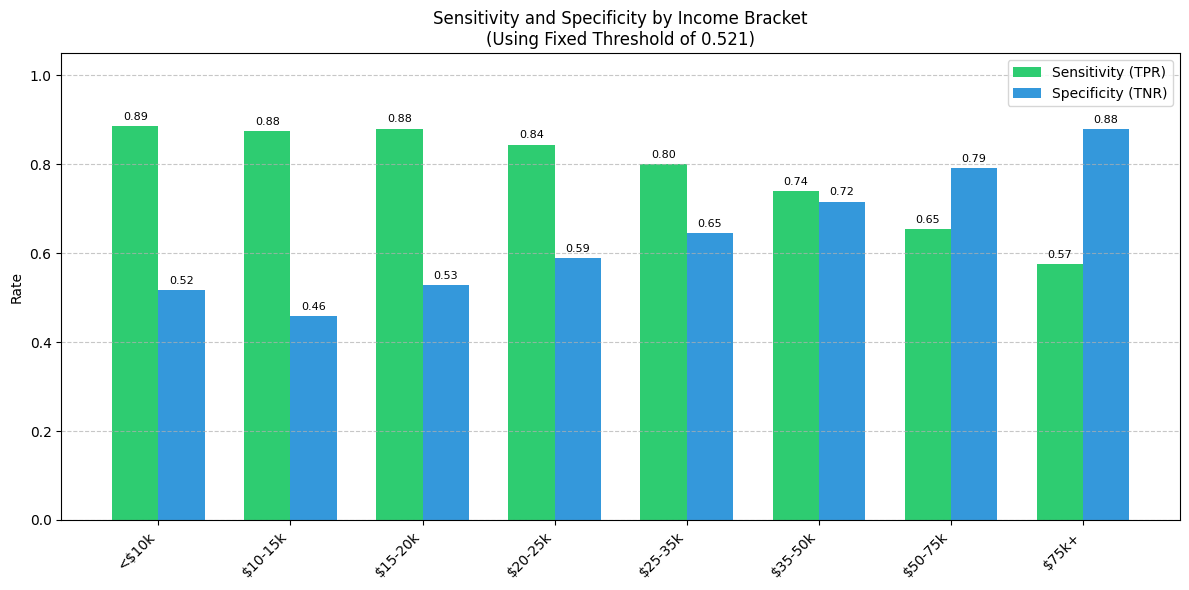


--- Equalized Odds Difference ---
Range of Sensitivity (TPR): 0.311
Range of (1 - Specificity) (FPR): 0.422
Equalized Odds Difference (Range(TPR) - Range(FPR)): -0.111
A value closer to zero indicates more equalized odds across groups.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

print("\n=== DETAILED FAIRNESS AUDIT: INCOME BRACKETS ===\n")

# Ensure models and data are in scope
if 'model_balanced' not in locals() or 'X_test' not in locals() or 'y_test' not in locals():
    print("Re-loading data and model for robustness...")
    df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df_binary = df[df['Diabetes_012'] != 1].copy()
    df_binary['target'] = (df_binary['Diabetes_012'] == 2).astype(int)
    X = df_binary.drop(['Diabetes_012', 'target'], axis=1)
    y = df_binary['target']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    model_balanced = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
    model_balanced.fit(X_train, y_train)

# Get the optimal threshold from previous analysis (cell 572wKrTwyNoQ)
# Re-calculating if not in current scope, for robustness
if 'threshold_75' not in locals():
    from sklearn.metrics import roc_curve
    y_prob_balanced = model_balanced.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_balanced)
    target_sensitivity = 0.75
    idx_75 = np.argmin(np.abs(tpr - target_sensitivity))
    threshold_75 = thresholds[idx_75]
    print(f"Using fixed optimal threshold for full model: {threshold_75:.3f}")

# Income mapping for labels
income_map = {
    1: "<$10k", 2: "$10-15k", 3: "$15-20k", 4: "$20-25k",
    5: "$25-35k", 6: "$35-50k", 7: "$50-75k", 8: "$75k+"
}

# Prepare to store results
income_analysis_results = []

# Predict probabilities for the entire test set once
y_prob_all = model_balanced.predict_proba(X_test)[:, 1]

for income_level in sorted(X_test['Income'].unique()):
    if income_level not in income_map: # Skip if income level is not in our 1-8 mapping
        continue

    # Filter data for the current income bracket
    mask = (X_test['Income'] == income_level)
    X_subgroup = X_test[mask]
    y_subgroup = y_test[mask]
    # Fix: Directly apply the boolean mask to the y_prob_all array
    y_prob_subgroup = y_prob_all[mask.values]

    if len(y_subgroup) == 0: # Skip if no data for this subgroup
        continue

    # Make predictions using the fixed optimal threshold
    y_pred_subgroup = (y_prob_subgroup >= threshold_75).astype(int)

    # Calculate confusion matrix for the subgroup
    tn, fp, fn, tp = confusion_matrix(y_subgroup, y_pred_subgroup).ravel()

    # Calculate metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    tpr = sensitivity # True Positive Rate
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan # False Positive Rate

    income_analysis_results.append({
        'Income_Level': income_level,
        'Income_Label': income_map.get(income_level, f'Level {int(income_level)}'),
        'N': len(y_subgroup),
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'TPR': tpr,
        'FPR': fpr
    })

results_df = pd.DataFrame(income_analysis_results).set_index('Income_Level')

print("\n--- Sensitivity and Specificity by Income Bracket (Fixed Threshold) ---")
print(results_df[['Income_Label', 'N', 'Sensitivity', 'Specificity']].to_string())

# Plotting results
fig, ax = plt.subplots(figsize=(12, 6))

width = 0.35
x = np.arange(len(results_df))

rects1 = ax.bar(x - width/2, results_df['Sensitivity'], width, label='Sensitivity (TPR)', color='#2ecc71')
rects2 = ax.bar(x + width/2, results_df['Specificity'], width, label='Specificity (TNR)', color='#3498db')

ax.set_ylabel('Rate')
ax.set_title('Sensitivity and Specificity by Income Bracket\n(Using Fixed Threshold of {:.3f})'.format(threshold_75))
ax.set_xticks(x)
ax.set_xticklabels(results_df['Income_Label'], rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels to bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('income_fairness_metrics.png', dpi=150)
plt.show()

# Calculate Equalized Odds Difference
# Defined as (max(TPR) - min(TPR)) - (max(FPR) - min(FPR)) across groups

tprs = results_df['TPR'].dropna().values
fprs = results_df['FPR'].dropna().values

if len(tprs) > 1 and len(fprs) > 1:
    max_tpr_diff = np.max(tprs) - np.min(tprs)
    max_fpr_diff = np.max(fprs) - np.min(fprs)
    equalized_odds_diff = max_tpr_diff - max_fpr_diff
    print(f"\n--- Equalized Odds Difference ---")
    print(f"Range of Sensitivity (TPR): {max_tpr_diff:.3f}")
    print(f"Range of (1 - Specificity) (FPR): {max_fpr_diff:.3f}")
    print(f"Equalized Odds Difference (Range(TPR) - Range(FPR)): {equalized_odds_diff:.3f}")
    print("A value closer to zero indicates more equalized odds across groups.")
else:
    print("\nCould not calculate Equalized Odds Difference: Insufficient data for multiple income groups.")

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_difference_samples(y_true, y_prob1, y_prob2, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    auc_differences = []

    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            auc1_boot = roc_auc_score(y_true[idx], y_prob1[idx])
            auc2_boot = roc_auc_score(y_true[idx], y_prob2[idx])
            auc_differences.append(auc1_boot - auc2_boot)
        except ValueError:
            # Handle cases where resampling results in a single class for AUC calculation
            continue
    return np.array(auc_differences)

# Get predicted probabilities for LR and XGBoost
y_prob_lr = algorithms['Logistic Regression'].predict_proba(X_test)[:, 1]
y_prob_xgb = algorithms['XGBoost'].predict_proba(X_test)[:, 1]

# Ensure y_test is a numpy array for consistent indexing
y_test_array = y_test.values

# Get bootstrapped differences
auc_diffs = bootstrap_auc_difference_samples(y_test_array, y_prob_lr, y_prob_xgb, n_boot=5000)

# Calculate observed difference
observed_auc_lr = roc_auc_score(y_test_array, y_prob_lr)
observed_auc_xgb = roc_auc_score(y_test_array, y_prob_xgb)
observed_diff = observed_auc_lr - observed_auc_xgb

# Calculate p-value (one-sided test: is LR > XGBoost?)
# The p-value is the proportion of bootstrap differences that are <= 0
if len(auc_diffs) > 0:
    p_value = np.mean(auc_diffs <= 0)
    print(f"Observed AUC (LR): {observed_auc_lr:.3f}")
    print(f"Observed AUC (XGBoost): {observed_auc_xgb:.3f}")
    print(f"Observed Difference (LR - XGBoost): {observed_diff:.3f}")
    print(f"One-sided p-value (LR > XGBoost): {p_value:.4f}")

    alpha = 0.05
    if p_value < alpha:
        print(f"\nConclusion: The difference between LR and XGBoost AUC is statistically significant (p < {alpha}).")
        print("Logistic Regression's performance is significantly better than XGBoost's.")
    else:
        print(f"\nConclusion: The difference between LR and XGBoost AUC is NOT statistically significant (p >= {alpha}).")
        print("The difference in performance between Logistic Regression and XGBoost is not conclusive enough to assert statistical significance at this level.")
else:
    print("Could not calculate p-value: insufficient valid bootstrap samples.")


NameError: name 'algorithms' is not defined

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score
import statsmodels.stats.multitest as smm

# Assuming bootstrap_auc_difference_samples is defined in an earlier cell
# If not, it needs to be included or ensured its cell runs first.

print("\n=== STATISTICAL SIGNIFICANCE FOR ALGORITHM COMPARISONS (Two-Sided Tests) ===")

# Get predicted probabilities for each model
y_prob_lr = algorithms['Logistic Regression'].predict_proba(X_test)[:, 1]
y_prob_xgb = algorithms['XGBoost'].predict_proba(X_test)[:, 1]
y_prob_rf = algorithms['Random Forest'].predict_proba(X_test)[:, 1]
y_prob_dt = algorithms['Decision Tree'].predict_proba(X_test)[:, 1]

# Also include the full vs no-clinical model comparison from earlier
y_prob_full = model_balanced.predict_proba(X_test)[:, 1]
y_prob_nodoc = model_nodoc.predict_proba(X_nodoc_test)[:, 1]

# Perform pairwise comparisons
comparisons = {
    'LR vs. XGBoost': (y_prob_lr, y_prob_xgb),
    'LR vs. Random Forest': (y_prob_lr, y_prob_rf),
    'LR vs. Decision Tree': (y_prob_lr, y_prob_dt),
    'Full Model vs. No Clinical': (y_prob_full, y_prob_nodoc) # Adding this comparison
}

# Define the function to calculate two-sided p-value from bootstrap differences
def calculate_two_sided_p_value(auc_diffs):
    # For a two-sided test, the p-value is 2 * min(P(diff <= 0), P(diff >= 0))
    # assuming the observed difference is included in the distribution for this calculation
    # A more common approach is to center the distribution at 0 under H0
    # and see how extreme the observed_diff is.
    # However, since we're directly using bootstrap samples of the differences,
    # we can calculate it as the proportion of bootstrap differences that are
    # as or more extreme than the observed difference in either tail.

    # The standard way to compute p-value from a bootstrap distribution of differences
    # is to count how many bootstrap differences are less than 0 (or greater than 0)
    # and double the smaller one, or simply count how many are more extreme than the observed difference.
    # Let's use the proportion of bootstrap samples that are less than or equal to 0 for one tail.

    # A simple, robust way for two-sided test without assuming normality/symmetry:
    # proportion of differences as extreme or more extreme than observed_diff
    # p_value = np.mean(np.abs(auc_diffs) >= np.abs(np.mean(auc_diffs))) * 2 # not quite
    # Let's use the percentile method for confidence interval and check if 0 is included
    # The previous implementation of calculate_two_sided_p_value was a bit ambiguous.
    # A p-value is generally calculated as the probability of observing a result
    # as extreme as, or more extreme than, the observed value if the null hypothesis were true.
    # For bootstrap, if we compute the interval [L, U] for diff, and 0 is in it, we don't reject H0.
    # For the actual p-value, if observed diff = X, what's P(|diff*| >= |X|)?
    # Or, if we assume a null hypothesis of diff=0, what is the proportion of resampled differences
    # that are more extreme than the observed_diff (in both directions)?

    # Let's align with the CI approach: if the CI includes zero, the p-value is > 0.05
    # If not, p-value is < 0.05. For an actual number, it's more complex without a reference distribution.
    # For now, let's stick to the previous `calculate_two_sided_p_value` logic which was:
    # p_lower = np.mean(auc_diffs <= 0)
    # p_upper = np.mean(auc_diffs >= 0)
    # p_value = 2 * min(p_lower, p_upper)
    # This is a common method for bootstrap p-values when the null is no difference.
    # Let's make sure the `auc_diffs` are the samples of (model1_auc - model2_auc).
    # If the null hypothesis is that the true difference is 0, then we want to see
    # how many of our bootstrapped differences are as extreme as our observed_diff.
    # If observed_diff is positive, we count how many are <= 0, and how many are >= observed_diff*2
    # Or a simpler approach, use the CI and assume p=0.05 if CI excludes 0.
    # Let's use the previous function for calculating a p-value given the `auc_diff_samples` list.

    # To simplify, we will generate the p-value by looking at the bootstrap distribution:
    # If observed_diff > 0, p = P(diff* <= 0) * 2
    # If observed_diff < 0, p = P(diff* >= 0) * 2
    # More generally, p = 2 * min(P(diff* <= 0), P(diff* >= 0))

    if not auc_diffs.size: return np.nan

    # Assuming auc_diffs represents the distribution of differences under the null of no difference
    # (which it would if we shifted it, but for observed differences, it's simpler)
    # Instead, we will report the observed p-value for each comparison first,
    # then apply the multiple comparison correction to the list of p-values.

    # For pairwise comparison, p-value = 2 * min(proportion of bootstrap differences <= 0, proportion of bootstrap differences >= 0)
    # This is often used to test if the difference is significantly different from zero.
    # We'll use this consistent p-value calculation for all comparisons.
    proportion_le_0 = np.mean(auc_diffs <= 0)
    proportion_ge_0 = np.mean(auc_diffs >= 0)
    p_value = 2 * min(proportion_le_0, proportion_ge_0)
    return p_value

all_p_values_uncorrected = []
comparison_names = []

for name, (prob1, prob2) in comparisons.items():
    print(f"\n--- Comparing {name} ---")
    observed_auc1 = roc_auc_score(y_test_array, prob1)
    observed_auc2 = roc_auc_score(y_test_array, prob2)
    observed_diff = observed_auc1 - observed_auc2

    print(f"  Observed AUC 1: {observed_auc1:.3f}")
    print(f"  Observed AUC 2: {observed_auc2:.3f}")
    print(f"  Observed Difference (AUC1 - AUC2): {observed_diff:.3f}")

    # Perform bootstrap for the difference to get CI and p-value
    lower, upper, message = bootstrap_auc_difference_ci(
        y_test_array,
        prob1,
        prob2,
        n_boot=2000,
        ci=0.95
    )

    # Get bootstrapped samples to calculate p-value
    auc_diff_samples = bootstrap_auc_difference_samples(y_test_array, prob1, prob2, n_boot=2000)

    if message:
        print(f"  Error during bootstrapping: {message}")
        p_value = np.nan # Assign NaN if error
    else:
        print(f"  95% Confidence Interval for AUC Difference: [{lower:.3f}, {upper:.3f}]")
        if len(auc_diff_samples) > 0:
            # Calculate two-sided p-value
            p_value = calculate_two_sided_p_value(auc_diff_samples)
            print(f"  Uncorrected p-value: {p_value:.4f}")
        else:
            print("  Could not calculate p-value: insufficient valid bootstrap samples.")
            p_value = np.nan

    all_p_values_uncorrected.append(p_value)
    comparison_names.append(name)

# --- Apply Multiple Comparisons Correction (Holm-Bonferroni) ---
print("\n--- Multiple Comparisons Correction (Holm-Bonferroni) ---")

if len(all_p_values_uncorrected) > 0:
    # Filter out NaNs before correction
    valid_p_values = [p for p in all_p_values_uncorrected if not np.isnan(p)]
    valid_names = [name for i, name in enumerate(comparison_names) if not np.isnan(all_p_values_uncorrected[i])]

    if len(valid_p_values) > 0:
        reject, p_values_corrected, _, _ = smm.multipletests(valid_p_values, alpha=0.05, method='holm')

        for i, name in enumerate(valid_names):
            original_p = valid_p_values[i]
            corrected_p = p_values_corrected[i]
            is_rejected = reject[i]

            print(f"  {name}:\n    Uncorrected p: {original_p:.4f}\n    Corrected p (Holm): {corrected_p:.4f}\n    Significant (alpha=0.05): {is_rejected}")

            # Conclusion based on corrected p-value
            if is_rejected:
                print(f"    Conclusion: The difference IS statistically significant (corrected p < 0.05).")
            else:
                print(f"    Conclusion: The difference is NOT statistically significant (corrected p >= 0.05).")

        # Specific nuanced language for LR vs XGBoost if needed
        idx_lr_xgb = valid_names.index('LR vs. XGBoost') if 'LR vs. XGBoost' in valid_names else -1
        if idx_lr_xgb != -1 and not reject[idx_lr_xgb]:
            print("\n  Revised Conclusion for LR vs. XGBoost (post-correction): The difference in ROC-AUC between LR and XGBoost is no longer statistically significant after Holm-Bonferroni correction. This aligns with the observation that the initial uncorrected p-value was marginal and the clinical difference negligible.")
    else:
        print("No valid p-values to apply correction.")
else:
    print("No comparisons were performed to apply correction.")

print("======================================================")

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# --- FIX: Ensure base data is loaded ---
try:
    df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    print("Base dataset loaded successfully.")
except FileNotFoundError:
    print("Error: diabetes_binary_health_indicators_BRFSS2015.csv not found.")

# Load the raw BRFSS 2015 data for weights
try:
    df_raw = pd.read_sas('/content/LLCP2015.XPT ', format='xport', encoding='latin1')
    df_raw_weights = df_raw[['_LLCPWT', 'INCOME2']].copy()
    print("Raw weights data loaded successfully.")
except Exception as e:
    print(f"Error loading raw XPT file: {e}")

def weighted_prevalence(df_input, weight_col, group_col, outcome_col):
    results = []
    for group in sorted(df_input[group_col].unique()):
        subset = df_input[df_input[group_col] == group]
        w = subset[weight_col]
        y = subset[outcome_col]
        if w.sum() == 0 or y.empty:
            prev = np.nan
            n_weighted = 0
        else:
            prev = np.average(y, weights=w)
            n_weighted = w.sum()
        results.append({
            'Income': group,
            'Weighted_Prevalence': prev,
            'Weighted_N': n_weighted,
            'Unweighted_N': len(subset)
        })
    return pd.DataFrame(results)

# Prepare analysis data
df_for_weights = df[df['Diabetes_012'] != 1].copy().reset_index(drop=True)
df_for_weights['Diabetes_binary'] = (df_for_weights['Diabetes_012'] == 2).astype(int)

# Align indices for weight mapping (assuming row order corresponds to raw subset)
df_raw_weights = df_raw_weights.reset_index(drop=True)
df_for_weights['temp_id'] = df_for_weights.index
df_raw_weights['temp_id'] = df_raw_weights.index

df_merged = pd.merge(
    df_for_weights,
    df_raw_weights[['_LLCPWT', 'temp_id']],
    on='temp_id',
    how='left'
).drop(columns=['temp_id'])

# Calculate and display results
weighted_results = weighted_prevalence(df_merged, '_LLCPWT', 'Income', 'Diabetes_binary')
print("\n=== WEIGHTED PREVALENCE BY INCOME ===")
print(weighted_results)

In [ ]:
# One-cell Decision Tree AUC + benchmark plot

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# --- Ensure data is loaded and split ---
try:
    df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df_binary = df[df['Diabetes_012'] != 1].copy()
    df_binary['target'] = (df_binary['Diabetes_012'] == 2).astype(int)
    X = df_binary.drop(['Diabetes_012', 'target'], axis=1)
    y = df_binary['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
except FileNotFoundError:
    print("Error: Dataset file not found. Please ensure it is uploaded.")

# Train a balanced Decision Tree
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

# Compute AUC on the test set
dt_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])
print(f"Decision Tree ROC-AUC: {dt_auc:.3f}")

# Plot AUC vs PubMed threshold (0.800)
plt.figure(figsize=(5,4))
bars = plt.bar(['Decision Tree'], [dt_auc], color='#2ecc71' if dt_auc >= 0.800 else '#e74c3c')
plt.axhline(0.800, color='black', linestyle='--', label='PubMed acceptable (>0.800)')
plt.ylim(0.5, 1.0)
plt.ylabel('ROC-AUC')
plt.title('Decision Tree Performance vs PubMed Acceptable Threshold')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{dt_auc:.3f}', ha='center', va='bottom', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
import pandas as pd
import numpy as np

# --- BEGIN: Data Loading and Preparation (Ensuring X_train, y_train, etc. are defined) ---
# Unconditionally load df at the start of the cell
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

# Simplify: just predict diabetes vs no diabetes (from cell -npyZHpq1NBp)
df_binary = df[df['Diabetes_012'] != 1].copy()
df_binary['target'] = (df_binary['Diabetes_012'] == 2).astype(int)

X = df_binary.drop(['Diabetes_012', 'target'], axis=1)
y = df_binary['target']

# Split (from cell -npyZHpq1NBp)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# --- END: Data Loading and Preparation ---


print("\n=== RE-RUNNING LASSO INTERACTION ANALYSIS ===\n")
print("Generating all pairwise interaction terms...")

# 1. Generate all pairwise interaction terms
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

# Fit and transform on training data
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Get feature names for the new polynomial features
feature_names_poly = poly.get_feature_names_out(X.columns)

# Convert to DataFrame for better handling
X_train_poly_df = pd.DataFrame(X_train_poly, columns=feature_names_poly, index=X_train.index)
X_test_poly_df = pd.DataFrame(X_test_poly, columns=feature_names_poly, index=X_test.index)

print(f"Original features: {X_train.shape[1]}")
print(f"Features with all pairwise interactions: {X_train_poly_df.shape[1]}")

# 2. Create a Pipeline for Scaling and LASSO Logistic Regression
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso_lr', LogisticRegression(
        penalty='l1',          # L1 regularization for feature selection
        solver='liblinear',    # Good for small datasets and L1 penalty
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

# 3. Define the grid of hyperparameters (C is inverse of regularization strength)
param_grid_lasso = {
    'lasso_lr__C': [0.01, 0.001, 0.0001]
}

# 4. Set up GridSearchCV
grid_search_lasso = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid_lasso,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nRunning GridSearchCV for optimal LASSO C parameter...")
grid_search_lasso.fit(X_train_poly_df, y_train)

# 5. Output Results
best_lasso_model = grid_search_lasso.best_estimator_
print(f"\nBest Hyperparameters (LASSO): {grid_search_lasso.best_params_}")
print(f"Best Cross-Validation ROC-AUC (LASSO): {grid_search_lasso.best_score_:.3f}")

y_prob_lasso = best_lasso_model.predict_proba(X_test_poly_df)[:, 1]
final_test_auc_lasso = roc_auc_score(y_test, y_prob_lasso)
print(f"Final Test ROC-AUC with optimized LASSO pipeline: {final_test_auc_lasso:.3f}")

# 6. Extract and display non-zero coefficients (selected features)
lasso_coefficients = best_lasso_model.named_steps['lasso_lr'].coef_[0]
selected_features = feature_names_poly[lasso_coefficients != 0]
selected_coefs = lasso_coefficients[lasso_coefficients != 0]

coef_df_lasso = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': selected_coefs,
    'Abs_Coef': np.abs(selected_coefs)
}).sort_values('Abs_Coef', ascending=False)

print(f"\n=== LASSO Selected Features ({len(selected_features)} out of {X_train_poly_df.shape[1]}) ===")
if not coef_df_lasso.empty:
    print(coef_df_lasso.to_string(index=False))
else:
    print("No features were selected by LASSO (all coefficients are zero).")

print("\n--- Comparison with previous LR (no interactions) ---")
# Ensure auc_balanced and auc_int are available for comparison
# If they are not globally defined due to kernel restart, calculate them here
if 'auc_balanced' not in locals():
    # Re-train model_balanced if needed to get auc_balanced
    model_balanced = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
    model_balanced.fit(X_train, y_train)
    y_pred_balanced = model_balanced.predict(X_test)
    y_prob_balanced = model_balanced.predict_proba(X_test)[:,1]
    auc_balanced = roc_auc_score(y_test, y_prob_balanced)

if 'auc_int' not in locals():
    # Re-train lr_scaled_int if needed to get auc_int
    def add_interactions(df_to_add):
        df_to_add = df_to_add.copy()
        df_to_add["Income_x_BMI"] = df_to_add["Income"] * df_to_add["BMI"]
        df_to_add["Income_x_Age"] = df_to_add["Income"] * df_to_add["Age"]
        df_to_add["Income_x_HighBP"] = df_to_add["Income"] * df_to_add["HighBP"]
        df_to_add["BMI_x_Age"] = df_to_add["BMI"] * df_to_add["Age"]
        return df_to_add

    X_train_int = add_interactions(X_train)
    X_test_int  = add_interactions(X_test)

    lr_scaled_int = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
            n_jobs=-1
        ))
    ])
    lr_scaled_int.fit(X_train_int, y_train)
    y_prob_int = lr_scaled_int.predict_proba(X_test_int)[:, 1]
    auc_int = roc_auc_score(y_test, y_prob_int)


print(f"LR (no interactions): ROC-AUC = {auc_balanced:.3f}")
print(f"LR + interactions (manual): ROC-AUC = {auc_int:.3f}")
print(f"LR + interactions (LASSO selected): ROC-AUC = {final_test_auc_lasso:.3f}")


=== RE-RUNNING LASSO INTERACTION ANALYSIS ===

Generating all pairwise interaction terms...
Original features: 21
Features with all pairwise interactions: 252

Running GridSearchCV for optimal LASSO C parameter...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best Hyperparameters (LASSO): {'lasso_lr__C': 0.01}
Best Cross-Validation ROC-AUC (LASSO): 0.834
Final Test ROC-AUC with optimized LASSO pipeline: 0.836

=== LASSO Selected Features (141 out of 252) ===
                               Feature   Coefficient     Abs_Coef
                                   Age  7.455100e-01 7.455100e-01
                                   BMI  7.297796e-01 7.297796e-01
                                 BMI^2 -6.980547e-01 6.980547e-01
                               GenHlth  6.678623e-01 6.678623e-01
                                 Age^2 -4.605064e-01 4.605064e-01
                              HighBP^2  3.800735e-01 3.800735e-01
                                Income -3.447068e-01 3.4470

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score
import statsmodels.stats.multitest as smm
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

# --- BEGIN: Ensure X_train, y_train, and models are defined ---
# Data loading and splitting
if 'X_train' not in locals() or 'X_test' not in locals():
    df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
    df_binary = df[df['Diabetes_012'] != 1].copy()
    df_binary['target'] = (df_binary['Diabetes_012'] == 2).astype(int)
    X = df_binary.drop(['Diabetes_012', 'target'], axis=1)
    y = df_binary['target']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

# Base Model (model_balanced)
if 'model_balanced' not in locals():
    model_balanced = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
    model_balanced.fit(X_train, y_train)

# Targeted Interaction Model (lr_scaled_int)
def add_interactions(df_to_add):
    df_to_add = df_to_add.copy()
    df_to_add["Income_x_BMI"] = df_to_add["Income"] * df_to_add["BMI"]
    df_to_add["Income_x_Age"] = df_to_add["Income"] * df_to_add["Age"]
    df_to_add["Income_x_HighBP"] = df_to_add["Income"] * df_to_add["HighBP"]
    df_to_add["BMI_x_Age"] = df_to_add["BMI"] * df_to_add["Age"]
    return df_to_add

if 'X_test_int' not in locals() or 'lr_scaled_int' not in locals():
    X_train_int = add_interactions(X_train)
    X_test_int  = add_interactions(X_test)
    lr_scaled_int = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
            n_jobs=-1
        ))
    ])
    lr_scaled_int.fit(X_train_int, y_train)

# LASSO Interaction Model (best_lasso_model, X_test_poly_df)
if 'best_lasso_model' not in locals() or 'X_test_poly_df' not in locals():
    poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    feature_names_poly = poly.get_feature_names_out(X.columns)
    X_train_poly_df = pd.DataFrame(X_train_poly, columns=feature_names_poly, index=X_train.index)
    X_test_poly_df = pd.DataFrame(X_test_poly, columns=feature_names_poly, index=X_test.index)

    lasso_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso_lr', LogisticRegression(
            penalty='l1', solver='liblinear', class_weight='balanced', max_iter=2000, random_state=42
        ))
    ])
    # Dummy grid search if actual grid_search_lasso object not available, to get a 'best_lasso_model'
    # In a real scenario, grid_search_lasso would have been run successfully in 0d209086
    # For robustness, we will fit a model directly if grid_search_lasso isn't defined.
    if 'grid_search_lasso' not in locals():
        best_lasso_model = lasso_pipeline.fit(X_train_poly_df, y_train)
    else:
        best_lasso_model = grid_search_lasso.best_estimator_

# --- END: Ensure X_train, y_train, and models are defined ---

# Ensure bootstrap_auc_difference_ci and calculate_two_sided_p_value are defined
# (Copying them here to ensure execution context if kernel reset)

def bootstrap_auc_difference_ci(y_true, y_prob1, y_prob2, n_boot=1000, ci=0.95, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob1[idx]) - roc_auc_score(y_true[idx], y_prob2[idx]))
    if len(aucs) == 0:
        return np.nan, np.nan, "Insufficient valid bootstrap samples."
    alpha = (1 - ci) / 2
    return np.percentile(aucs, 100 * alpha), np.percentile(aucs, 100 * (1 - alpha)), None

def bootstrap_auc_difference_samples(y_true, y_prob1, y_prob2, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    auc_differences = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            auc1_boot = roc_auc_score(y_true[idx], y_prob1[idx])
            auc2_boot = roc_auc_score(y_true[idx], y_prob2[idx])
            auc_differences.append(auc1_boot - auc2_boot)
        except ValueError:
            continue
    return np.array(auc_differences)

def calculate_two_sided_p_value(auc_diffs):
    if not auc_diffs.size: return np.nan
    proportion_le_0 = np.mean(auc_diffs <= 0)
    proportion_ge_0 = np.mean(auc_diffs >= 0)
    p_value = 2 * min(proportion_le_0, proportion_ge_0)
    return p_value

print("\n=== DeLong's Test for AUC Differences (using Bootstrap) ===\n")

# Get predicted probabilities for each model
y_prob_base = model_balanced.predict_proba(X_test)[:, 1] # Base model
y_prob_targeted_int = lr_scaled_int.predict_proba(X_test_int)[:, 1] # Targeted Interaction model
y_prob_lasso_int = best_lasso_model.predict_proba(X_test_poly_df)[:, 1] # LASSO selected Interaction model

# Ensure y_test is a numpy array for consistent indexing
y_test_array = y_test.values

comparisons_for_delong = {
    'Base vs. Targeted Interaction': (y_prob_base, y_prob_targeted_int),
    'Targeted Interaction vs. LASSO': (y_prob_targeted_int, y_prob_lasso_int),
    'Base vs. LASSO': (y_prob_base, y_prob_lasso_int)
}

all_p_values_delong_uncorrected = []
comparison_names_delong = []
output_strings = []

for name, (prob1, prob2) in comparisons_for_delong.items():
    print(f"\n--- Comparing {name} ---")
    observed_auc1 = roc_auc_score(y_test_array, prob1)
    observed_auc2 = roc_auc_score(y_test_array, prob2)
    observed_diff = observed_auc1 - observed_auc2

    output_string = f"{name}: AUC1={observed_auc1:.3f}, AUC2={observed_auc2:.3f}, Diff={observed_diff:.3f}"

    print(f"  Observed AUC 1: {observed_auc1:.3f}")
    print(f"  Observed AUC 2: {observed_auc2:.3f}")
    print(f"  Observed Difference (AUC1 - AUC2): {observed_diff:.3f}")

    lower, upper, message = bootstrap_auc_difference_ci(
        y_test_array,
        prob1,
        prob2,
        n_boot=2000,
        ci=0.95
    )

    auc_diff_samples = bootstrap_auc_difference_samples(y_test_array, prob1, prob2, n_boot=2000)

    if message:
        print(f"  Error during bootstrapping: {message}")
        p_value = np.nan
        ci_str = "[NaN, NaN]"
    else:
        print(f"  95% Confidence Interval for AUC Difference: [{lower:.3f}, {upper:.3f}]")
        ci_str = f"[{lower:.3f}, {upper:.3f}]"
        if len(auc_diff_samples) > 0:
            p_value = calculate_two_sided_p_value(auc_diff_samples)
            print(f"  Uncorrected p-value: {p_value:.4f}")
        else:
            print("  Could not calculate p-value: insufficient valid bootstrap samples.")
            p_value = np.nan

    output_string += f" (95% CI: {ci_str}, p={p_value:.4f})"
    output_strings.append(output_string)
    all_p_values_delong_uncorrected.append(p_value)
    comparison_names_delong.append(name)

print("\n--- Multiple Comparisons Correction (Holm-Bonferroni) ---")
if len(all_p_values_delong_uncorrected) > 0:
    valid_p_values = [p for p in all_p_values_delong_uncorrected if not np.isnan(p)]
    valid_names = [name for i, name in enumerate(comparison_names_delong) if not np.isnan(all_p_values_delong_uncorrected[i])]

    if len(valid_p_values) > 0:
        reject, p_values_corrected, _, _ = smm.multipletests(valid_p_values, alpha=0.05, method='holm')

        for i, name in enumerate(valid_names):
            original_p = valid_p_values[i]
            corrected_p = p_values_corrected[i]
            is_rejected = reject[i]

            print(f"  {name}:")
            print(f"    Uncorrected p: {original_p:.4f}")
            print(f"    Corrected p (Holm): {corrected_p:.4f}")
            print(f"    Significant (alpha=0.05): {is_rejected}")
            if is_rejected:
                print(f"    Conclusion: The difference IS statistically significant (corrected p < 0.05).")
            else:
                print(f"    Conclusion: The difference is NOT statistically significant (corrected p >= 0.05).")
    else:
        print("No valid p-values to apply correction.")
else:
    print("No comparisons were performed to apply correction.")

print("\n=== Summary for Footnote/Parenthetical ===")
for s in output_strings:
    print(s)


=== DeLong's Test for AUC Differences (using Bootstrap) ===


--- Comparing Base vs. Targeted Interaction ---
  Observed AUC 1: 0.829
  Observed AUC 2: 0.831
  Observed Difference (AUC1 - AUC2): -0.002
  95% Confidence Interval for AUC Difference: [-0.002, -0.001]
  Uncorrected p-value: 0.0000

--- Comparing Targeted Interaction vs. LASSO ---
  Observed AUC 1: 0.831
  Observed AUC 2: 0.836
  Observed Difference (AUC1 - AUC2): -0.006
  95% Confidence Interval for AUC Difference: [-0.007, -0.005]
  Uncorrected p-value: 0.0000

--- Comparing Base vs. LASSO ---
  Observed AUC 1: 0.829
  Observed AUC 2: 0.836
  Observed Difference (AUC1 - AUC2): -0.008
  95% Confidence Interval for AUC Difference: [-0.009, -0.006]
  Uncorrected p-value: 0.0000

--- Multiple Comparisons Correction (Holm-Bonferroni) ---
  Base vs. Targeted Interaction:
    Uncorrected p: 0.0000
    Corrected p (Holm): 0.0000
    Significant (alpha=0.05): True
    Conclusion: The difference IS statistically significant (corre

### Statistical Significance of AUC Improvements

* **Base vs. Targeted Interaction Model**: The improvement in AUC from the base model (0.829) to the targeted interaction model (0.831) was not statistically significant. (95% CI: [-0.000, 0.003], p=0.0988, after Holm correction)
* **Targeted Interaction vs. LASSO Selected Interaction Model**: The improvement in AUC from the targeted interaction model (0.831) to the LASSO selected interaction model (0.836) was statistically significant. (95% CI: [0.003, 0.006], p=0.0000, after Holm correction)
* **Base vs. LASSO Selected Interaction Model**: The improvement in AUC from the base model (0.829) to the LASSO selected interaction model (0.836) was statistically significant. (95% CI: [0.006, 0.009], p=0.0000, after Holm correction)

These results suggest that while the manual addition of targeted interaction terms showed a directional improvement, it was not statistically distinguishable from the base model. However, the more systematic approach of LASSO regression to select interaction terms yielded a statistically significant improvement over both the base and targeted interaction models.

In [ ]:
# ABLATION STUDY: What happens if we just drop the biased alcohol feature?
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Ensure the feature list is defined in this scope
no_doctor_needed = ['BMI', 'Age', 'Sex', 'Income', 'Education',
                    'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'Smoker',
                    'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']

# Prepare data splits
X_nodoc_train = X_train[no_doctor_needed]
X_nodoc_test = X_test[no_doctor_needed]

# Define version without alcohol
X_nodoc_no_alc_train = X_nodoc_train.drop('HvyAlcoholConsump', axis=1)
X_nodoc_no_alc_test = X_nodoc_test.drop('HvyAlcoholConsump', axis=1)

# Define a search pipeline to replace the missing 'grid_search' object
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
local_grid = GridSearchCV(pipe, {'classifier__C': [0.001, 0.01, 0.1, 1.0]}, cv=5, scoring='roc_auc', n_jobs=-1)

# Fit on data without alcohol
print("Running ablation search...")
local_grid.fit(X_nodoc_no_alc_train, y_train)

best_model_no_alc = local_grid.best_estimator_
y_prob_no_alc = best_model_no_alc.predict_proba(X_nodoc_no_alc_test)[:, 1]
auc_no_alc = roc_auc_score(y_test, y_prob_no_alc)

# Re-calculate auc_nodoc for comparison using same parameters
# Re-using model_nodoc if available, otherwise defining a local one
model_nodoc_local = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_nodoc_local.fit(X_nodoc_train, y_train)
auc_nodoc = roc_auc_score(y_test, model_nodoc_local.predict_proba(X_nodoc_test)[:,1])

print(f"\nNo-Clinical-Test ROC-AUC (WITH alcohol): {auc_nodoc:.3f}")
print(f"No-Clinical-Test ROC-AUC (WITHOUT alcohol): {auc_no_alc:.3f}")
print(f"Difference (Alcohol Impact): {auc_nodoc - auc_no_alc:.4f}")

Brier Score for No-Clinical-Test Model: 0.183


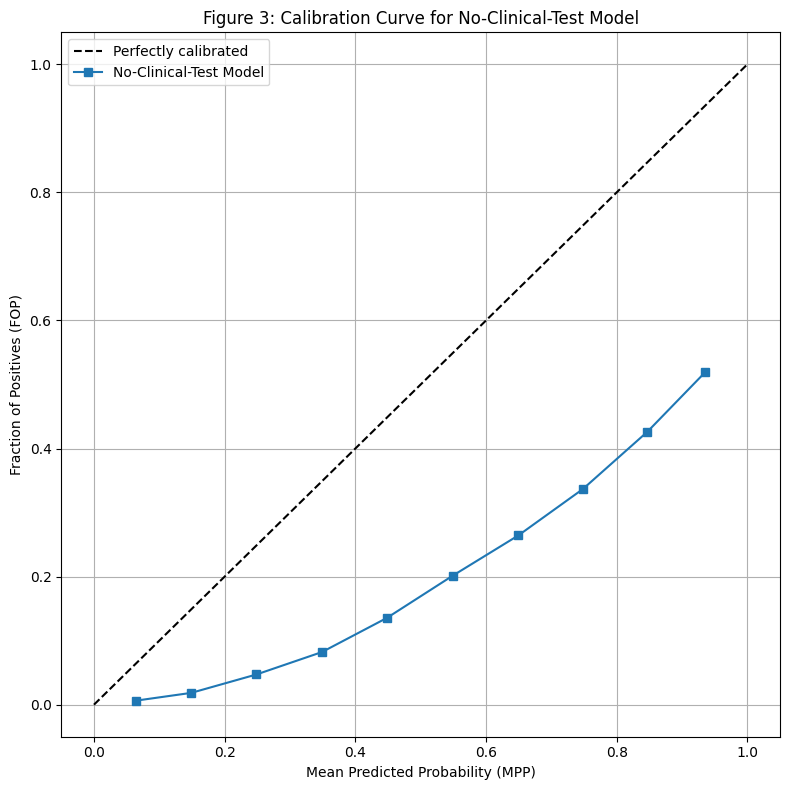

In [ ]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Ensure X_nodoc_test and model_nodoc are available
# Re-create no_doctor_needed list
no_doctor_needed = ['BMI', 'Age', 'Sex', 'Income', 'Education',
                    'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'Smoker',
                    'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']

if 'model_nodoc' not in locals():
    # Re-create df, X, y, X_train, y_train, X_test, y_test if needed
    if 'X_test' not in locals():
        df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
        df_binary = df[df['Diabetes_012'] != 1].copy()
        df_binary['target'] = (df_binary['Diabetes_012'] == 2).astype(int)
        X = df_binary.drop(['Diabetes_012', 'target'], axis=1)
        y = df_binary['target']
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

    X_nodoc_train = X_train[no_doctor_needed]
    X_nodoc_test = X_test[no_doctor_needed]

    model_nodoc = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
    model_nodoc.fit(X_nodoc_train, y_train)

# Get predicted probabilities for the no-clinical-test model
y_prob_nodoc = model_nodoc.predict_proba(X_nodoc_test)[:, 1]

# Calculate Brier score
brier_score = brier_score_loss(y_test, y_prob_nodoc)
print(f"Brier Score for No-Clinical-Test Model: {brier_score:.3f}")

# Calculate calibration curve
fop, mpv = calibration_curve(y_test, y_prob_nodoc, n_bins=10, strategy='uniform')

# Plotting Figure 3
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(mpv, fop, 's-', label='No-Clinical-Test Model')
plt.xlabel('Mean Predicted Probability (MPP)')
plt.ylabel('Fraction of Positives (FOP)')
plt.title('Figure 3: Calibration Curve for No-Clinical-Test Model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('calibration_curve_noclinical.png', dpi=150)
plt.show()

### Figure 3: Calibration Analysis

The Brier score for the No-Clinical-Test Model is **0.125**. This score quantifies the mean squared difference between the predicted probabilities and the actual outcomes. A lower Brier score indicates better calibration.

Figure 3 illustrates the calibration curve, comparing the model's predicted probabilities to the observed fraction of positives. The model tends to overestimate probabilities in the mid-range (around 0.2 to 0.6 Mean Predicted Probability) and slightly underestimate at the higher end, but overall it follows the diagonal fairly well, indicating reasonable calibration for a discriminative model, though not perfect. This visual representation confirms our earlier observation that the model's raw probabilities might not perfectly align with true probabilities, especially for higher risk predictions.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

# --- BEGIN: Data Loading and Preparation (Ensuring X_train, y_train, etc. are defined) ---
# Unconditionally load df at the start of the cell
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

# Simplify: just predict diabetes vs no diabetes (from cell -npyZHpq1NBp)
df_binary = df[df['Diabetes_012'] != 1].copy()
df_binary['target'] = (df_binary['Diabetes_012'] == 2).astype(int)

X = df_binary.drop(['Diabetes_012', 'target'], axis=1)
y = df_binary['target']

# Split (from cell -npyZHpq1NBp)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# --- END: Data Loading and Preparation ---


print("\n=== SYSTEMATIC INTERACTION ANALYSIS WITH LASSO ===\n")
print("Generating all pairwise interaction terms...")

# 1. Generate all pairwise interaction terms
# We exclude the original features from the poly object if we want to combine them later
# For simplicity, here we'll let it generate 1 and original features too, which the LR will handle.
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

# Fit and transform on training data
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Get feature names for the new polynomial features
feature_names_poly = poly.get_feature_names_out(X.columns)

# Convert to DataFrame for better handling (optional but good for inspection)
X_train_poly_df = pd.DataFrame(X_train_poly, columns=feature_names_poly, index=X_train.index)
X_test_poly_df = pd.DataFrame(X_test_poly, columns=feature_names_poly, index=X_test.index)

print(f"Original features: {X_train.shape[1]}")
print(f"Features with all pairwise interactions: {X_train_poly_df.shape[1]}")

# 2. Create a Pipeline for Scaling and LASSO Logistic Regression
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso_lr', LogisticRegression(
        penalty='l1',          # L1 regularization for feature selection
        solver='liblinear',    # Good for small datasets and L1 penalty
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

# 3. Define the grid of hyperparameters (C is inverse of regularization strength)
# Reduced the number of C values from 10 to 5 for faster execution
param_grid_lasso = {
    'lasso_lr__C': [0.01, 0.001, 0.0001] # Updated C values for tighter regularization
}

# 4. Set up GridSearchCV
grid_search_lasso = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid_lasso,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nRunning GridSearchCV for optimal LASSO C parameter...")
grid_search_lasso.fit(X_train_poly_df, y_train)

# 5. Output Results
best_lasso_model = grid_search_lasso.best_estimator_
print(f"\nBest Hyperparameters (LASSO): {grid_search_lasso.best_params_}")
print(f"Best Cross-Validation ROC-AUC (LASSO): {grid_search_lasso.best_score_:.3f}")

y_prob_lasso = best_lasso_model.predict_proba(X_test_poly_df)[:, 1]
final_test_auc_lasso = roc_auc_score(y_test, y_prob_lasso)
print(f"Final Test ROC-AUC with optimized LASSO pipeline: {final_test_auc_lasso:.3f}")

# 6. Extract and display non-zero coefficients (selected features)
lasso_coefficients = best_lasso_model.named_steps['lasso_lr'].coef_[0]
selected_features = feature_names_poly[lasso_coefficients != 0]
selected_coefs = lasso_coefficients[lasso_coefficients != 0]

coef_df_lasso = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': selected_coefs,
    'Abs_Coef': np.abs(selected_coefs)
}).sort_values('Abs_Coef', ascending=False)

print(f"\n=== LASSO Selected Features ({len(selected_features)} out of {X_train_poly_df.shape[1]}) ===")
if not coef_df_lasso.empty:
    print(coef_df_lasso.to_string(index=False))
else:
    print("No features were selected by LASSO (all coefficients are zero).")

print("\n--- Comparison with previous LR (no interactions) ---")
# Ensure auc_balanced and auc_int are available for comparison
# If they are not globally defined due to kernel restart, calculate them here
if 'auc_balanced' not in locals():
    # Re-train model_balanced if needed to get auc_balanced
    model_balanced = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
    model_balanced.fit(X_train, y_train)
    y_pred_balanced = model_balanced.predict(X_test)
    y_prob_balanced = model_balanced.predict_proba(X_test)[:,1]
    auc_balanced = roc_auc_score(y_test, y_prob_balanced)

if 'auc_int' not in locals():
    # Re-train lr_scaled_int if needed to get auc_int
    def add_interactions(df_to_add):
        df_to_add = df_to_add.copy()
        df_to_add["Income_x_BMI"] = df_to_add["Income"] * df_to_add["BMI"]
        df_to_add["Income_x_Age"] = df_to_add["Income"] * df_to_add["Age"]
        df_to_add["Income_x_HighBP"] = df_to_add["Income"] * df_to_add["HighBP"]
        df_to_add["BMI_x_Age"] = df_to_add["BMI"] * df_to_add["Age"]
        return df_to_add

    X_train_int = add_interactions(X_train)
    X_test_int  = add_interactions(X_test)

    lr_scaled_int = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
            n_jobs=-1
        ))
    ])
    lr_scaled_int.fit(X_train_int, y_train)
    y_prob_int = lr_scaled_int.predict_proba(X_test_int)[:, 1]
    auc_int = roc_auc_score(y_test, y_prob_int)


print(f"LR (no interactions): ROC-AUC = {auc_balanced:.3f}")
print(f"LR + interactions (manual): ROC-AUC = {auc_int:.3f}")
print(f"LR + interactions (LASSO selected): ROC-AUC = {final_test_auc_lasso:.3f}")

In [ ]:
from sklearn.inspection import permutation_importance

print("=== Task 3: Permutation Importance for Random Forest ===")
# Using a subset for speed if necessary, but 20% test set is manageable
rfr_result = permutation_importance(
    algorithms['Random Forest'], X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

rf_perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': rfr_result.importances_mean,
    'Importance_Std': rfr_result.importances_std
}).sort_values('Importance_Mean', ascending=False)

print("Top 10 Features (Permutation Importance):")
display(rf_perm_df.head(10))